# INTELLIGENT SYSTEM DEVELOPMENT — ASSIGNMENT 02

## Development of Three Traditional Machine-Learning Intelligent Systems

### Case Study A: Diabetes Prediction

### Case Study B: Vietnam House Price Prediction

### Case Study C: E-commerce customer behavior and interest discovery

Bài thực hành xây dựng ba hệ thống thông minh dựa trên dữ liệu có cấu trúc và các mô hình học máy truyền thống. Cả ba hệ thống được phát triển theo cùng một tiến trình:

`Real-world problem → Data → Feature representation → Preprocessing → Learning model → Prediction → Application`


In [168]:
# Thư viện chuẩn: file system, environment, JSON metadata, warnings
import os
import sys
import re
import json
import shutil
import warnings
from pathlib import Path
from collections import Counter

# Xử lý dữ liệu và trực quan hóa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Tiện ích clone model, chia dữ liệu và cross-validation
from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    KFold,
    cross_validate,
    cross_val_score,
)

# Pipeline tiền xử lý
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Mô hình baseline
from sklearn.dummy import DummyClassifier, DummyRegressor

# Mô hình classification và regression
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
)
from sklearn.svm import SVC, LinearSVC

# Biểu diễn text
from sklearn.feature_extraction.text import TfidfVectorizer

# Metrics đánh giá cho classification và regression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    make_scorer,
)

# Lưu và tải trained pipelines/models
import joblib

# Giữ output notebook gọn hơn
warnings.filterwarnings("ignore")

# Cố định random seed để tái lập kết quả
SEED = 42
np.random.seed(SEED)

# Cấu hình hiển thị Pandas
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


# Ghi lại phiên bản môi trường chính để tái lập
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

import sklearn

print("Scikit-learn:", sklearn.__version__)

Python: 3.14.6
NumPy: 2.4.6
Pandas: 3.0.3
Scikit-learn: 1.9.0


In [169]:
def resolve_data_file(filename):
    """
    Tìm dataset trong thư mục notebook, /mnt/data hoặc các thư mục con của datasets.
    """
    direct_candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path.cwd() / "datasets" / filename,
        Path("/mnt/data") / filename,
    ]

    for p in direct_candidates:
        if p.exists():
            return p.resolve()

    search_roots = [Path.cwd() / "datasets", Path.cwd(), Path("/mnt/data")]
    for root in search_roots:
        if root.exists():
            matches = sorted(root.rglob(filename))
            if matches:
                return matches[0].resolve()

    raise FileNotFoundError(
        f"Không tìm thấy {filename}. Hãy đặt file trong thư mục notebook hoặc datasets/."
    )


def rmse(y_true, y_pred):
    """
    Tính Root Mean Squared Error cho bài toán regression.
    """
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def classification_metrics(y_true, y_pred):
    """
    Trả về các classification metrics chính theo yêu cầu assignment.
    """
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }


def regression_metrics(y_true, y_pred):
    """
    Trả về các regression metrics dùng để đánh giá bài toán house-price.
    """
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
    }


def plot_single_distribution(series, title, xlabel, bins=30):
    """
    Vẽ histogram dùng trong exploratory data analysis.
    """
    # Bỏ qua missing values chỉ trong bước trực quan hóa
    values = pd.Series(series).dropna()

    plt.figure(figsize=(8, 4.5))
    plt.hist(values, bins=bins, edgecolor="black", alpha=0.8)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.grid(axis="y", alpha=0.25)
    plt.show()


def plot_metric_bar(df, metric, higher_is_better=True):
    """
    Vẽ biểu đồ so sánh model theo một evaluation metric.
    """
    # Sắp xếp theo chiều phù hợp:
    # Accuracy/F1/R2 càng cao càng tốt,
    # MAE/MSE/RMSE/MAPE càng thấp càng tốt.
    ordered = df.sort_values(
        metric,
        ascending=not higher_is_better,
    )

    plt.figure(figsize=(9, 4.5))
    plt.bar(ordered["Model"], ordered[metric])
    plt.title(f"Model comparison — {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=25, ha="right")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


def draw_simple_kg(nodes, edges, positions, title):
    """
    Vẽ Knowledge Graph minh họa bằng Matplotlib.

    nodes:
        dictionary mapping node id -> display label

    edges:
        list of (source, relation, destination)

    positions:
        dictionary mapping node id -> (x, y)
    """
    plt.figure(figsize=(12, 6))
    ax = plt.gca()

    # Vẽ các node của graph
    for node, label in nodes.items():
        x, y = positions[node]

        ax.scatter(
            [x],
            [y],
            s=1800,
            zorder=3,
        )

        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            fontsize=9,
            zorder=4,
        )

    # Vẽ các quan hệ có hướng giữa các node
    for src, rel, dst in edges:
        x1, y1 = positions[src]
        x2, y2 = positions[dst]

        ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(
                arrowstyle="->",
                lw=1.5,
            ),
            zorder=2,
        )

        # Đặt nhãn quan hệ gần giữa cạnh
        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2 + 0.05,
            rel,
            fontsize=8,
            ha="center",
        )

    ax.set_title(title)
    ax.axis("off")
    plt.show()


# Thư mục lưu trained model pipelines và metadata
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

print("Đã chuẩn bị xong helper functions.")

Đã chuẩn bị xong helper functions.


# PART A — DIABETES PREDICTION

## 1. Định nghĩa hệ thống và bài toán

Bài toán thứ nhất xây dựng một hệ thống dự đoán `Outcome` từ các chỉ số sức khỏe có cấu trúc của bệnh nhân. `Outcome` nhận hai giá trị `0` và `1`, vì vậy đây là một bài toán **binary classification**.

**Formal problem statement:**

> Given a feature vector describing a previously unseen subject's health measurements, predict the binary diabetes outcome class and provide a model-estimated probability for the positive class.

Dataset gốc cung cấp tám chỉ số sức khỏe làm predictor. Số lượng và danh sách đặc trưng thực sự được đưa vào mô hình không được cố định trước, mà được xác định thông qua một bước feature selection dựa trên phân tích thống kê (Mục 4.1). Kết quả của bước phân tích này là một representation sáu chiều, được trình bày chi tiết ở Mục 5. Sau khi representation được xác định, hệ thống nhận đúng sáu giá trị đầu vào tương ứng, chuyển chúng thành vector đặc trưng, áp dụng quy trình tiền xử lý đã học trên tập huấn luyện và sử dụng một bộ phân loại học máy truyền thống để sinh ra lớp dự đoán. Với các mô hình hỗ trợ xác suất, hệ thống đồng thời trả về xác suất của lớp dương. Đầu ra này chỉ mang ý nghĩa dự đoán học máy trên bộ dữ liệu nghiên cứu và không được xem là chẩn đoán y khoa.


## 2. Sơ đồ hệ thống thông minh

```text
User / Environment
        │
        ▼
ứng dụng Web / ứng dụng Android Mobile
        │
        ▼
Six health measurements
        │
        ▼
Flask REST API
        │
        ▼
Feature vector x ∈ R^6
        │
        ▼
Imputation + Scaling when required
        │
        ▼
Traditional ML Classifier
        │
        ▼
Class prediction + probability
        │
        ▼
Web / Mobile Result
```


## 3. Nguồn dữ liệu

Bộ dữ liệu sử dụng trong nghiên cứu là `diabetes.csv`, thuộc nhóm dữ liệu **Pima Indians Diabetes Database**. Nguồn tham khảo của bộ dữ liệu:

`https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database`

Toàn bộ phân tích, thí nghiệm và đánh giá trong Nghiên cứu tình huống A sử dụng trực tiếp file dữ liệu này.


In [170]:
DIABETES_PATH = resolve_data_file("diabetes.csv")
diabetes_raw = pd.read_csv(DIABETES_PATH)
print("Dataset path:", DIABETES_PATH)
print("Shape:", diabetes_raw.shape)
display(diabetes_raw.head())

Dataset path: C:\DATA\assign\datasets\diabetes\diabetes.csv
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0000,35,169.5000,33.6000,0.6270,50,1
1,1,85,66.0000,29,102.5000,26.6000,0.3510,31,0
2,8,183,64.0000,32,169.5000,23.3000,0.6720,32,1
3,1,89,66.0000,23,94.0000,28.1000,0.1670,21,0
4,0,137,40.0000,35,168.0000,43.1000,2.2880,33,1


## 4. Mô tả dữ liệu

Mỗi dòng dữ liệu biểu diễn một đối tượng quan sát. Bộ dữ liệu có **768 dòng quan sát** và **9 cột**, gồm **8 đặc trưng đầu vào** và một target `Outcome`. Tám đặc trưng đầu vào đều là numerical; dataset không có categorical input feature. `Outcome` là binary categorical target với hai lớp `0` và `1`, vì vậy đây là bài toán classification.

Phân tích mô tả tập trung vào số lượng quan sát, kiểu dữ liệu, giá trị thiếu và các thống kê mô tả cơ bản của toàn bộ tám đặc trưng đầu vào trước khi lựa chọn representation chính.


In [171]:
print("Rows:", len(diabetes_raw))
print("Columns:", diabetes_raw.shape[1])
display(diabetes_raw.dtypes.to_frame("dtype"))
display(diabetes_raw.isna().sum().to_frame("missing_count"))
display((diabetes_raw == 0).sum().to_frame("zero_count"))
display(diabetes_raw.describe().T)

Rows: 768
Columns: 9


,dtype
Pregnancies,int64
Glucose,int64
BloodPressure,float64
SkinThickness,int64
Insulin,float64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


,missing_count
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


,zero_count
Pregnancies,111
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,500


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0000,3.8451,3.3696,0.0000,1.0000,3.0000,6.0000,17.0000
Glucose,768.0000,121.6771,30.4642,44.0000,99.7500,117.0000,140.2500,199.0000
BloodPressure,768.0000,72.3893,12.1060,24.0000,64.0000,72.0000,80.0000,122.0000
SkinThickness,768.0000,29.0898,8.8908,7.0000,25.0000,28.0000,32.0000,99.0000
Insulin,768.0000,141.7539,89.1008,14.0000,102.5000,102.5000,169.5000,846.0000
BMI,768.0000,32.4346,6.8805,18.2000,27.5000,32.0500,36.6000,67.1000
DiabetesPedigreeFunction,768.0000,0.4719,0.3313,0.0780,0.2437,0.3725,0.6262,2.4200
Age,768.0000,33.2409,11.7602,21.0000,24.0000,29.0000,41.0000,81.0000
Outcome,768.0000,0.3490,0.4770,0.0000,0.0000,0.0000,1.0000,1.0000


### 4.1. Phân tích lựa chọn đặc trưng

Trước khi xác định representation đầu vào ở Mục 5, tám predictor gốc của dataset được phân tích theo các tiêu chí kỹ thuật để làm rõ lý do chỉ sáu trong số đó được giữ lại cho hệ thống. Với mỗi feature, các đại lượng sau được tính toán: tỉ lệ giá trị thiếu (`Missing_%`), số giá trị duy nhất, giá trị xuất hiện nhiều nhất (mode) cùng tỉ lệ của nó, độ lệch phân phối (`Skewness`) và tỉ lệ outlier theo phương pháp IQR.


In [172]:
ALL_DIABETES_FEATURES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]

SELECTED_DIABETES_FEATURES = [
    "Glucose",
    "BMI",
    "Age",
    "Pregnancies",
    "BloodPressure",
    "DiabetesPedigreeFunction",
]


def iqr_outlier_percentage(series):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((s < lower) | (s > upper)).mean() * 100


feature_rows = []

for feature in ALL_DIABETES_FEATURES:
    s = diabetes_raw[feature].dropna()
    mode_value = s.mode().iloc[0]
    mode_percentage = (s == mode_value).mean() * 100

    feature_rows.append(
        {
            "Feature": feature,
            "Selected": feature in SELECTED_DIABETES_FEATURES,
            "Missing_%": diabetes_raw[feature].isna().mean() * 100,
            "Unique_Values": s.nunique(),
            "Mode": mode_value,
            "Mode_%": mode_percentage,
            "Skewness": s.skew(),
            "IQR_Outlier_%": iqr_outlier_percentage(s),
        }
    )

diabetes_feature_selection = pd.DataFrame(feature_rows)

print("Bảng chẩn đoán kỹ thuật cho toàn bộ 8 predictor gốc — Diabetes")
display(diabetes_feature_selection.round(3))

skin_bmi_corr = diabetes_raw[["SkinThickness", "BMI"]].corr().iloc[0, 1]
print("Hệ số tương quan giữa SkinThickness và BMI:", round(skin_bmi_corr, 3))

Bảng chẩn đoán kỹ thuật cho toàn bộ 8 predictor gốc — Diabetes


,Feature,Selected,Missing_%,Unique_Values,Mode,Mode_%,Skewness,IQR_Outlier_%
0,Pregnancies,True,0.0000,17,1.0000,17.5780,0.9020,0.5210
1,Glucose,True,0.0000,135,99.0000,2.2140,0.5320,0.0000
2,BloodPressure,True,0.0000,47,70.0000,9.8960,0.1410,1.8230
3,SkinThickness,False,0.0000,50,27.0000,21.0940,0.8170,11.3280
4,Insulin,False,0.0000,187,102.5000,30.7290,3.0280,6.6410
5,BMI,True,0.0000,247,30.1000,2.3440,0.6060,1.0420
6,DiabetesPedigreeFunction,True,0.0000,517,0.2540,0.7810,1.9200,3.7760
7,Age,True,0.0000,52,22.0000,9.3750,1.1300,1.1720


Hệ số tương quan giữa SkinThickness và BMI: 0.566


### Diễn giải kết quả phân tích lựa chọn đặc trưng — Diabetes

**SkinThickness.**
`SkinThickness` có tương quan **0.566** với `BMI`, cho thấy hai biến này cùng phản ánh thông tin về thành phần cơ thể (body composition) và có sự trùng lặp đáng kể. Giá trị mode của `SkinThickness` là **27**, chiếm **21.09%** số quan sát — mức tập trung cao vào một giá trị duy nhất. Để giữ representation gọn và tránh dư thừa thông tin, `BMI` được giữ lại làm input trực tiếp hơn cho ứng dụng, còn `SkinThickness` bị loại.

**Insulin.**
`Insulin` có độ lệch phân phối (skewness) **3.028** — lệch phải rất mạnh — cùng tỉ lệ outlier theo IQR là **6.64%**. Giá trị mode là **102.5**, chiếm **30.73%** số quan sát. Phân phối bất thường với đuôi dài và nhiều giá trị cực trị khiến `Insulin` cần thêm bước biến đổi hoặc xử lý outlier riêng, làm cho quy trình tiền xử lý chung của năm mô hình trở nên kém đồng nhất nếu đưa feature này vào.

**Quyết định lựa chọn đặc trưng.**
Hệ thống triển khai giữ lại representation sáu chiều `[Glucose, BMI, Age, Pregnancies, BloodPressure, DiabetesPedigreeFunction]`. Đây là một quyết định thiết kế representation: `SkinThickness` và `Insulin` không bị xem là vô ích, nhưng chúng mang tính dư thừa và/hoặc có chất lượng phân phối kém hơn so với sáu đặc trưng gọn được sử dụng thống nhất trong notebook, Web application và Android application.


## 5. Biểu diễn dữ liệu

Dựa trên phân tích feature selection ở Mục 4.1, biểu diễn đầu vào chính của hệ thống gồm sáu đặc trưng:

\[
x=[Glucose, BMI, Age, Pregnancies, BloodPressure, DiabetesPedigreeFunction]
\]

| Feature                  | Type      | Model representation              | Meaning                  |
| ------------------------ | --------- | --------------------------------- | ------------------------ |
| Glucose                  | Numerical | imputed + optionally standardized | glucose concentration    |
| BMI                      | Numerical | imputed + optionally standardized | body mass index          |
| Age                      | Numerical | optionally standardized           | age                      |
| Pregnancies              | Numerical | optionally standardized           | number of pregnancies    |
| BloodPressure            | Numerical | imputed + optionally standardized | diastolic blood pressure |
| DiabetesPedigreeFunction | Numerical | optionally standardized           | diabetes pedigree score  |

Biểu diễn đầu vào được phân biệt thành ba mức: dữ liệu thô, dữ liệu sau tiền xử lý và dữ liệu thực sự được mô hình tiếp nhận. Các mô hình nhạy với khoảng cách hoặc độ lớn của đặc trưng như Logistic Regression, KNN và SVM sử dụng standardization; Decision Tree và Random Forest chỉ cần bước imputation.


In [173]:
DIABETES_FEATURES = [
    "Glucose",
    "BMI",
    "Age",
    "Pregnancies",
    "BloodPressure",
    "DiabetesPedigreeFunction",
]
DIABETES_TARGET = "Outcome"
assert set(DIABETES_FEATURES + [DIABETES_TARGET]).issubset(diabetes_raw.columns)

diabetes = diabetes_raw.copy()
# Dữ liệu Pima gốc có thể chứa các giá trị 0 không hợp lệ về mặt sinh lý. Nếu file đã được làm sạch, bước này không làm thay đổi dữ liệu.
for col in ["Glucose", "BloodPressure", "BMI"]:
    diabetes[col] = diabetes[col].replace(0, np.nan)

display(diabetes[DIABETES_FEATURES].isna().sum().to_frame("missing_count_after_check"))

,missing_count_after_check
Glucose,0
BMI,0
Age,0
Pregnancies,0
BloodPressure,0
DiabetesPedigreeFunction,0


## 6. Phân tích đặc trưng và biến mục tiêu

Biến đích là một biến phân loại nhị phân, do đó bài toán học có dạng:

$$
\hat{y}=f_\theta(x),\quad x\in\mathbb{R}^6,\quad \hat{y}\in\{0,1\}
$$

Phân bố lớp được khảo sát để xác định mức độ mất cân bằng của dữ liệu. Ma trận tương quan được sử dụng như một phân tích ban đầu về quan hệ tuyến tính giữa các đặc trưng và `Outcome`; kết quả này chỉ mang tính mô tả và không được sử dụng như tiêu chí duy nhất để lựa chọn đặc trưng.


In [174]:
X_diabetes = diabetes[DIABETES_FEATURES].copy()
y_diabetes = diabetes[DIABETES_TARGET].astype(int).copy()

counts = y_diabetes.value_counts().sort_index()
display(
    pd.DataFrame(
        {"count": counts, "percentage": (counts / len(y_diabetes) * 100).round(2)}
    )
)

corr_diabetes = diabetes[DIABETES_FEATURES + [DIABETES_TARGET]].corr(numeric_only=True)
display(corr_diabetes.round(3))

,count,percentage
Outcome,,
0,500,65.1000
1,268,34.9000


,Glucose,BMI,Age,Pregnancies,BloodPressure,DiabetesPedigreeFunction,Outcome
Glucose,1.0000,0.2360,0.2690,0.1300,0.2250,0.1380,0.4960
BMI,0.2360,1.0000,0.0280,0.0240,0.2860,0.1530,0.3160
Age,0.2690,0.0280,1.0000,0.5440,0.3250,0.0340,0.2380
Pregnancies,0.1300,0.0240,0.5440,1.0000,0.2090,-0.0340,0.2220
BloodPressure,0.2250,0.2860,0.3250,0.2090,1.0000,-0.0010,0.1740
DiabetesPedigreeFunction,0.1380,0.1530,0.0340,-0.0340,-0.0010,1.0000,0.1740
Outcome,0.4960,0.3160,0.2380,0.2220,0.1740,0.1740,1.0000


## 7. Phân tích khám phá dữ liệu (EDA)

Phân tích khám phá dữ liệu tập trung vào năm phân bố: `Glucose`, `BMI`, `Age`, `BloodPressure` và `DiabetesPedigreeFunction`. Các histogram cho phép quan sát độ phân tán, độ lệch và các vùng giá trị phổ biến của từng biến. Sau đó, ma trận tương quan được trực quan hóa để mô tả quan hệ tuyến tính giữa các biến số trong representation đang xét.


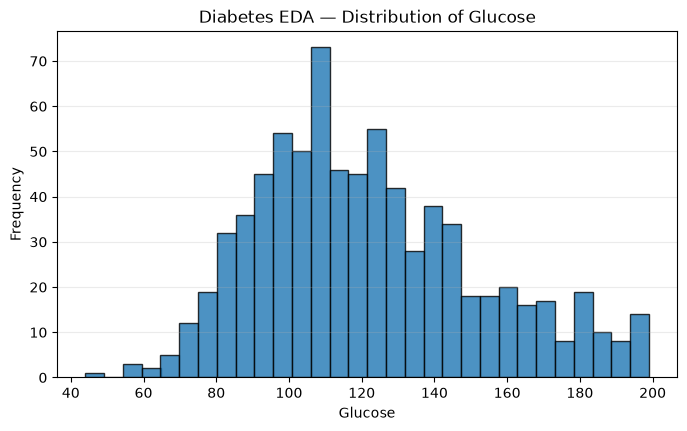

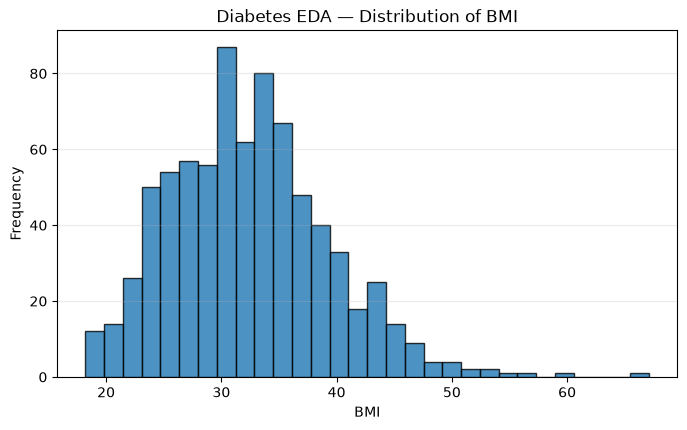

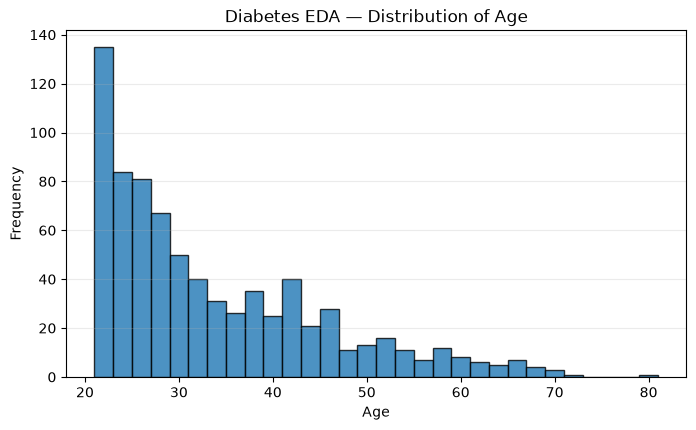

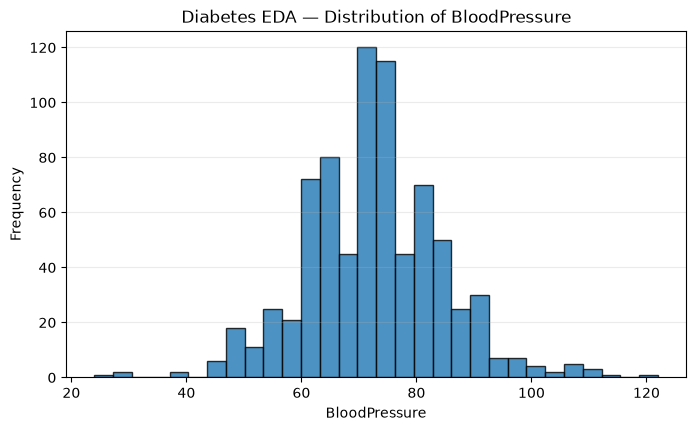

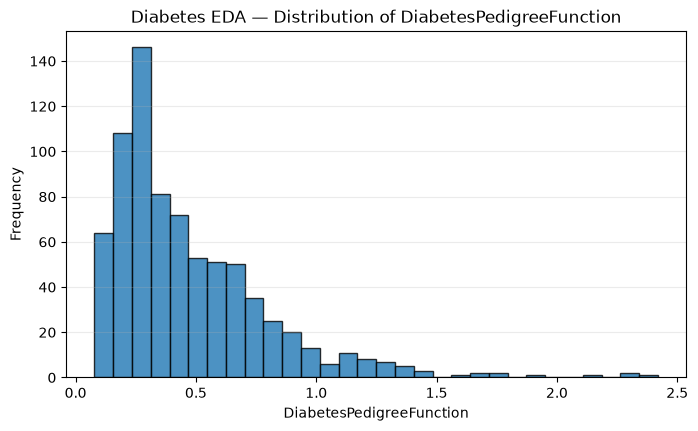

In [175]:
for feature in ["Glucose", "BMI", "Age", "BloodPressure", "DiabetesPedigreeFunction"]:
    plot_single_distribution(
        diabetes[feature], f"Diabetes EDA — Distribution of {feature}", feature, bins=30
    )

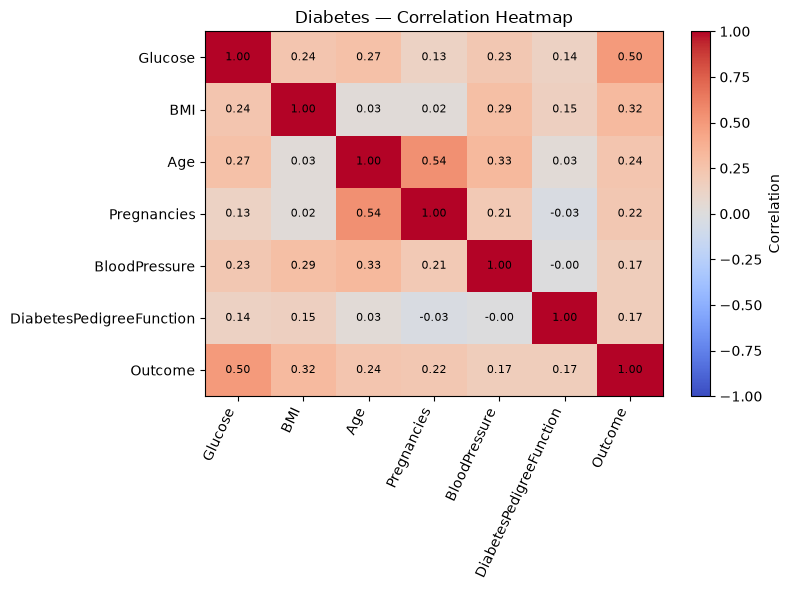

In [176]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_diabetes, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Correlation")
plt.xticks(
    range(len(corr_diabetes.columns)), corr_diabetes.columns, rotation=65, ha="right"
)
plt.yticks(range(len(corr_diabetes.columns)), corr_diabetes.columns)
for i in range(len(corr_diabetes.columns)):
    for j in range(len(corr_diabetes.columns)):
        plt.text(
            j, i, f"{corr_diabetes.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8
        )
plt.title("Diabetes — Correlation Heatmap")
plt.tight_layout()
plt.show()

### Diễn giải kết quả EDA

**Biểu đồ phân bố.**  
Các biểu đồ cho thấy năm features có hình dạng phân bố khá khác nhau. `Glucose` tập trung nhiều nhất khoảng 90–140 và có đuôi kéo tới gần 200. `BMI` tập trung chủ yếu quanh 25–40 nhưng lệch phải, với một số observation trên 50. `Age` lệch phải rất rõ: phần lớn observation nằm ở nhóm tuổi khoảng 20–35, sau đó tần suất giảm dần và chỉ còn rất ít trường hợp trên 60 tuổi. `BloodPressure` tập trung mạnh quanh khoảng 60–85 và có một số giá trị thấp hoặc cao nằm xa vùng trung tâm. `DiabetesPedigreeFunction` cũng lệch phải mạnh: phần lớn giá trị nhỏ hơn khoảng 0.8 nhưng có một đuôi dài tới trên 2.

Như vậy dataset không có một dạng phân bố chung cho tất cả features. Đặc biệt, `Age` và `DiabetesPedigreeFunction` có long tail, trong khi `BloodPressure` tập trung hơn quanh vùng trung tâm. Điều này ủng hộ việc đặt preprocessing trong pipeline thay vì giả định các features có cùng scale hoặc cùng phân bố.

**Correlation heatmap.**  
Trong các feature đang dùng, `Glucose` có tương quan tuyến tính với `Outcome` lớn nhất, khoảng **0.50**. Tiếp theo là `BMI` khoảng **0.32**, `Age` khoảng **0.24**, `Pregnancies` khoảng **0.22**, còn `BloodPressure` và `DiabetesPedigreeFunction` đều chỉ khoảng **0.17**. Điều này cho thấy `Glucose` là tín hiệu tuyến tính nổi bật nhất đối với target trong representation hiện tại.

Heatmap cũng cho thấy một số features tương quan với nhau, đáng chú ý nhất là `Age` và `Pregnancies` khoảng **0.54**. Tuy nhiên không có cặp feature nào trong representation đạt tương quan gần tuyệt đối, vì vậy không có dấu hiệu hai biến đơn giản chỉ là bản sao tuyến tính của nhau.

Kết hợp histogram và heatmap, có thể thấy dataset chứa cả sự khác biệt về phân bố lẫn mức độ liên hệ với target. Đây cũng là lý do việc đánh giá representation bằng cross-validation vẫn cần thiết thay vì chỉ chọn feature dựa vào correlation.


## 8. Chia tập huấn luyện và kiểm thử

Dữ liệu được chia theo tỷ lệ 80% huấn luyện và 20% kiểm thử. Tham số `stratify=y` duy trì tỷ lệ hai lớp giữa hai tập. Tập kiểm thử không tham gia vào quá trình lựa chọn thuật toán, lựa chọn representation hoặc khảo sát siêu tham số; tập này chỉ được sử dụng cho đánh giá cuối cùng.


In [177]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diabetes, y_diabetes, test_size=0.20, random_state=SEED, stratify=y_diabetes
)
print("Shape của training set:", X_train_d.shape)
print("Shape của test set:", X_test_d.shape)
print("Train positive rate:", round(y_train_d.mean(), 4))
print("Test positive rate:", round(y_test_d.mean(), 4))

Shape của training set: (614, 6)
Shape của test set: (154, 6)
Train positive rate: 0.3485
Test positive rate: 0.3506


## 9. Mô hình baseline

`DummyClassifier(strategy="most_frequent")` được sử dụng làm baseline. Mô hình này luôn dự đoán lớp phổ biến nhất và không học quan hệ giữa các đặc trưng với biến đích. Vì vậy, baseline cung cấp một mốc tham chiếu tối thiểu để xác định liệu các mô hình học máy có tạo ra giá trị dự đoán vượt quá một chiến lược đơn giản hay không.


In [178]:
diabetes_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
classification_scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
}
baseline_d = DummyClassifier(strategy="most_frequent")
s = cross_validate(
    baseline_d,
    X_train_d,
    y_train_d,
    cv=diabetes_cv,
    scoring=classification_scoring,
    n_jobs=1,
)
baseline_d_result = {
    "Accuracy": s["test_accuracy"].mean(),
    "Precision": s["test_precision"].mean(),
    "Recall": s["test_recall"].mean(),
    "F1": s["test_f1"].mean(),
}
display(pd.DataFrame([baseline_d_result], index=["DummyClassifier"]).round(4))

,Accuracy,Precision,Recall,F1
DummyClassifier,0.6515,0.0000,0.0000,0.0000


## 10-14. Các mô hình Machine Learning truyền thống

Năm thuật toán được xây dựng trên cùng một representation sáu chiều. Tiền xử lý được đặt bên trong `Pipeline`, nhờ đó các thống kê imputation và scaling luôn được ước lượng chỉ từ phần dữ liệu huấn luyện tương ứng trong từng fold.

| Mô hình             | Representation đầu vào | Quan hệ học được                   | Cấu trúc học được        | Tiêu chí chính            | Giả định chính                                   | Ưu điểm                        | Hạn chế                             |
| ------------------- | ---------------------- | ---------------------------------- | ------------------------ | ------------------------- | ------------------------------------------------ | ------------------------------ | ----------------------------------- |
| Logistic Regression | 6D đã standardize      | ranh giới log-odds tuyến tính      | weights + bias           | log-loss                  | log-odds có thể xấp xỉ tuyến tính từ các feature | dễ diễn giải, ổn định          | hạn chế với quan hệ phi tuyến       |
| KNN                 | 6D đã standardize      | quan hệ theo lân cận cục bộ        | lưu các mẫu huấn luyện   | distance + voting         | các quan sát gần nhau có xu hướng cùng nhãn      | đơn giản, xử lý được phi tuyến | nhạy với scaling và giá trị `k`     |
| Decision Tree       | 6D đã impute           | luật quyết định đệ quy             | các ngưỡng split         | giảm impurity             | các vùng lớp có thể tạo bằng feature-wise splits | dễ diễn giải bằng luật         | dễ overfit                          |
| Random Forest       | 6D đã impute           | tập hợp nhiều luật phi tuyến       | nhiều decision trees     | tổng hợp dự đoán từ trees | kết hợp nhiều trees giúp giảm variance           | mạnh và tương đối robust       | khó diễn giải hơn                   |
| SVM (RBF)           | 6D đã standardize      | ranh giới maximum-margin phi tuyến | support vectors + kernel | margin objective          | các lớp tách tốt hơn trong RBF feature space     | ranh giới linh hoạt            | nhạy với scaling và hyperparameters |


In [179]:
diabetes_models = {
    "Logistic Regression": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, random_state=SEED)),
        ]
    ),
    "KNN": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=15)),
        ]
    ),
    "Decision Tree": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DecisionTreeClassifier(max_depth=5, random_state=SEED)),
        ]
    ),
    "Random Forest": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestClassifier(n_estimators=150, random_state=SEED, n_jobs=1),
            ),
        ]
    ),
    "SVM (RBF)": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", C=1.0, probability=True, random_state=SEED)),
        ]
    ),
}
print(list(diabetes_models))

['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'SVM (RBF)']


## 15. Đánh giá mô hình

Các mô hình phân loại được đánh giá bằng bốn độ đo định lượng: **Accuracy, Precision, Recall và F1-score**. Ngoài bảng so sánh, kết quả được trực quan hóa bằng các biểu đồ tương ứng. Confusion Matrix được sử dụng cho mô hình cuối cùng để mô tả chi tiết số lượng true positive, true negative, false positive và false negative. ROC curve và ROC-AUC được bổ sung để quan sát khả năng phân biệt hai lớp theo nhiều ngưỡng dự đoán khác nhau.

Do phân bố hai lớp không hoàn toàn cân bằng và Accuracy một mình có thể che giấu khả năng nhận diện lớp positive, **F1-score được chọn làm metric chính để lựa chọn model**. Precision và Recall được phân tích riêng để quan sát hai loại sai lệch, trong khi Accuracy cung cấp góc nhìn tổng thể.

Việc so sánh năm mô hình ở giai đoạn này sử dụng 5-fold cross-validation trên tập huấn luyện.


In [180]:
rows = []
for name, model in diabetes_models.items():
    s = cross_validate(
        model,
        X_train_d,
        y_train_d,
        cv=diabetes_cv,
        scoring=classification_scoring,
        n_jobs=1,
    )
    rows.append(
        {
            "Model": name,
            "Accuracy": s["test_accuracy"].mean(),
            "Precision": s["test_precision"].mean(),
            "Recall": s["test_recall"].mean(),
            "F1": s["test_f1"].mean(),
        }
    )
diabetes_cv_results = (
    pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
)
display(diabetes_cv_results.round(4))

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.7899,0.7597,0.5889,0.6618
1,SVM (RBF),0.7785,0.7469,0.5703,0.6417
2,Random Forest,0.7654,0.7022,0.5888,0.6376
3,KNN,0.7508,0.6985,0.5426,0.6022
4,Decision Tree,0.7166,0.6202,0.4903,0.5447


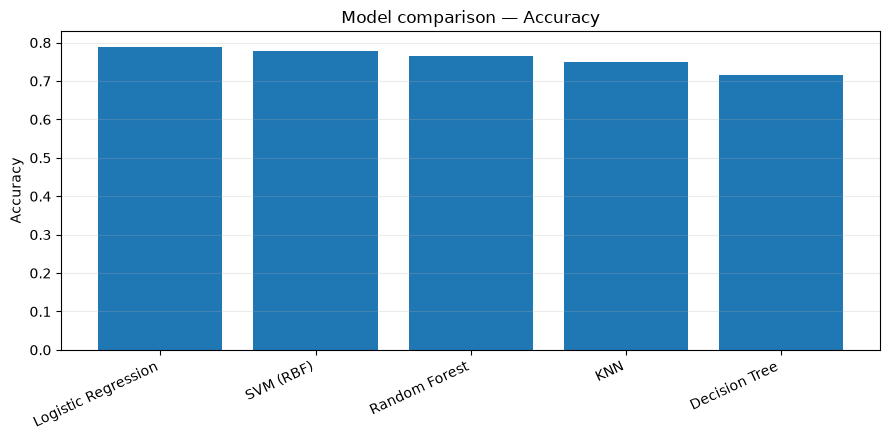

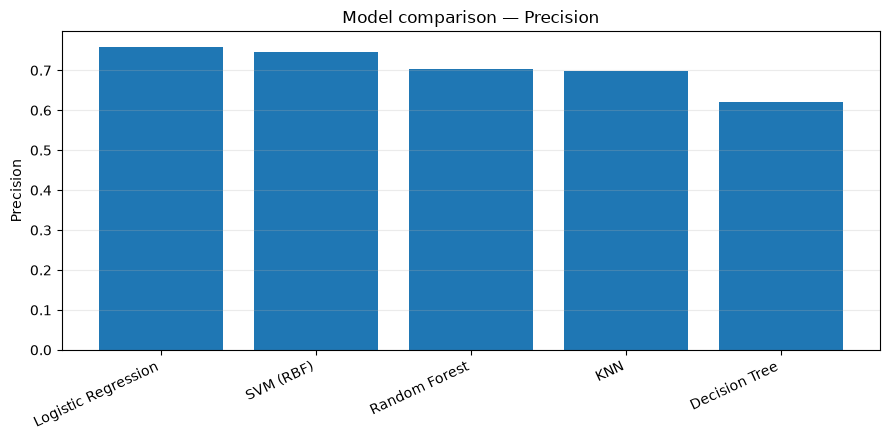

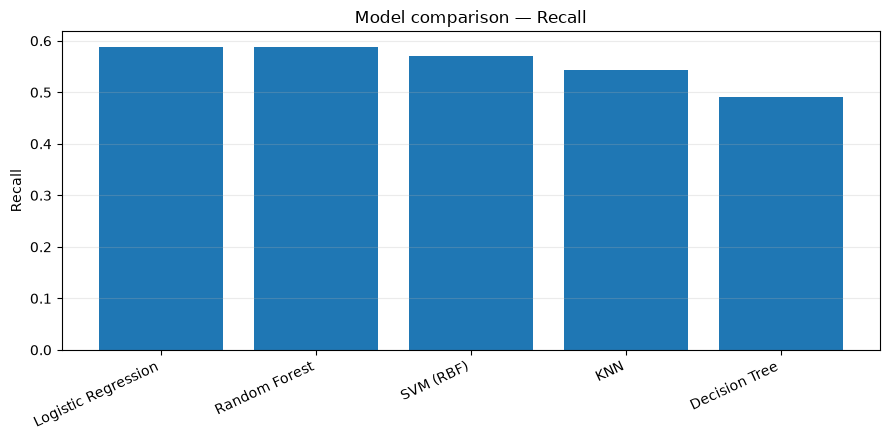

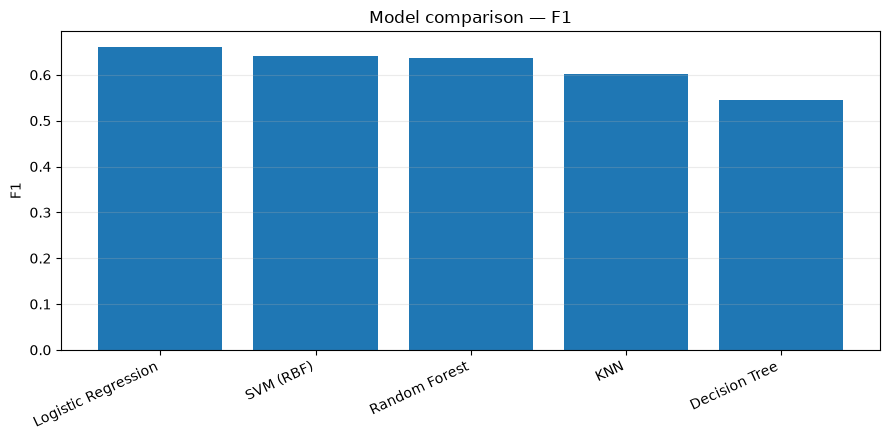

In [181]:
for metric in ["Accuracy", "Precision", "Recall", "F1"]:
    plot_metric_bar(diabetes_cv_results, metric, higher_is_better=True)

### Diễn giải biểu đồ đánh giá mô hình

Bốn biểu đồ cho thấy **Logistic Regression là model ổn định nhất trong nhóm năm classifier**. Nó đạt Accuracy **0.7899**, Precision **0.7597** và F1 **0.6618**, đều cao nhất trong bảng cross-validation. Recall của Logistic Regression là **0.5889**, gần như ngang Random Forest (**0.5888**) và nhỉnh hơn SVM (**0.5703**).

SVM đứng thứ hai về Accuracy, Precision và F1 với F1 **0.6417**. Random Forest có Recall gần bằng Logistic Regression nhưng Precision thấp hơn đáng kể (**0.7022** so với **0.7597**), nên F1 chỉ còn **0.6376**. KNN thấp hơn nhóm ba model trên, còn Decision Tree đứng cuối ở cả Accuracy (**0.7166**), Precision (**0.6202**), Recall (**0.4903**) và F1 (**0.5447**).

Một pattern quan trọng là **Precision của tất cả model đều cao hơn Recall**. Ngay cả model tốt nhất cũng chỉ có Recall khoảng **0.59**, nghĩa là khả năng phát hiện lớp positive vẫn là điểm yếu hơn so với khả năng tránh false positive. Vì tiêu chí lựa chọn đã đặt trước là mean CV F1, Logistic Regression được chọn hợp lý: nó tạo cân bằng Precision–Recall tốt nhất trong các model được thử, chứ không chỉ thắng ở Accuracy.


## 16. Thí nghiệm 1 — So sánh mô hình

Thí nghiệm thứ nhất trả lời câu hỏi: **trong cùng một representation sáu đặc trưng, cùng quy trình tiền xử lý và cùng 5-fold cross-validation, mô hình nào đạt F1-score trung bình cao nhất?**

Tập huấn luyện, tập đặc trưng, số fold và random seed được giữ cố định; biến độc lập duy nhất là thuật toán học máy. Thiết kế này cho phép quy khác biệt về kết quả chủ yếu cho lựa chọn mô hình.


In [182]:
best_diabetes_model_name = diabetes_cv_results.iloc[0]["Model"]
best_diabetes_cv_f1 = float(diabetes_cv_results.iloc[0]["F1"])
print("Best model by mean CV F1:", best_diabetes_model_name)
print("Mean CV F1:", round(best_diabetes_cv_f1, 4))

Best model by mean CV F1: Logistic Regression
Mean CV F1: 0.6618


## 17. Thí nghiệm 2 — Khảo sát hyperparameter

Thí nghiệm thứ hai khảo sát ảnh hưởng của tham số `n_neighbors = k` đối với KNN. Representation, imputation, standardization và cross-validation protocol được giữ nguyên, trong khi `k` lần lượt nhận nhiều giá trị khác nhau. F1-score trung bình qua các fold được sử dụng để đánh giá ảnh hưởng của kích thước lân cận đến khả năng phân loại.


,k,Mean CV F1
0,3,0.6099
1,5,0.6203
2,7,0.5905
3,9,0.5987
4,11,0.6000
5,15,0.6022
6,19,0.6146
7,25,0.6250


Best k: 25


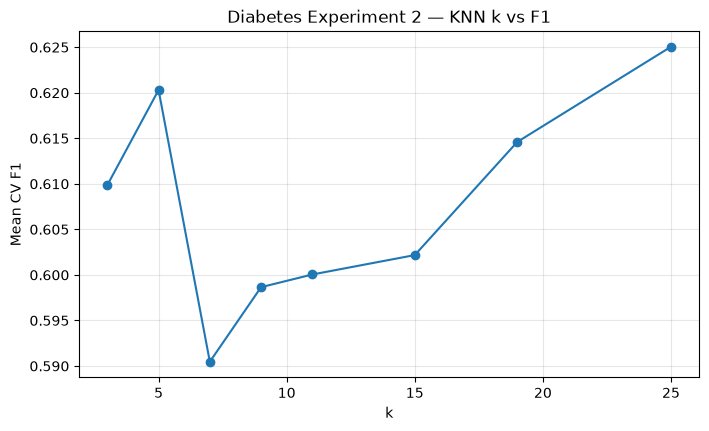

In [183]:
k_values = [3, 5, 7, 9, 11, 15, 19, 25]
knn_scores = []
for k in k_values:
    p = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=k)),
        ]
    )
    s = cross_val_score(
        p,
        X_train_d,
        y_train_d,
        cv=diabetes_cv,
        scoring=make_scorer(f1_score, zero_division=0),
        n_jobs=1,
    )
    knn_scores.append(s.mean())
knn_experiment = pd.DataFrame({"k": k_values, "Mean CV F1": knn_scores})
display(knn_experiment.round(4))
best_k = int(knn_experiment.loc[knn_experiment["Mean CV F1"].idxmax(), "k"])
print("Best k:", best_k)
plt.figure(figsize=(8, 4.5))
plt.plot(k_values, knn_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Mean CV F1")
plt.title("Diabetes Experiment 2 — KNN k vs F1")
plt.grid(alpha=0.3)
plt.show()

### Diễn giải biểu đồ hyperparameter của KNN

KNN không cải thiện đều khi `k` tăng. Mean CV F1 tăng từ **0.6099 tại k=3** lên **0.6203 tại k=5**, sau đó giảm mạnh xuống mức thấp nhất **0.5905 tại k=7**. Từ `k=9` trở đi, F1 tăng dần: **0.5987 → 0.6000 → 0.6022 → 0.6146**, và đạt giá trị cao nhất trong các cấu hình đã thử là **0.6250 tại k=25**.

Như vậy hiệu năng của KNN khá nhạy với lựa chọn `k`, đặc biệt ở vùng `k` nhỏ. Trong khoảng đã thử, các giá trị lớn hơn tạo kết quả ổn định hơn sau điểm giảm tại `k=7`. Tuy nhiên ngay cả cấu hình tốt nhất `k=25` vẫn thấp hơn F1 của Logistic Regression (**0.6618**), nên tuning `k` chưa làm KNN trở thành lựa chọn tốt nhất.

Do điểm tốt nhất nằm ngay tại biên trên của tập giá trị đã khảo sát (`k=25`), thí nghiệm chỉ cho phép kết luận rằng **25 là tốt nhất trong các giá trị đã thử**, không phải 25 chắc chắn là giá trị tối ưu toàn cục.


## 18. Thí nghiệm 3 — Khảo sát representation / feature

Thí nghiệm thứ ba đánh giá trực tiếp ảnh hưởng của representation. Hai biểu diễn được so sánh:

\[
X_3=[Glucose,BMI,Age]
\]

và

\[
X_6=[Glucose,BMI,Age,Pregnancies,BloodPressure,DiabetesPedigreeFunction]
\]

Cả hai representation sử dụng cùng Logistic Regression pipeline và cùng cross-validation protocol. Vì thuật toán và quy trình đánh giá được giữ cố định, thay đổi về F1-score phản ánh tác động của lượng thông tin được cung cấp cho mô hình.


,Representation,Accuracy,Precision,Recall,F1
0,3 features,0.7850,0.7474,0.5842,0.6550
1,6 features,0.7899,0.7597,0.5889,0.6618


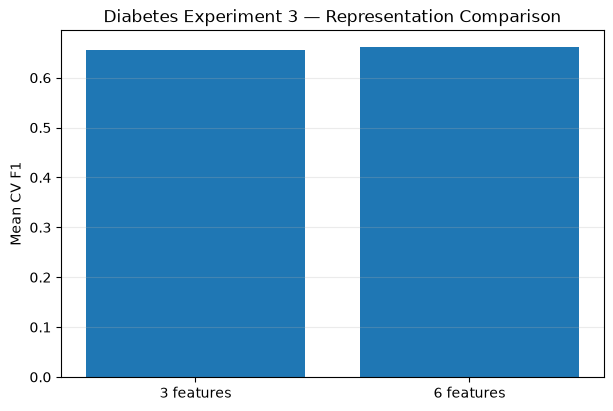

In [184]:
rep_model_d = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=SEED)),
    ]
)
rep_rows = []
for label, fs in {
    "3 features": ["Glucose", "BMI", "Age"],
    "6 features": DIABETES_FEATURES,
}.items():
    Xrep = diabetes.loc[X_train_d.index, fs]
    s = cross_validate(
        rep_model_d,
        Xrep,
        y_train_d,
        cv=diabetes_cv,
        scoring=classification_scoring,
        n_jobs=1,
    )
    rep_rows.append(
        {
            "Representation": label,
            "Accuracy": s["test_accuracy"].mean(),
            "Precision": s["test_precision"].mean(),
            "Recall": s["test_recall"].mean(),
            "F1": s["test_f1"].mean(),
        }
    )
diabetes_representation_results = pd.DataFrame(rep_rows)
display(diabetes_representation_results.round(4))
plt.figure(figsize=(7, 4.5))
plt.bar(
    diabetes_representation_results["Representation"],
    diabetes_representation_results["F1"],
)
plt.ylabel("Mean CV F1")
plt.title("Diabetes Experiment 3 — Representation Comparison")
plt.grid(axis="y", alpha=0.25)
plt.show()

### Diễn giải so sánh representation

Khi Logistic Regression chỉ dùng ba features `Glucose`, `BMI` và `Age`, mean CV F1 đạt **0.6550**. Khi mở rộng lên đủ sáu features, F1 tăng lên **0.6618**. Accuracy cũng tăng nhẹ từ **0.7850** lên **0.7899**, Precision từ **0.7474** lên **0.7597**, và Recall từ **0.5842** lên **0.5889**.

Như vậy representation sáu chiều **tốt hơn nhưng mức cải thiện khá nhỏ**: F1 chỉ tăng khoảng **0.0068**. Điều này cho thấy ba features bổ sung (`Pregnancies`, `BloodPressure`, `DiabetesPedigreeFunction`) có đóng góp thêm thông tin, nhưng phần lớn predictive signal của representation hiện tại đã nằm trong ba biến `Glucose`, `BMI` và `Age`.

Kết quả này phù hợp với heatmap trước đó: `Glucose` có correlation với `Outcome` cao nhất (**0.50**), `BMI` đứng thứ hai (**0.32**) và `Age` cũng cao hơn phần lớn các feature còn lại. Vì vậy, thêm feature mang lại lợi ích có thật nhưng không tạo ra bước nhảy lớn về hiệu năng.


## 19. Mô hình cuối cùng

Mô hình cuối cùng được xác định bằng F1-score trung bình cao nhất trên cross-validation của tập huấn luyện. Sau khi lựa chọn, pipeline tương ứng được huấn luyện lại trên toàn bộ tập huấn luyện và chỉ sau đó mới được đánh giá một lần trên tập kiểm thử độc lập. Kết quả cuối cùng được trình bày bằng Accuracy, Precision, Recall, F1-score, Confusion Matrix và ROC-AUC.


In [185]:
final_diabetes_model = clone(diabetes_models[best_diabetes_model_name])
final_diabetes_model.fit(X_train_d, y_train_d)
y_pred_d = final_diabetes_model.predict(X_test_d)
final_diabetes_metrics = classification_metrics(y_test_d, y_pred_d)
print("Final diabetes model:", best_diabetes_model_name)
display(pd.DataFrame([final_diabetes_metrics], index=["Held-out test"]).round(4))

Final diabetes model: Logistic Regression


,Accuracy,Precision,Recall,F1
Held-out test,0.6948,0.5778,0.4815,0.5253


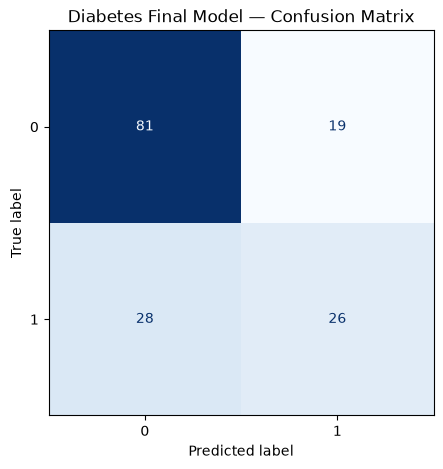

In [186]:
cm = confusion_matrix(y_test_d, y_pred_d)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Diabetes Final Model — Confusion Matrix")
plt.show()

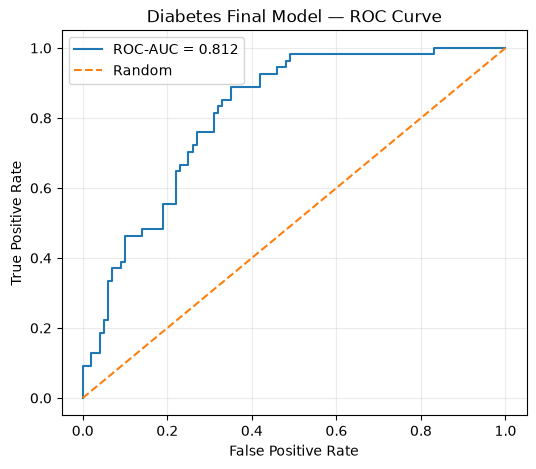

ROC-AUC: 0.8119


In [187]:
if hasattr(final_diabetes_model, "predict_proba"):
    y_prob_d = final_diabetes_model.predict_proba(X_test_d)[:, 1]
    auc_d = roc_auc_score(y_test_d, y_prob_d)
    fpr, tpr, _ = roc_curve(y_test_d, y_prob_d)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_d:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Diabetes Final Model — ROC Curve")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()
    print("ROC-AUC:", round(auc_d, 4))

### Diễn giải biểu đồ phân loại cuối cùng

**Confusion Matrix.**  
Trên tập kiểm thử độc lập, model dự đoán đúng **81 trường hợp lớp 0** và **26 trường hợp lớp 1**. Nó tạo **19 false positives** nhưng có tới **28 false negatives**. Với 54 observation thực sự thuộc lớp 1, model chỉ phát hiện đúng 26 trường hợp, tương ứng Recall **0.4815**. Ngược lại, trong 100 observation lớp 0, model nhận đúng 81 trường hợp.

Pattern này cho thấy threshold phân loại hiện tại thiên về việc nhận diện lớp 0 tốt hơn lớp 1. Đáng chú ý, số positive case bị bỏ sót (**28**) còn nhiều hơn số positive case phát hiện đúng (**26**). Điều này giải thích tại sao held-out Accuracy vẫn đạt **0.6948** nhưng F1 chỉ còn **0.5253** và Recall thấp hơn kết quả cross-validation.

**ROC Curve.**  
ROC curve nằm rõ ràng phía trên đường random và ROC-AUC đạt **0.8119**. Điều này cho thấy model vẫn có khả năng **xếp hạng / phân biệt hai lớp khá tốt** khi xét trên nhiều threshold khác nhau, dù confusion matrix tại threshold mặc định cho Recall chưa cao.

Kết hợp hai biểu đồ, vấn đề của final model không phải là hoàn toàn không tách được hai lớp; AUC khoảng 0.812 cho thấy vẫn có signal phân biệt đáng kể. Điểm hạn chế nằm nhiều hơn ở operating threshold hiện tại và ở sự đánh đổi giữa false positive với false negative. Vì Assignment lựa chọn model theo CV F1 và không thực hiện threshold tuning, kết quả này được giữ như đánh giá trung thực của pipeline cuối cùng.


In [188]:
DIABETES_MODEL_PATH = ARTIFACT_DIR / "diabetes_pipeline.joblib"
DIABETES_MODELS_DIR = ARTIFACT_DIR / "diabetes_models"
DIABETES_MODELS_DIR.mkdir(exist_ok=True)

DIABETES_MODEL_SLUGS = {
    "Logistic Regression": "logistic_regression",
    "KNN": "knn",
    "Decision Tree": "decision_tree",
    "Random Forest": "random_forest",
    "SVM (RBF)": "svm_rbf",
}

# Lưu artifact hiện có như recommended/final model.
joblib.dump(final_diabetes_model, DIABETES_MODEL_PATH)

# Fit một deployable pipeline cho từng thuật toán đã đánh giá.
# Recommended model dùng lại final_diabetes_model để artifact
# khớp đúng trained pipeline dùng cho held-out test evaluation.
diabetes_deployment_models = {}
for model_name, model_template in diabetes_models.items():
    if model_name == best_diabetes_model_name:
        fitted_model = final_diabetes_model
    else:
        fitted_model = clone(model_template)
        fitted_model.fit(X_train_d, y_train_d)

    model_id = DIABETES_MODEL_SLUGS[model_name]
    model_path = DIABETES_MODELS_DIR / f"{model_id}.joblib"
    joblib.dump(fitted_model, model_path)

    diabetes_deployment_models[model_id] = {
        "name": model_name,
        "artifact": str(Path("diabetes_models") / f"{model_id}.joblib"),
        "recommended": model_name == best_diabetes_model_name,
    }

recommended_diabetes_model_id = DIABETES_MODEL_SLUGS[best_diabetes_model_name]

meta = {
    "task": "binary_classification",
    "features": DIABETES_FEATURES,
    "target": DIABETES_TARGET,
    "selected_model": best_diabetes_model_name,
    "recommended_model_id": recommended_diabetes_model_id,
    "selection_metric": "mean_cv_f1",
    "available_models": diabetes_deployment_models,
    "test_metrics": {k: float(v) for k, v in final_diabetes_metrics.items()},
}
(ARTIFACT_DIR / "diabetes_metadata.json").write_text(
    json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8"
)

print("Saved recommended diabetes model:", DIABETES_MODEL_PATH)
print("Saved selectable diabetes models:")
for model_id, info in diabetes_deployment_models.items():
    marker = " <- recommended" if info["recommended"] else ""
    print(f"  {model_id}: {info['artifact']}{marker}")

Saved recommended diabetes model: artifacts\diabetes_pipeline.joblib
Saved selectable diabetes models:
  logistic_regression: diabetes_models\logistic_regression.joblib <- recommended
  knn: diabetes_models\knn.joblib
  decision_tree: diabetes_models\decision_tree.joblib
  random_forest: diabetes_models\random_forest.joblib
  svm_rbf: diabetes_models\svm_rbf.joblib


## 20. Knowledge Graph — Diabetes

Bên cạnh representation dạng vector, miền dữ liệu tiểu đường được mô hình hóa bằng một Knowledge Graph. Đồ thị biểu diễn các thực thể `Subject`, `Feature`, `Prediction`, `MLModel` và `TargetConcept`, cùng các quan hệ `HAS_FEATURE`, `HAS_PREDICTION`, `PREDICTED_BY` và `ABOUT`.

Feature vector phù hợp cho numerical learning, trong khi Knowledge Graph thể hiện rõ cấu trúc ngữ nghĩa giữa các thực thể. Script Cypher được sinh ra để representation này có thể được lưu trong Neo4j.


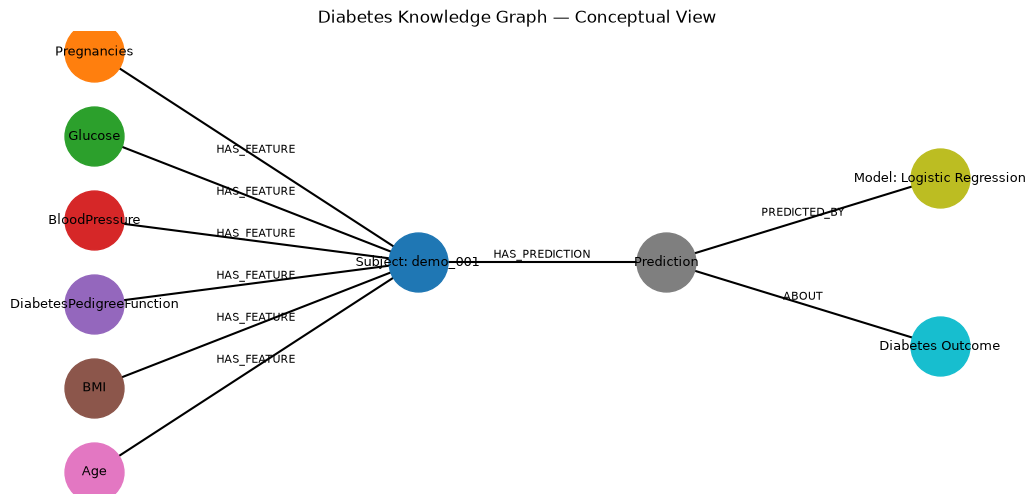

In [189]:
nodes = {
    "subject": "Subject: demo_001",
    "pregnancies": "Pregnancies",
    "glucose": "Glucose",
    "bp": "BloodPressure",
    "dpf": "DiabetesPedigreeFunction",
    "bmi": "BMI",
    "age": "Age",
    "pred": "Prediction",
    "model": f"Model: {best_diabetes_model_name}",
    "target": "Diabetes Outcome",
}
edges = [
    ("subject", "HAS_FEATURE", "pregnancies"),
    ("subject", "HAS_FEATURE", "glucose"),
    ("subject", "HAS_FEATURE", "bp"),
    ("subject", "HAS_FEATURE", "dpf"),
    ("subject", "HAS_FEATURE", "bmi"),
    ("subject", "HAS_FEATURE", "age"),
    ("subject", "HAS_PREDICTION", "pred"),
    ("pred", "PREDICTED_BY", "model"),
    ("pred", "ABOUT", "target"),
]
pos = {
    "subject": (0, 0),
    "pregnancies": (-2.6, 2.5),
    "glucose": (-2.6, 1.5),
    "bp": (-2.6, 0.5),
    "dpf": (-2.6, -0.5),
    "bmi": (-2.6, -1.5),
    "age": (-2.6, -2.5),
    "pred": (2, 0),
    "model": (4.2, 1),
    "target": (4.2, -1),
}
draw_simple_kg(nodes, edges, pos, "Diabetes Knowledge Graph — Conceptual View")

In [190]:
NEO4J_DIR = Path("neo4j_scripts")
NEO4J_DIR.mkdir(exist_ok=True)

diabetes_cypher = f"""
MERGE (s:Subject {{id:'demo_001'}})
MERGE (preg:Feature {{name:'Pregnancies'}})
MERGE (g:Feature {{name:'Glucose'}})
MERGE (bp:Feature {{name:'BloodPressure'}})
MERGE (dpf:Feature {{name:'DiabetesPedigreeFunction'}})
MERGE (b:Feature {{name:'BMI'}})
MERGE (a:Feature {{name:'Age'}})
MERGE (t:TargetConcept {{name:'Diabetes Outcome'}})
MERGE (m:MLModel {{name:'{best_diabetes_model_name}'}})
MERGE (p:Prediction {{task:'Diabetes Classification'}})
MERGE (s)-[:HAS_FEATURE]->(preg)
MERGE (s)-[:HAS_FEATURE]->(g)
MERGE (s)-[:HAS_FEATURE]->(bp)
MERGE (s)-[:HAS_FEATURE]->(dpf)
MERGE (s)-[:HAS_FEATURE]->(b)
MERGE (s)-[:HAS_FEATURE]->(a)
MERGE (s)-[:HAS_PREDICTION]->(p)
MERGE (p)-[:PREDICTED_BY]->(m)
MERGE (p)-[:ABOUT]->(t);
""".strip()

path = NEO4J_DIR / "diabetes_knowledge_graph.cypher"
path.write_text(diabetes_cypher, encoding="utf-8")
print(diabetes_cypher)
print()
print("Saved:", path)

MERGE (s:Subject {id:'demo_001'})
MERGE (preg:Feature {name:'Pregnancies'})
MERGE (g:Feature {name:'Glucose'})
MERGE (bp:Feature {name:'BloodPressure'})
MERGE (dpf:Feature {name:'DiabetesPedigreeFunction'})
MERGE (b:Feature {name:'BMI'})
MERGE (a:Feature {name:'Age'})
MERGE (t:TargetConcept {name:'Diabetes Outcome'})
MERGE (m:MLModel {name:'Logistic Regression'})
MERGE (p:Prediction {task:'Diabetes Classification'})
MERGE (s)-[:HAS_FEATURE]->(preg)
MERGE (s)-[:HAS_FEATURE]->(g)
MERGE (s)-[:HAS_FEATURE]->(bp)
MERGE (s)-[:HAS_FEATURE]->(dpf)
MERGE (s)-[:HAS_FEATURE]->(b)
MERGE (s)-[:HAS_FEATURE]->(a)
MERGE (s)-[:HAS_PREDICTION]->(p)
MERGE (p)-[:PREDICTED_BY]->(m)
MERGE (p)-[:ABOUT]->(t);

Saved: neo4j_scripts\diabetes_knowledge_graph.cypher


## 21. Tầng ứng dụng

Hệ thống triển khai sử dụng đúng sáu trường đầu vào đã được xác định trong representation. ứng dụng Web và ứng dụng Android Mobile gửi cùng một cấu trúc dữ liệu tới Flask REST API, đồng thời người dùng có thể chọn một trong năm classifier đã được đánh giá trong notebook. Backend chuyển dữ liệu thành một `DataFrame` có cùng tên và thứ tự cột với dữ liệu huấn luyện rồi truyền trực tiếp qua trained pipeline tương ứng với model được chọn.

Notebook vẫn lưu `diabetes_pipeline.joblib` như artifact của final/recommended model, đồng thời lưu thêm năm selectable pipelines trong `artifacts/diabetes_models/`. Vì mỗi artifact chứa cả preprocessing và estimator, logic xử lý ở giai đoạn triển khai nhất quán với logic được sử dụng khi huấn luyện. Backend trả về predicted class và positive-class probability của model được chọn.

Đây là kết quả dự đoán của mô hình học máy phục vụ mục đích học tập, không phải chẩn đoán y khoa.


## 22. Minh họa hệ thống

Ba trường hợp đầu vào đại diện cho các vùng giá trị khác nhau được đưa qua toàn bộ pipeline:

`Input → Feature Representation → Preprocessing → Model → Prediction`

Kết quả thu được minh họa khả năng xử lý dữ liệu chưa từng xuất hiện trong tập huấn luyện dưới đúng representation đã định nghĩa.


In [191]:
diabetes_demo_cases = pd.DataFrame(
    [
        {
            "Glucose": 85,
            "BMI": 22.0,
            "Age": 24,
            "Pregnancies": 1,
            "BloodPressure": 68,
            "DiabetesPedigreeFunction": 0.20,
        },
        {
            "Glucose": 125,
            "BMI": 29.5,
            "Age": 38,
            "Pregnancies": 3,
            "BloodPressure": 78,
            "DiabetesPedigreeFunction": 0.55,
        },
        {
            "Glucose": 180,
            "BMI": 36.0,
            "Age": 55,
            "Pregnancies": 6,
            "BloodPressure": 88,
            "DiabetesPedigreeFunction": 0.85,
        },
    ]
)[DIABETES_FEATURES]
r = diabetes_demo_cases.copy()
r["Predicted Outcome"] = final_diabetes_model.predict(diabetes_demo_cases)
if hasattr(final_diabetes_model, "predict_proba"):
    r["Positive-class probability"] = final_diabetes_model.predict_proba(
        diabetes_demo_cases
    )[:, 1]
display(r.round(4))

,Glucose,BMI,Age,Pregnancies,BloodPressure,DiabetesPedigreeFunction,Predicted Outcome,Positive-class probability
0,85,22.0000,24,1,68,0.2000,0,0.0185
1,125,29.5000,38,3,78,0.5500,0,0.2612
2,180,36.0000,55,6,88,0.8500,1,0.9233


## 23. Nhận xét — Diabetes

Hệ thống tiếp nhận sáu phép đo dạng số và lưu chúng trong một vector đặc trưng sáu chiều. Từ các ví dụ có nhãn trong tập huấn luyện, mô hình học quan hệ thống kê giữa representation này với `Outcome`, sau đó áp dụng quan hệ đã học cho các vector mới để tạo ra class prediction. Khả năng học từ ví dụ và tổng quát hóa sang dữ liệu chưa quan sát là thành phần có thể xem là biểu hiện của “intelligence” trong phạm vi Assignment 02.

Tuy nhiên, trained model không đồng nhất với toàn bộ intelligent system. Hệ thống hoàn chỉnh còn bao gồm bước tiếp nhận dữ liệu, tiền xử lý, biểu diễn, suy luận và hiển thị kết quả. Representation hiện tại chỉ giữ lại sáu thuộc tính có cấu trúc nên làm mất nhiều thông tin như lịch sử sức khỏe theo thời gian, bối cảnh lâm sàng, lối sống và các nguồn dữ liệu khác.

Feature-vector representation phù hợp vì dữ liệu gốc là các phép đo có cấu trúc và giữ trực tiếp các giá trị cần thiết cho traditional ML. Với nguồn dữ liệu khác, cùng vấn đề có thể được biểu diễn bằng **sequence** của các phép đo theo thời gian, **graph** liên kết subject–measurement–condition, **image** nếu sử dụng nguồn dữ liệu y khoa dạng ảnh, hoặc **learned embeddings**. Khi representation thay đổi, thông tin cung cấp cho learning algorithm cũng thay đổi; khi đó preprocessing, model phù hợp và loại pattern mà hệ thống có thể học cũng có thể thay đổi.

Xét theo tiến trình phát triển của AI, hệ thống này thuộc giai đoạn:

`Structured Data → Human-designed Features → Statistical/Traditional ML → Prediction`.


## 24. Kết luận — Diabetes

Nghiên cứu tình huống A đã xây dựng một hệ thống phân loại hoàn chỉnh từ dữ liệu có cấu trúc đến ứng dụng dự đoán. Hệ thống sử dụng representation sáu đặc trưng, thiết lập baseline, huấn luyện năm mô hình truyền thống, thực hiện ba thí nghiệm có kiểm soát và lựa chọn final model dựa trên bằng chứng cross-validation. Hiệu năng cuối cùng được đánh giá trên tập kiểm thử độc lập bằng nhiều độ đo và trực quan hóa. Representation dạng vector được bổ sung bằng Knowledge Graph và pipeline cuối cùng được lưu để phục vụ chung cho ứng dụng Web và ứng dụng Android Mobile thông qua REST API.


# PART B — VIETNAM HOUSE PRICE PREDICTION

## 1. Định nghĩa hệ thống và bài toán

Bài toán thứ hai xây dựng hệ thống dự đoán giá nhà (`Price`) từ các thuộc tính cấu trúc của một căn nhà. Vì `Price` là biến số liên tục, đây là một bài toán **regression**.

**Formal problem statement:**

> Given a feature vector describing a previously unseen house's structural attributes, predict its numerical `Price` value in **billions of Vietnamese Dong (VND)**.

Dataset gốc cung cấp mười một predictor thô, bao gồm cả thuộc tính numerical lẫn categorical/text. Danh sách đặc trưng thực sự được đưa vào mô hình không được cố định trước, mà được xác định thông qua một bước feature selection dựa trên các tiêu chí kỹ thuật như cardinality, tỉ lệ giá trị thiếu và kiểu dữ liệu (Mục 4.1). Kết quả của bước phân tích này là một representation sáu chiều gồm các thuộc tính numerical, được trình bày chi tiết ở Mục 5. Sau khi representation được xác định, hệ thống tiếp nhận sáu thuộc tính tương ứng của căn nhà từ ứng dụng Web hoặc ứng dụng Android Mobile, gửi dữ liệu tới Flask REST API, tạo representation sáu chiều, thực hiện tiền xử lý nhất quán với giai đoạn huấn luyện và sử dụng mô hình hồi quy đã lưu để sinh ra giá dự đoán theo đơn vị **tỷ VND**. Web và Mobile là hai client độc lập nhưng sử dụng cùng backend và cùng trained pipeline.


## 2. Sơ đồ hệ thống thông minh

```text
User / Environment
        │
        ▼
ứng dụng Web / ứng dụng Android Mobile
        │
        ▼
Six house attributes
        │
        ▼
Flask REST API
        │
        ▼
Feature vector x ∈ R^6
        │
        ▼
Median Imputation + Scaling when required
        │
        ▼
Traditional ML Regressor
        │
        ▼
Predicted Price
        │
        ▼
Web / Mobile Result
```


## 3. Nguồn dữ liệu

Bộ dữ liệu sử dụng là **House Price Prediction Dataset Vietnam - 2024**, được cung cấp trên Kaggle tại:

`https://www.kaggle.com/datasets/nguyentiennhan/vietnam-housing-dataset-2024`

File dữ liệu được sử dụng trong notebook là `vietnam_housing_dataset.csv`.


In [192]:
HOUSE_PATH = resolve_data_file("vietnam_housing_dataset.csv")
house_raw = pd.read_csv(HOUSE_PATH)
print("Dataset path:", HOUSE_PATH)
print("Shape:", house_raw.shape)
display(house_raw.head())

Dataset path: C:\DATA\assign\datasets\housing_price\vietnam_housing_dataset.csv
Shape: (30229, 12)


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0000,NaN,NaN,NaN,NaN,4.0000,NaN,NaN,Have certificate,NaN,8.6000
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0000,NaN,NaN,NaN,NaN,5.0000,NaN,NaN,NaN,NaN,7.5000
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0000,6.0000,13.0000,Đông - Bắc,Đông - Bắc,5.0000,NaN,NaN,Sale contract,NaN,8.9000
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0000,NaN,3.5000,Tây - Nam,Tây - Nam,2.0000,2.0000,3.0000,Have certificate,Full,5.3500
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0000,NaN,NaN,Đông - Nam,Đông - Nam,2.0000,4.0000,4.0000,Have certificate,Full,6.9000


## 4. Mô tả dữ liệu

Mỗi dòng dữ liệu biểu diễn một căn nhà hoặc một tin đăng bất động sản. Bộ dữ liệu có **30,229 dòng quan sát** và **12 cột**, gồm **11 raw đặc trưng đầu vào** và một target `Price`.

Các numerical đặc trưng đầu vào gồm `Area`, `Frontage`, `Access Road`, `Floors`, `Bedrooms` và `Bathrooms`. Các categorical/text features gồm `Address`, `House direction`, `Balcony direction`, `Legal status` và `Furniture state`. `Price` là numerical target được biểu diễn theo **tỷ VND**, vì vậy đây là bài toán regression.

Phân tích mô tả xem xét kích thước tập dữ liệu, kiểu dữ liệu, tỷ lệ missing value, cardinality và các đặc điểm representation của toàn bộ đặc trưng đầu vào trước khi lựa chọn vector đầu vào chính.


In [193]:
print("Rows:", len(house_raw))
print("Columns:", house_raw.shape[1])
display(house_raw.dtypes.to_frame("dtype"))
miss = house_raw.isna().sum().to_frame("missing_count")
miss["missing_percentage"] = (miss["missing_count"] / len(house_raw) * 100).round(2)
display(miss)
display(house_raw.describe(include="all").T)

Rows: 30229
Columns: 12


,dtype
Address,str
Area,float64
Frontage,float64
Access Road,float64
House direction,str
Balcony direction,str
Floors,float64
Bedrooms,float64
Bathrooms,float64
Legal status,str


,missing_count,missing_percentage
Address,0,0.0000
Area,0,0.0000
Frontage,11564,38.2500
Access Road,13297,43.9900
House direction,21239,70.2600
Balcony direction,24983,82.6500
Floors,3603,11.9200
Bedrooms,5162,17.0800
Bathrooms,7074,23.4000
Legal status,4506,14.9100


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Address,30229,10265,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,"30,229.0000",NaN,NaN,NaN,68.4987,48.0698,3.1000,40.0000,56.0000,80.0000,595.0000
Frontage,"18,665.0000",NaN,NaN,NaN,5.3617,4.3462,1.0000,4.0000,4.5000,5.0000,77.0000
Access Road,"16,932.0000",NaN,NaN,NaN,7.8538,7.4513,1.0000,4.0000,6.0000,10.0000,85.0000
House direction,8990,8,Đông - Nam,1916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Balcony direction,5246,8,Đông - Nam,1087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floors,"26,626.0000",NaN,NaN,NaN,3.4104,1.3289,1.0000,2.0000,3.0000,4.0000,10.0000
Bedrooms,"25,067.0000",NaN,NaN,NaN,3.5110,1.3091,1.0000,3.0000,3.0000,4.0000,9.0000
Bathrooms,"23,155.0000",NaN,NaN,NaN,3.3468,1.4002,1.0000,2.0000,3.0000,4.0000,9.0000
Legal status,25723,2,Have certificate,24774,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4.1. Phân tích lựa chọn đặc trưng

Trước khi xác định representation đầu vào ở Mục 5, mười một predictor gốc của dataset được phân tích theo các tiêu chí kỹ thuật: kiểu dữ liệu (numerical/categorical), tỉ lệ giá trị thiếu và số giá trị duy nhất (cardinality), nhằm làm rõ lý do chỉ sáu đặc trưng numerical được giữ lại cho hệ thống.


In [194]:
ALL_HOUSE_FEATURES = [
    "Address",
    "Area",
    "Frontage",
    "Access Road",
    "House direction",
    "Balcony direction",
    "Floors",
    "Bedrooms",
    "Bathrooms",
    "Legal status",
    "Furniture state",
]

SELECTED_HOUSE_FEATURES = [
    "Area",
    "Frontage",
    "Access Road",
    "Floors",
    "Bedrooms",
    "Bathrooms",
]

feature_rows = []

for feature in ALL_HOUSE_FEATURES:
    s = house_raw[feature]
    is_numeric = pd.api.types.is_numeric_dtype(s)

    feature_rows.append(
        {
            "Feature": feature,
            "Selected": feature in SELECTED_HOUSE_FEATURES,
            "Type": "Numerical" if is_numeric else "Categorical/Text",
            "Missing_%": s.isna().mean() * 100,
            "Unique_Values": s.nunique(dropna=True),
        }
    )

house_feature_selection = pd.DataFrame(feature_rows)

print("Bảng chẩn đoán kỹ thuật cho toàn bộ 11 predictor gốc — House Price")
display(house_feature_selection.round(2))

address_unique = house_raw["Address"].nunique(dropna=True)
print("Số giá trị duy nhất của Address:", f"{address_unique:,}")

Bảng chẩn đoán kỹ thuật cho toàn bộ 11 predictor gốc — House Price


,Feature,Selected,Type,Missing_%,Unique_Values
0,Address,False,Categorical/Text,0.0000,10265
1,Area,True,Numerical,0.0000,1512
2,Frontage,True,Numerical,38.2500,407
3,Access Road,True,Numerical,43.9900,140
4,House direction,False,Categorical/Text,70.2600,8
5,Balcony direction,False,Categorical/Text,82.6500,8
6,Floors,True,Numerical,11.9200,10
7,Bedrooms,True,Numerical,17.0800,9
8,Bathrooms,True,Numerical,23.4000,9
9,Legal status,False,Categorical/Text,14.9100,2


Số giá trị duy nhất của Address: 10,265


### Diễn giải kết quả phân tích lựa chọn đặc trưng — House Price

**Address.**
`Address` có **10,265** giá trị duy nhất trên toàn bộ dataset — cardinality cực cao dạng text/địa chỉ. One-hot encoding trực tiếp sẽ làm tăng số chiều đầu vào rất lớn. Khai thác `Address` một cách có ý nghĩa hơn cần một chiến lược representation riêng như trích xuất quận/huyện, geocoding hoặc học location feature, nằm ngoài phạm vi Assignment 02.

**House direction.**
Tỉ lệ thiếu **70.26%**. Đây là biến categorical, đòi hỏi cả xử lý missing-category lẫn encoding, trong khi phần lớn dữ liệu không có giá trị.

**Balcony direction.**
Tỉ lệ thiếu **82.65%**. Biến categorical và không có sẵn ở phần lớn quan sát, khiến nó trở thành input không đáng tin cậy nếu bắt buộc trong ứng dụng.

**Furniture state.**
Tỉ lệ thiếu **46.71%**. Biến categorical, cần cả xử lý missing-value lẫn encoding.

**Legal status.**
Tỉ lệ thiếu **14.91%**, cardinality tương đối thấp nên hoàn toàn có thể encode trong phiên bản sau. Biến này bị loại khỏi representation hiện tại chỉ để giữ input chính đồng nhất về mặt numerical, không phải vì bị xem là không liên quan.

**Quyết định lựa chọn đặc trưng.**
Hệ thống triển khai giữ lại sáu thuộc tính cấu trúc dạng numerical `[Area, Frontage, Access Road, Floors, Bedrooms, Bathrooms]`. Sáu đặc trưng này có thể biểu diễn trực tiếp trong một vector numerical đồng nhất và dùng chung một chiến lược tiền xử lý (chủ yếu median imputation và scaling tùy chọn). Các predictor bị loại đòi hỏi chiến lược representation khác biệt đáng kể do cardinality cao, cần categorical encoding và/hoặc tỉ lệ thiếu lớn. Vì vậy, representation sáu chiều là một quyết định thiết kế representation có chủ đích, không phải là khẳng định rằng các predictor gốc bị loại không mang thông tin hữu ích.


## 5. Biểu diễn dữ liệu

Dựa trên phân tích feature selection ở Mục 4.1, vector đặc trưng chính được xác định như sau:

\[
x=[Area,Frontage,AccessRoad,Floors,Bedrooms,Bathrooms]
\]

| Feature     | Type      | Model representation | Meaning           |
| ----------- | --------- | -------------------- | ----------------- |
| Area        | Numerical | real value           | house area        |
| Frontage    | Numerical | median-imputed       | frontage width    |
| Access Road | Numerical | median-imputed       | access-road width |
| Floors      | Numerical | median-imputed       | number of floors  |
| Bedrooms    | Numerical | median-imputed       | bedrooms          |
| Bathrooms   | Numerical | median-imputed       | bathrooms         |

Biến đích là `Price`, được biểu diễn theo **tỷ VND**. Các missing value trong sáu đặc trưng được xử lý bằng median imputation bên trong pipeline.

Các các đặc trưng categorical/text thô `Address`, `House direction`, `Balcony direction`, `Legal status` và `Furniture state` không được encode trong representation chính trong phần tabular baseline của Assignment 02. Hệ thống chủ động chọn sáu numerical features để tạo representation đơn giản và nhất quán giữa training và application. Do đó:

`raw feature ≠ selected feature ≠ model input`.

Representation này có ưu điểm là đơn giản, trực tiếp và phù hợp với giao diện dự đoán, nhưng không giữ các thông tin như vị trí từ `Address`, hướng nhà, tình trạng pháp lý và nội thất — những yếu tố có khả năng ảnh hưởng đến giá bất động sản.


In [195]:
HOUSE_FEATURES = ["Area", "Frontage", "Access Road", "Floors", "Bedrooms", "Bathrooms"]
HOUSE_TARGET = "Price"
assert set(HOUSE_FEATURES + [HOUSE_TARGET]).issubset(house_raw.columns)
house = house_raw.copy()
X_house = house[HOUSE_FEATURES].copy()
y_house = house[HOUSE_TARGET].astype(float).copy()
print("X shape:", X_house.shape, "y shape:", y_house.shape)

X shape: (30229, 6) y shape: (30229,)


## 6. Phân tích đặc trưng và biến mục tiêu

Bài toán hồi quy được mô tả bởi:

$$
\hat{y}=f_\theta(x),\quad x\in\mathbb{R}^6,\quad \hat{y}\in\mathbb{R}
$$

Phân tích ban đầu tập trung vào mức độ thiếu dữ liệu, miền giá trị của từng đặc trưng và tương quan tuyến tính với `Price`. Các thống kê này hỗ trợ việc hiểu representation, nhưng quyết định về chất lượng representation được đánh giá riêng bằng controlled experiment.


In [196]:
summary = pd.DataFrame(
    {
        "dtype": X_house.dtypes.astype(str),
        "missing_count": X_house.isna().sum(),
        "missing_%": (X_house.isna().mean() * 100).round(2),
        "min": X_house.min(),
        "median": X_house.median(),
        "max": X_house.max(),
    }
)
display(summary)
corr_house = house[HOUSE_FEATURES + [HOUSE_TARGET]].corr(numeric_only=True)
display(corr_house.round(3))

,dtype,missing_count,missing_%,min,median,max
Area,float64,0,0.0000,3.1000,56.0000,595.0000
Frontage,float64,11564,38.2500,1.0000,4.5000,77.0000
Access Road,float64,13297,43.9900,1.0000,6.0000,85.0000
Floors,float64,3603,11.9200,1.0000,3.0000,10.0000
Bedrooms,float64,5162,17.0800,1.0000,3.0000,9.0000
Bathrooms,float64,7074,23.4000,1.0000,3.0000,9.0000


,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,Price
Area,1.0000,0.2610,0.2690,-0.3590,0.0300,-0.0390,0.0980
Frontage,0.2610,1.0000,0.1420,-0.0400,0.0150,0.0140,0.0470
Access Road,0.2690,0.1420,1.0000,-0.0560,0.0740,0.0720,0.1640
Floors,-0.3590,-0.0400,-0.0560,1.0000,0.4990,0.6210,0.3320
Bedrooms,0.0300,0.0150,0.0740,0.4990,1.0000,0.7820,0.3890
Bathrooms,-0.0390,0.0140,0.0720,0.6210,0.7820,1.0000,0.4340
Price,0.0980,0.0470,0.1640,0.3320,0.3890,0.4340,1.0000


## 7. Phân tích khám phá dữ liệu (EDA)

Năm phân bố được khảo sát gồm `Price`, `Area`, `Frontage`, `Access Road` và `Bedrooms`. Các histogram mô tả cấu trúc phân bố, mức độ lệch và phạm vi giá trị của các biến. Ma trận tương quan được sử dụng để quan sát quan hệ tuyến tính, trong khi scatter plot giữa `Area` và `Price` cung cấp một góc nhìn trực quan về quan hệ giữa diện tích và giá.


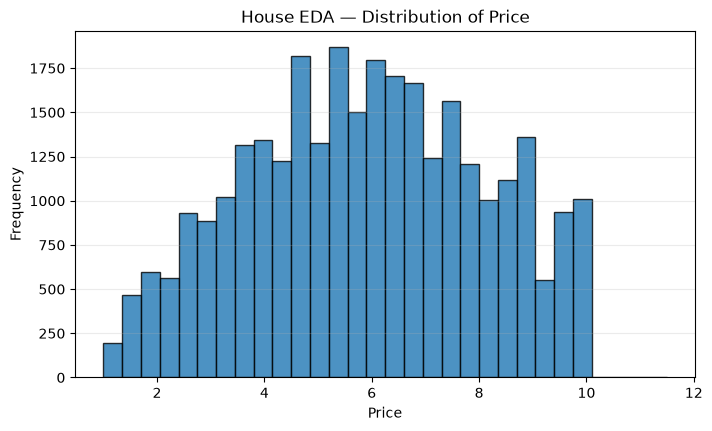

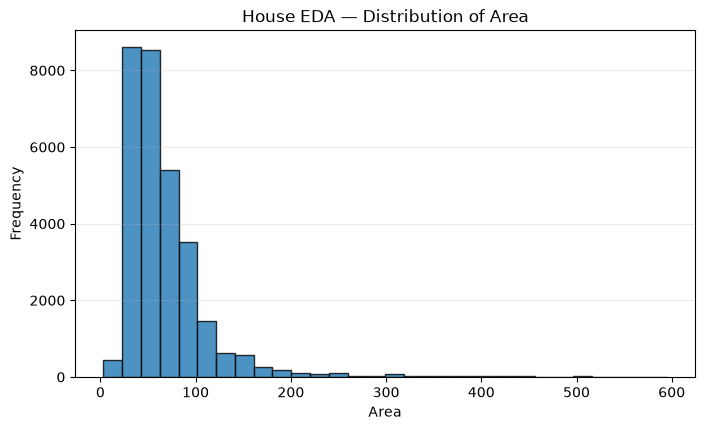

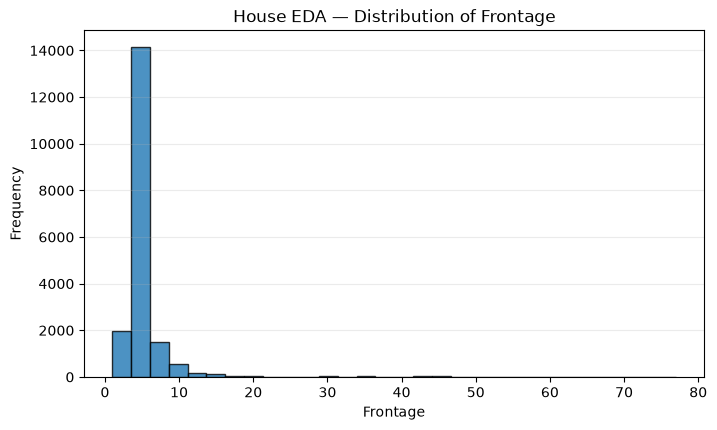

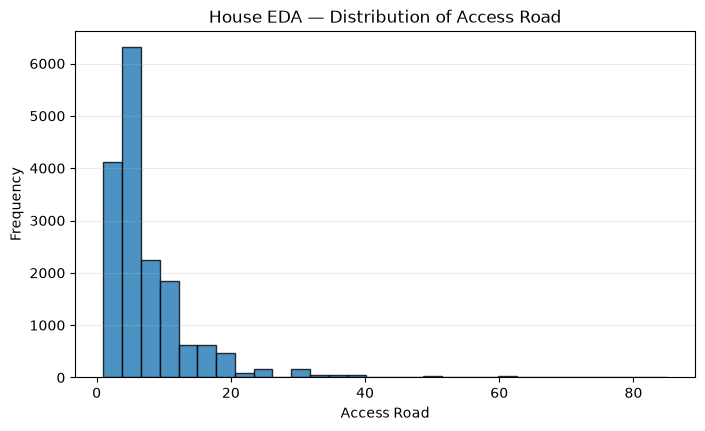

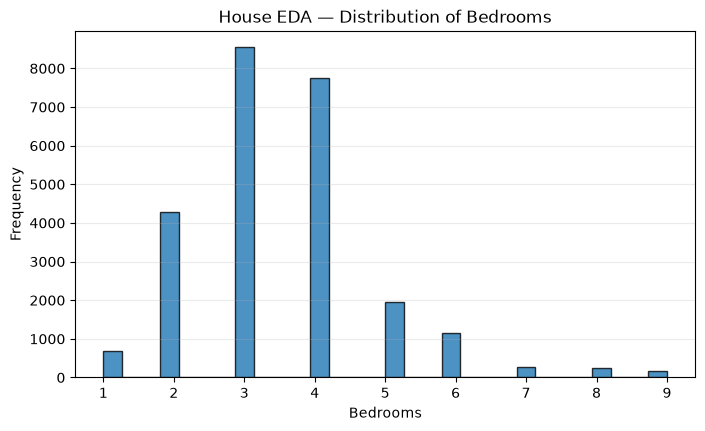

In [197]:
for col in ["Price", "Area", "Frontage", "Access Road", "Bedrooms"]:
    plot_single_distribution(
        house[col], f"House EDA — Distribution of {col}", col, bins=30
    )

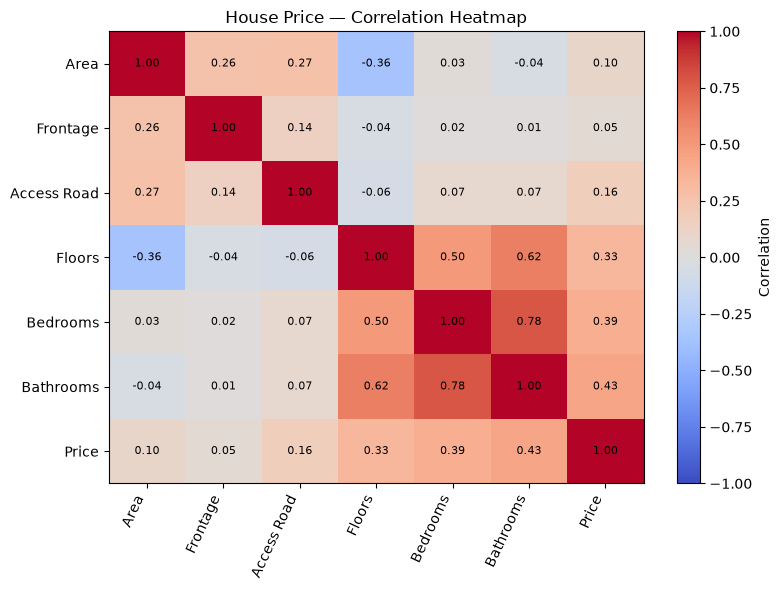

In [198]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_house, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_house.columns)), corr_house.columns, rotation=65, ha="right")
plt.yticks(range(len(corr_house.columns)), corr_house.columns)
for i in range(len(corr_house.columns)):
    for j in range(len(corr_house.columns)):
        plt.text(
            j, i, f"{corr_house.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8
        )
plt.title("House Price — Correlation Heatmap")
plt.tight_layout()
plt.show()

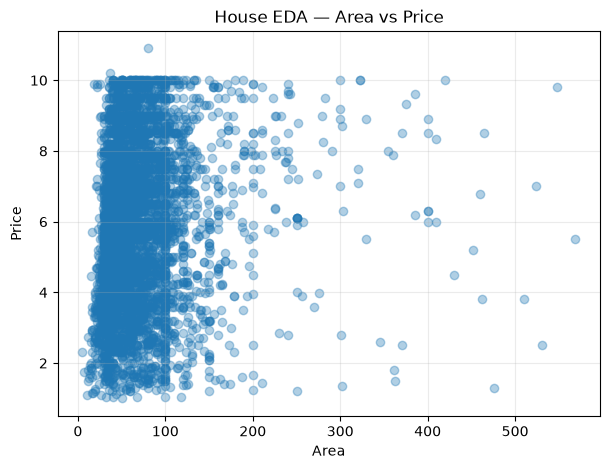

In [199]:
sc = house[["Area", "Price"]].dropna()
if len(sc) > 5000:
    sc = sc.sample(5000, random_state=SEED)
plt.figure(figsize=(7, 5))
plt.scatter(sc["Area"], sc["Price"], alpha=0.35)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("House EDA — Area vs Price")
plt.grid(alpha=0.25)
plt.show()

### Diễn giải kết quả EDA

**Biểu đồ phân bố.**  
`Price` trải rộng chủ yếu trong khoảng khoảng **1–10** và không tập trung vào một vùng hẹp duy nhất. Trái lại, `Area`, `Frontage` và `Access Road` đều **lệch phải rất mạnh**. Phần lớn `Area` nằm dưới khoảng 100 nhưng có một đuôi dài tới hơn 500; `Frontage` tập trung chủ yếu quanh vài mét nhưng có một số giá trị kéo tới khoảng 70–80; `Access Road` cũng tập trung ở vùng thấp nhưng xuất hiện một số observation rất lớn. `Bedrooms` là biến rời rạc, trong đó nhà **3 và 4 phòng ngủ chiếm ưu thế rõ rệt**, sau đó mới tới 2, 5 và 6 phòng.

Các long tail của `Area`, `Frontage` và `Access Road` cho thấy dataset có một số căn nhà rất khác phần lớn quan sát về kích thước hoặc điều kiện tiếp cận. Đây là những observation có thể làm bài toán hồi quy khó hơn nếu model chỉ học một quan hệ tuyến tính đơn giản.

**Correlation heatmap.**  
Trong sáu input features, `Bathrooms` có correlation với `Price` cao nhất, khoảng **0.43**, tiếp theo là `Bedrooms` **0.39** và `Floors` **0.33**. `Access Road` chỉ khoảng **0.16**, `Area` khoảng **0.10**, còn `Frontage` gần như rất yếu ở khoảng **0.05**.

Một số input features lại tương quan mạnh với nhau: `Bedrooms`–`Bathrooms` khoảng **0.78**, `Floors`–`Bathrooms` khoảng **0.62** và `Floors`–`Bedrooms` khoảng **0.50**. Điều này cho thấy các thuộc tính mô tả quy mô căn nhà có nhiều thông tin chồng lấp.

**Area vs Price scatter plot.**  
Scatter plot cho thấy quan hệ giữa `Area` và `Price` khá yếu. Ở vùng diện tích phổ biến dưới khoảng 100–150, các điểm trải gần như toàn bộ dải giá từ thấp tới cao. Ngay cả một số căn có Area rất lớn, khoảng 300–500+, giá vẫn phân tán mạnh thay vì tăng đều theo diện tích.

Điều này phù hợp với correlation `Area`–`Price` chỉ khoảng **0.10**: diện tích một mình không đủ giải thích giá nhà trong dataset. Các căn có diện tích tương tự vẫn có thể có giá rất khác nhau, cho thấy giá phụ thuộc đáng kể vào những thuộc tính khác và có thể cả các yếu tố chưa nằm trong representation hiện tại.


## 8. Chia tập huấn luyện và kiểm thử

Dữ liệu được chia thành 80% tập huấn luyện và 20% tập kiểm thử độc lập. Tập huấn luyện được sử dụng cho cross-validation, so sánh mô hình, phân tích hyperparameter và representation. Tập kiểm thử chỉ được sử dụng ở giai đoạn đánh giá final model.


In [200]:
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_house, y_house, test_size=0.20, random_state=SEED
)
print("Shape của training set:", X_train_h.shape)
print("Shape của test set:", X_test_h.shape)

Shape của training set: (24183, 6)
Shape của test set: (6046, 6)


## 9. Mô hình baseline

`DummyRegressor(strategy="median")` được sử dụng làm baseline. Mô hình này luôn dự đoán giá trị trung vị của target và không khai thác bất kỳ mối quan hệ nào giữa các đặc trưng với `Price`. Vì vậy, nó tạo ra một mốc tham chiếu để đánh giá mức cải thiện thực sự của các mô hình hồi quy học từ dữ liệu.


In [201]:
house_cv = KFold(n_splits=3, shuffle=True, random_state=SEED)
regression_scoring = {
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
    "mape": "neg_mean_absolute_percentage_error",
}
baseline_h = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyRegressor(strategy="median")),
    ]
)
s = cross_validate(
    baseline_h, X_train_h, y_train_h, cv=house_cv, scoring=regression_scoring, n_jobs=1
)
res = {
    "MAE": -s["test_mae"].mean(),
    "MSE": -s["test_mse"].mean(),
    "RMSE": -s["test_rmse"].mean(),
    "R2": s["test_r2"].mean(),
    "MAPE": -s["test_mape"].mean(),
}
display(pd.DataFrame([res], index=["DummyRegressor"]).round(4))

,MAE,MSE,RMSE,R2,MAPE
DummyRegressor,1.8437,4.8970,2.2129,-0.0001,0.4475


## 10-14. Các mô hình Machine Learning truyền thống

Năm thuật toán hồi quy được so sánh trên cùng representation sáu chiều:

| Mô hình                     | Representation đầu vào     | Quan hệ học được         | Cấu trúc học được        | Tiêu chí chính                          | Giả định chính                                                 | Ưu điểm                         | Hạn chế                          |
| --------------------------- | -------------------------- | ------------------------ | ------------------------ | --------------------------------------- | -------------------------------------------------------------- | ------------------------------- | -------------------------------- |
| Linear Regression           | 6D đã impute + standardize | tuyến tính               | coefficients + intercept | tối thiểu hóa squared error             | target có thể xấp xỉ bằng hàm tuyến tính của selected features | dễ diễn giải, nhanh             | hạn chế với quan hệ phi tuyến    |
| KNN Regressor               | 6D đã impute + standardize | lân cận cục bộ           | lưu các mẫu huấn luyện   | trung bình có trọng số theo khoảng cách | nhà có đặc điểm gần nhau thường có giá gần nhau                | đơn giản, phi tuyến             | nhạy với scale và mật độ dữ liệu |
| Decision Tree Regressor     | 6D đã impute               | luật từng vùng           | các ngưỡng split         | giảm squared error tại split            | feature-wise partitions có thể nắm bắt khác biệt giá           | phi tuyến, dễ diễn giải         | dễ overfit                       |
| Random Forest Regressor     | 6D đã impute               | ensemble rules phi tuyến | nhiều trees              | trung bình hóa dự đoán từ trees         | kết hợp nhiều trees giúp giảm variance                         | robust                          | chi phí tính toán lớn hơn        |
| Gradient Boosting Regressor | 6D đã impute               | mô hình cộng phi tuyến   | boosted trees tuần tự    | giảm squared error lặp lại              | các weak trees kế tiếp có thể sửa residual errors              | hiệu năng tốt trên tabular data | nhạy với hyperparameters         |

`GradientBoostingRegressor` được lựa chọn làm mô hình thứ năm thay cho RBF-SVR nhằm giữ chi phí tính toán phù hợp với tập dữ liệu trên 30.000 quan sát, trong khi vẫn bảo đảm đủ năm mô hình học máy truyền thống.


In [202]:
house_models = {
    "Linear Regression": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    ),
    "KNN Regressor": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", KNeighborsRegressor(n_neighbors=10, weights="distance")),
        ]
    ),
    "Decision Tree Regressor": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                DecisionTreeRegressor(
                    max_depth=12, min_samples_leaf=3, random_state=SEED
                ),
            ),
        ]
    ),
    "Random Forest Regressor": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=100, min_samples_leaf=2, random_state=SEED, n_jobs=1
                ),
            ),
        ]
    ),
    "Gradient Boosting Regressor": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                GradientBoostingRegressor(
                    n_estimators=120, learning_rate=0.05, max_depth=3, random_state=SEED
                ),
            ),
        ]
    ),
}
print(list(house_models))

['Linear Regression', 'KNN Regressor', 'Decision Tree Regressor', 'Random Forest Regressor', 'Gradient Boosting Regressor']


## 15. Đánh giá mô hình

Bài toán hồi quy được đánh giá bằng năm độ đo: **MAE, MSE, RMSE, R² và MAPE**. MAE, MSE và RMSE đo độ lớn sai số theo các cách khác nhau; R² phản ánh tỷ lệ biến thiên của target được mô hình giải thích; MAPE biểu diễn sai số tương đối.

Trong application dự đoán giá nhà, **RMSE được chọn làm metric chính để lựa chọn model** vì các sai số dự đoán lớn bị phạt mạnh hơn. MAE được dùng để diễn giải độ lớn sai số trung bình theo đơn vị tỷ VND, còn R² cho biết mức độ biến thiên của giá mà representation và model có thể giải thích.

Kết quả của năm mô hình được tính bằng 3-fold cross-validation trên tập huấn luyện và được trình bày bằng cả bảng số liệu lẫn biểu đồ.


In [203]:
rows = []
for name, model in house_models.items():
    s = cross_validate(
        model, X_train_h, y_train_h, cv=house_cv, scoring=regression_scoring, n_jobs=1
    )
    rows.append(
        {
            "Model": name,
            "MAE": -s["test_mae"].mean(),
            "MSE": -s["test_mse"].mean(),
            "RMSE": -s["test_rmse"].mean(),
            "R2": s["test_r2"].mean(),
            "MAPE": -s["test_mape"].mean(),
        }
    )
house_cv_results = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
display(house_cv_results.round(4))

,Model,MAE,MSE,RMSE,R2,MAPE
0,Gradient Boosting Regressor,1.4829,3.3747,1.8370,0.3107,0.3419
1,Random Forest Regressor,1.4589,3.4534,1.8583,0.2947,0.3292
2,Decision Tree Regressor,1.5310,3.7955,1.9482,0.2248,0.3454
3,KNN Regressor,1.5213,3.8425,1.9602,0.2152,0.3418
4,Linear Regression,1.6260,3.9634,1.9908,0.1905,0.3771


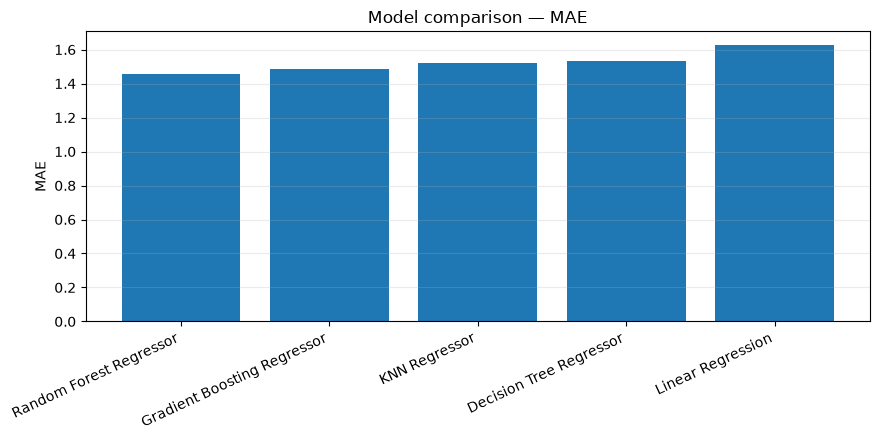

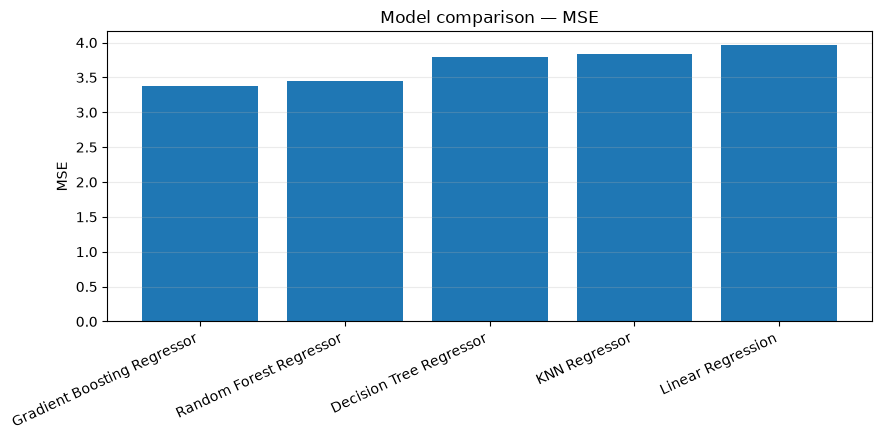

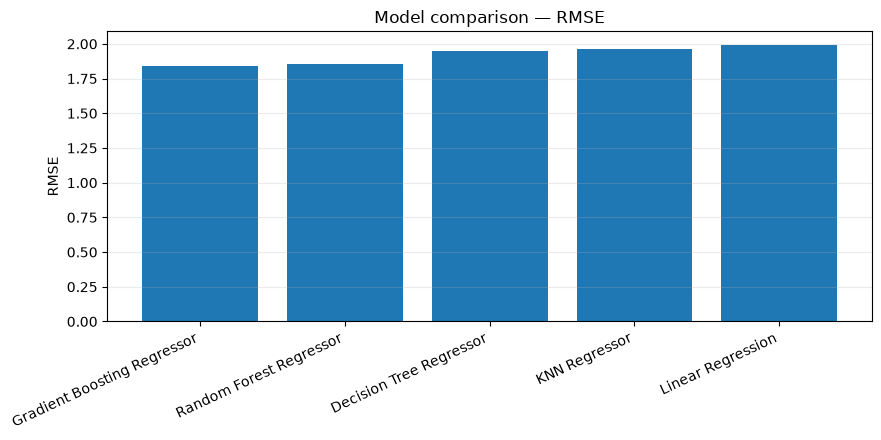

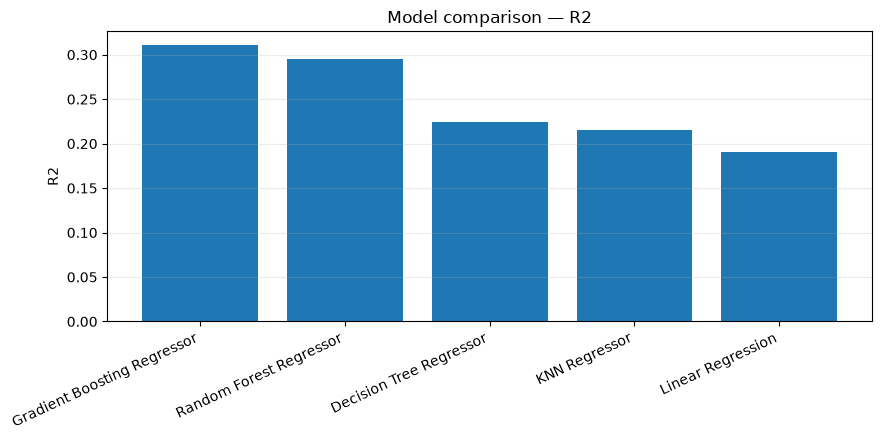

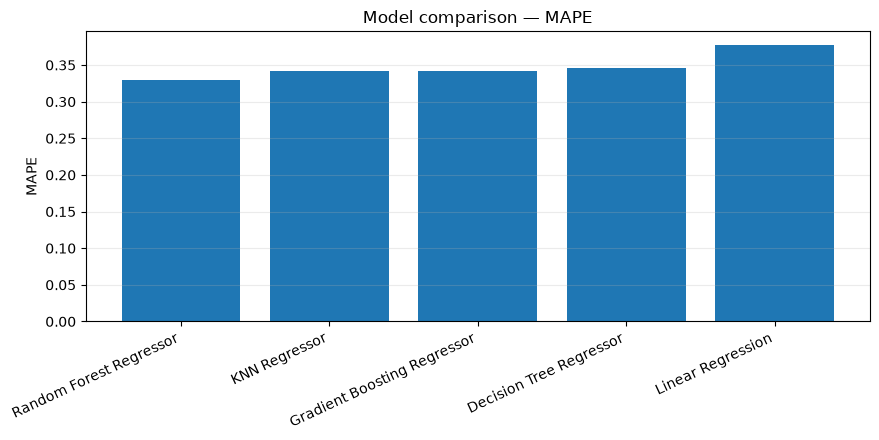

In [204]:
plot_metric_bar(house_cv_results, "MAE", False)
plot_metric_bar(house_cv_results, "MSE", False)
plot_metric_bar(house_cv_results, "RMSE", False)
plot_metric_bar(house_cv_results, "R2", True)
plot_metric_bar(house_cv_results, "MAPE", False)

### Diễn giải biểu đồ đánh giá hồi quy

Không có một model thắng tuyệt đối trên cả năm metric, nhưng **Gradient Boosting Regressor có kết quả tổng thể tốt nhất theo tiêu chí chính RMSE**. Nó đạt RMSE **1.8370**, MSE **3.3747** và R² **0.3107**, đều tốt nhất trong năm model. Random Forest đứng rất gần với RMSE **1.8583** và R² **0.2947**.

Đáng chú ý, Random Forest lại có **MAE thấp nhất 1.4589** và **MAPE thấp nhất 0.3292**, nhỉnh hơn Gradient Boosting ở hai metric này. Điều đó cho thấy hai ensemble model có chất lượng khá sát nhau nhưng tối ưu các kiểu sai số hơi khác nhau. Theo rule đã xác định trước là chọn RMSE thấp nhất, Gradient Boosting vẫn là lựa chọn cuối cùng.

Decision Tree và KNN tạo nhóm trung bình với RMSE lần lượt **1.9482** và **1.9602**, còn Linear Regression kém nhất với RMSE **1.9908**, R² chỉ **0.1905** và MAPE **0.3771**. Việc hai ensemble nonlinear đứng đầu trong khi Linear Regression đứng cuối gợi ý rằng quan hệ giữa sáu house features và `Price` không được mô tả tốt chỉ bằng một quan hệ tuyến tính đơn giản.

Tuy nhiên ngay cả model tốt nhất cũng chỉ có R² khoảng **0.31**. Nghĩa là representation hiện tại mới giải thích được một phần tương đối hạn chế biến thiên của `Price`; khoảng cách hiệu năng giữa các thuật toán nhỏ hơn khá nhiều so với phần biến thiên mà toàn bộ model vẫn chưa giải thích được.


## 16. Thí nghiệm 1 — So sánh mô hình

Thí nghiệm thứ nhất so sánh năm thuật toán dưới cùng một representation sáu đặc trưng và cùng 3-fold cross-validation. Câu hỏi nghiên cứu là: **mô hình nào đạt RMSE trung bình thấp nhất khi các điều kiện dữ liệu và quy trình đánh giá được giữ cố định?**


In [205]:
best_house_model_name = house_cv_results.iloc[0]["Model"]
best_house_cv_rmse = float(house_cv_results.iloc[0]["RMSE"])
print("Best model by mean CV RMSE:", best_house_model_name)
print("Mean CV RMSE:", round(best_house_cv_rmse, 4))

Best model by mean CV RMSE: Gradient Boosting Regressor
Mean CV RMSE: 1.837


## 17. Thí nghiệm 2 — Khảo sát hyperparameter

Thí nghiệm thứ hai khảo sát ảnh hưởng của `n_estimators` đối với Random Forest Regressor. Các giá trị 30, 60 và 100 được kiểm tra trong khi representation, imputation, random seed và cross-validation protocol được giữ nguyên. RMSE trung bình được sử dụng để đánh giá sự thay đổi hiệu năng khi số lượng cây tăng lên.


,n_estimators,Mean CV RMSE
0,30,1.8675
1,60,1.8605
2,100,1.8583


Best n_estimators: 100


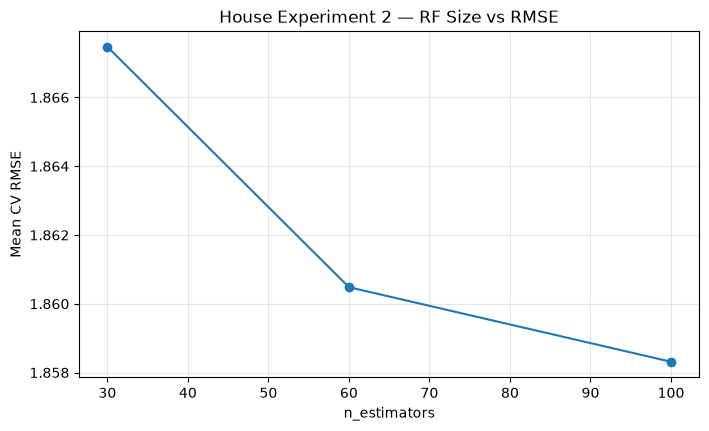

In [206]:
vals = [30, 60, 100]
scores = []
for n in vals:
    p = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=n, min_samples_leaf=2, random_state=SEED, n_jobs=1
                ),
            ),
        ]
    )
    s = cross_val_score(
        p,
        X_train_h,
        y_train_h,
        cv=house_cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=1,
    )
    scores.append(-s.mean())
rf_experiment = pd.DataFrame({"n_estimators": vals, "Mean CV RMSE": scores})
display(rf_experiment.round(4))
best_n_trees = int(
    rf_experiment.loc[rf_experiment["Mean CV RMSE"].idxmin(), "n_estimators"]
)
print("Best n_estimators:", best_n_trees)
plt.figure(figsize=(8, 4.5))
plt.plot(vals, scores, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Mean CV RMSE")
plt.title("House Experiment 2 — RF Size vs RMSE")
plt.grid(alpha=0.3)
plt.show()

### Diễn giải biểu đồ hyperparameter của Random Forest

Khi tăng số cây từ **30 → 60 → 100**, mean CV RMSE giảm lần lượt từ **1.8675 → 1.8605 → 1.8583**. Như vậy tăng `n_estimators` có cải thiện kết quả, nhưng mức cải thiện ngày càng nhỏ: bước 30→60 giảm khoảng **0.0070 RMSE**, còn bước 60→100 chỉ giảm thêm khoảng **0.0022**.

Đường biểu diễn vì vậy đang có xu hướng **phẳng dần**, cho thấy Random Forest bắt đầu đạt vùng diminishing returns: thêm nhiều cây tiếp tục giúp một chút nhưng không tạo ra thay đổi lớn về prediction error.

`n_estimators=100` là cấu hình tốt nhất trong ba giá trị đã thử, nhưng chênh lệch tổng cộng so với 30 cây chỉ khoảng **0.0092 RMSE**. Điều này cho thấy trong bài toán này, chỉ tăng kích thước forest không phải yếu tố có khả năng tạo ra bước cải thiện lớn; representation và các hyperparameter khác có thể quan trọng hơn.


## 18. Thí nghiệm 3 — Khảo sát representation / feature

Ảnh hưởng của representation được kiểm tra bằng cách so sánh:

\[
X_3=[Area,Floors,Bedrooms]
\]

với

\[
X_6=[Area,Frontage,AccessRoad,Floors,Bedrooms,Bathrooms]
\]

Cả hai representation sử dụng cùng Gradient Boosting pipeline, cùng imputation và cùng cross-validation protocol. Do thuật toán được giữ cố định, khác biệt về RMSE và R² cho thấy tác động của thông tin bổ sung trong vector sáu chiều.


,Representation,RMSE,R2
0,3 features,1.8901,0.2703
1,6 features,1.8420,0.3070


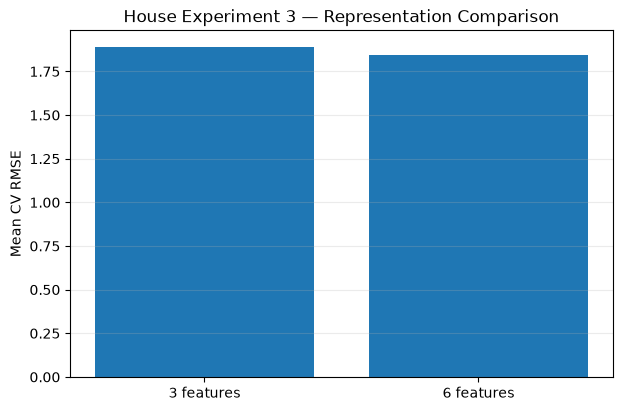

In [207]:
rep_model_h = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=100, learning_rate=0.05, max_depth=3, random_state=SEED
            ),
        ),
    ]
)
rows = []
for label, fs in {
    "3 features": ["Area", "Floors", "Bedrooms"],
    "6 features": HOUSE_FEATURES,
}.items():
    Xrep = house.loc[X_train_h.index, fs]
    s = cross_validate(
        rep_model_h,
        Xrep,
        y_train_h,
        cv=house_cv,
        scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"},
        n_jobs=1,
    )
    rows.append(
        {
            "Representation": label,
            "RMSE": -s["test_rmse"].mean(),
            "R2": s["test_r2"].mean(),
        }
    )
house_representation_results = pd.DataFrame(rows)
display(house_representation_results.round(4))
plt.figure(figsize=(7, 4.5))
plt.bar(
    house_representation_results["Representation"], house_representation_results["RMSE"]
)
plt.ylabel("Mean CV RMSE")
plt.title("House Experiment 3 — Representation Comparison")
plt.grid(axis="y", alpha=0.25)
plt.show()

### Diễn giải so sánh representation

Với representation chỉ gồm `Area`, `Floors` và `Bedrooms`, Gradient Boosting đạt mean CV RMSE **1.8901** và R² **0.2703**. Khi thêm `Frontage`, `Access Road` và `Bathrooms` để tạo representation sáu chiều, RMSE giảm xuống **1.8420** và R² tăng lên **0.3070**.

Như vậy sáu features tạo cải thiện **nhất quán ở cả hai hướng**: error giảm khoảng **0.0481 RMSE**, đồng thời phần biến thiên target được giải thích tăng khoảng **0.0367 R²**. Đây là mức cải thiện rõ hơn so với experiment representation của Diabetes, dù vẫn chưa phải một bước nhảy lớn.

Kết quả cũng phù hợp với EDA: trong ba feature được thêm, `Bathrooms` có correlation với `Price` khoảng **0.43**, cao nhất trong toàn bộ sáu input features, còn `Access Road` cũng đóng góp một signal nhỏ khoảng **0.16**. Vì vậy việc bỏ các feature này làm representation ba chiều mất một phần thông tin dự đoán hữu ích.

Dù representation sáu chiều tốt hơn, R² vẫn chỉ khoảng **0.31**, cho thấy sáu thuộc tính hiện tại vẫn chưa mô tả đầy đủ các yếu tố quyết định giá nhà.


## 19. Mô hình cuối cùng

Mô hình cuối cùng được chọn theo RMSE trung bình thấp nhất trên cross-validation của tập huấn luyện. Pipeline tương ứng được huấn luyện lại trên toàn bộ tập huấn luyện và đánh giá duy nhất trên tập kiểm thử độc lập bằng MAE, MSE, RMSE, R² và MAPE. Hai trực quan hóa `Actual vs Predicted` và residual plot được sử dụng để phân tích thêm chất lượng dự đoán và cấu trúc sai số.


In [208]:
final_house_model = clone(house_models[best_house_model_name])
final_house_model.fit(X_train_h, y_train_h)
y_pred_h = final_house_model.predict(X_test_h)
final_house_metrics = regression_metrics(y_test_h, y_pred_h)
print("Final house model:", best_house_model_name)
display(pd.DataFrame([final_house_metrics], index=["Held-out test"]).round(4))

Final house model: Gradient Boosting Regressor


,MAE,MSE,RMSE,R2,MAPE
Held-out test,1.5023,3.4569,1.8593,0.2910,0.3478


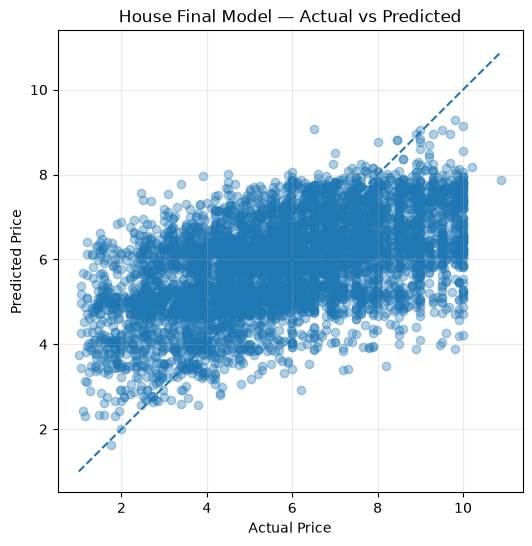

In [209]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_h, y_pred_h, alpha=0.35)
lo = min(float(y_test_h.min()), float(y_pred_h.min()))
hi = max(float(y_test_h.max()), float(y_pred_h.max()))
plt.plot([lo, hi], [lo, hi], linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("House Final Model — Actual vs Predicted")
plt.grid(alpha=0.25)
plt.show()

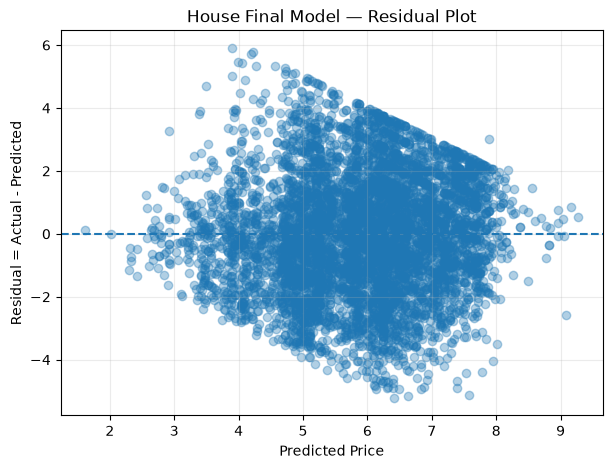

In [210]:
residuals = y_test_h.to_numpy() - y_pred_h
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_h, residuals, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual = Actual - Predicted")
plt.title("House Final Model — Residual Plot")
plt.grid(alpha=0.25)
plt.show()

### Diễn giải biểu đồ hồi quy cuối cùng

**Actual vs Predicted.**  
Các điểm có xu hướng tăng theo đường chéo, cho thấy Gradient Boosting đã học được một phần quan hệ giữa sáu thuộc tính đầu vào và `Price`. Tuy nhiên prediction bị **co mạnh về vùng trung tâm**: trong khi Actual Price trải khoảng từ gần 1 tới trên 10, phần lớn Predicted Price chỉ nằm khoảng **3–8**.

Ở các căn có Actual Price thấp, đặc biệt vùng khoảng **1–3**, rất nhiều điểm nằm phía trên đường `y=x`, nghĩa là model thường **dự đoán cao hơn giá thực tế**. Ngược lại, ở vùng Actual Price cao khoảng **8–10+**, phần lớn điểm nằm phía dưới đường lý tưởng, cho thấy model thường **dự đoán thấp hơn giá thực tế**. Model vì vậy bám dữ liệu tốt hơn ở vùng giá trung bình nhưng gặp khó khăn ở hai đầu của phân bố.

Pattern này phù hợp với held-out R² chỉ **0.2910** và RMSE **1.8593**: model có predictive signal nhưng chưa tái tạo được đầy đủ độ biến thiên của giá.

**Residual Plot.**  
Residual không tạo thành một đám mây ngẫu nhiên có độ rộng gần như đồng đều quanh đường 0. Các điểm tạo thành một vùng có cấu trúc khá rõ, với residual trải xấp xỉ từ **-5 đến +6**. Ở nhiều prediction cao khoảng **7–8**, residual nằm về phía âm khá nhiều, tương ứng với các trường hợp model dự đoán cao hơn thực tế. Trong khi đó ở vùng prediction trung bình khoảng **4–6**, vẫn xuất hiện nhiều residual dương lớn, tức có những căn nhà mà model đánh giá thấp đáng kể.

Hai biểu đồ kể cùng một câu chuyện: model có xu hướng **kéo prediction về mức giá trung bình**, làm sai số có pattern thay vì hoàn toàn ngẫu nhiên. Điều này cho thấy giới hạn không chỉ nằm ở việc chọn regressor mà còn ở representation: sáu thuộc tính `Area`, `Frontage`, `Access Road`, `Floors`, `Bedrooms` và `Bathrooms` chưa đủ để phân biệt tốt các căn nhà có giá cực thấp hoặc cực cao. Các yếu tố chưa có trong representation, chẳng hạn vị trí hoặc những đặc điểm khác của bất động sản, có thể là nguồn thông tin còn thiếu; đây là một suy luận từ pattern của residual chứ không phải kết luận nhân quả trực tiếp từ biểu đồ.


In [211]:
HOUSE_MODEL_PATH = ARTIFACT_DIR / "house_pipeline.joblib"
HOUSE_MODELS_DIR = ARTIFACT_DIR / "house_models"
HOUSE_MODELS_DIR.mkdir(exist_ok=True)

HOUSE_MODEL_SLUGS = {
    "Linear Regression": "linear_regression",
    "KNN Regressor": "knn_regressor",
    "Decision Tree Regressor": "decision_tree_regressor",
    "Random Forest Regressor": "random_forest_regressor",
    "Gradient Boosting Regressor": "gradient_boosting_regressor",
}

# Lưu artifact hiện có như recommended/final model.
joblib.dump(final_house_model, HOUSE_MODEL_PATH)

# Fit một deployable pipeline cho từng thuật toán đã đánh giá.
# Recommended model dùng lại final_house_model để artifact
# khớp đúng trained pipeline dùng cho held-out test evaluation.
house_deployment_models = {}
for model_name, model_template in house_models.items():
    if model_name == best_house_model_name:
        fitted_model = final_house_model
    else:
        fitted_model = clone(model_template)
        fitted_model.fit(X_train_h, y_train_h)

    model_id = HOUSE_MODEL_SLUGS[model_name]
    model_path = HOUSE_MODELS_DIR / f"{model_id}.joblib"
    joblib.dump(fitted_model, model_path)

    house_deployment_models[model_id] = {
        "name": model_name,
        "artifact": str(Path("house_models") / f"{model_id}.joblib"),
        "recommended": model_name == best_house_model_name,
    }

recommended_house_model_id = HOUSE_MODEL_SLUGS[best_house_model_name]

meta = {
    "task": "regression",
    "features": HOUSE_FEATURES,
    "target": HOUSE_TARGET,
    "selected_model": best_house_model_name,
    "recommended_model_id": recommended_house_model_id,
    "selection_metric": "mean_cv_rmse",
    "available_models": house_deployment_models,
    "test_metrics": {k: float(v) for k, v in final_house_metrics.items()},
    "price_unit_note": "Prediction is in the same unit as dataset Price.",
}
(ARTIFACT_DIR / "house_metadata.json").write_text(
    json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8"
)

print("Saved recommended house model:", HOUSE_MODEL_PATH)
print("Saved selectable house models:")
for model_id, info in house_deployment_models.items():
    marker = " <- recommended" if info["recommended"] else ""
    print(f"  {model_id}: {info['artifact']}{marker}")

Saved recommended house model: artifacts\house_pipeline.joblib
Saved selectable house models:
  linear_regression: house_models\linear_regression.joblib
  knn_regressor: house_models\knn_regressor.joblib
  decision_tree_regressor: house_models\decision_tree_regressor.joblib
  random_forest_regressor: house_models\random_forest_regressor.joblib
  gradient_boosting_regressor: house_models\gradient_boosting_regressor.joblib <- recommended


## 20. Knowledge Graph — House Price

Knowledge Graph của miền bất động sản biểu diễn các thực thể `House`, `Feature`, `Prediction`, `MLModel` và `TargetConcept`. Các cạnh mô tả quan hệ giữa căn nhà với thuộc tính, giữa căn nhà với prediction và giữa prediction với model/price concept.

Khác với feature vector dùng cho regression, graph representation làm rõ quan hệ ngữ nghĩa giữa các thực thể. Script Cypher được sinh ra để đồ thị có thể được lưu và truy vấn trong Neo4j.


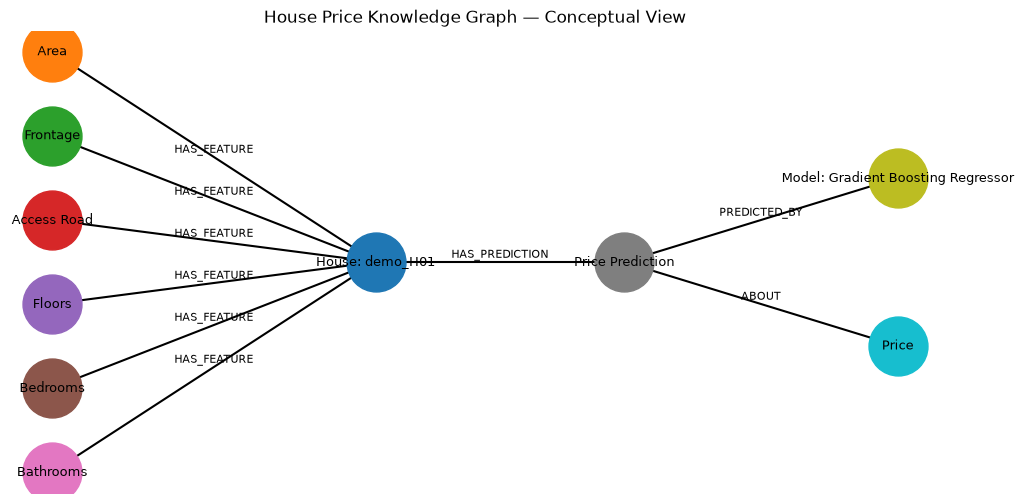

In [212]:
nodes = {
    "house": "House: demo_H01",
    "area": "Area",
    "frontage": "Frontage",
    "road": "Access Road",
    "floors": "Floors",
    "bedrooms": "Bedrooms",
    "bathrooms": "Bathrooms",
    "pred": "Price Prediction",
    "model": f"Model: {best_house_model_name}",
    "target": "Price",
}
edges = [
    ("house", "HAS_FEATURE", "area"),
    ("house", "HAS_FEATURE", "frontage"),
    ("house", "HAS_FEATURE", "road"),
    ("house", "HAS_FEATURE", "floors"),
    ("house", "HAS_FEATURE", "bedrooms"),
    ("house", "HAS_FEATURE", "bathrooms"),
    ("house", "HAS_PREDICTION", "pred"),
    ("pred", "PREDICTED_BY", "model"),
    ("pred", "ABOUT", "target"),
]
pos = {
    "house": (0, 0),
    "area": (-2.6, 2.5),
    "frontage": (-2.6, 1.5),
    "road": (-2.6, 0.5),
    "floors": (-2.6, -0.5),
    "bedrooms": (-2.6, -1.5),
    "bathrooms": (-2.6, -2.5),
    "pred": (2, 0),
    "model": (4.2, 1),
    "target": (4.2, -1),
}
draw_simple_kg(nodes, edges, pos, "House Price Knowledge Graph — Conceptual View")

## 21. Tầng ứng dụng

Ứng dụng dự đoán giá nhà sử dụng sáu trường `Area`, `Frontage`, `Access Road`, `Floors`, `Bedrooms` và `Bathrooms`. Cả ứng dụng Web và ứng dụng Android Mobile gửi sáu giá trị này tới cùng Flask REST API, đồng thời người dùng có thể chọn một trong năm regressors đã được đánh giá trong notebook.

Backend chuyển dữ liệu thành một `DataFrame` có schema và thứ tự cột trùng với training representation rồi truyền qua trained pipeline tương ứng với model được chọn. Notebook vẫn lưu `house_pipeline.joblib` như artifact của final/recommended model, đồng thời lưu thêm năm selectable pipelines trong `artifacts/house_models/`. Vì preprocessing và estimator được lưu chung trong từng pipeline, bước inference trên Web và Mobile sử dụng đúng logic đã được sử dụng khi huấn luyện.

API trả về giá dự đoán của model được chọn theo đơn vị **tỷ VND**, nhất quán với cột `Price` của dataset.


## 22. Minh họa hệ thống

Ba trường hợp nhà với quy mô và đặc điểm khác nhau được đưa qua toàn bộ hệ thống:

`Input → Feature Representation → Preprocessing → Regression Model → Predicted Price`

Các kết quả minh họa khả năng áp dụng mô hình cho các observation mới có cùng representation.


In [213]:
house_demo_cases = pd.DataFrame(
    [
        {
            "Area": 40,
            "Frontage": 4.0,
            "Access Road": 3.0,
            "Floors": 2,
            "Bedrooms": 2,
            "Bathrooms": 2,
        },
        {
            "Area": 70,
            "Frontage": 5.0,
            "Access Road": 6.0,
            "Floors": 4,
            "Bedrooms": 4,
            "Bathrooms": 3,
        },
        {
            "Area": 120,
            "Frontage": 7.0,
            "Access Road": 12.0,
            "Floors": 5,
            "Bedrooms": 5,
            "Bathrooms": 5,
        },
    ]
)[HOUSE_FEATURES]
r = house_demo_cases.copy()
r["Predicted Price (billion VND)"] = final_house_model.predict(house_demo_cases)
display(r.round(4))

,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,Predicted Price (billion VND)
0,40,4.0000,3.0000,2,2,2,3.3735
1,70,5.0000,6.0000,4,4,3,7.0186
2,120,7.0000,12.0000,5,5,5,8.1966


## 23. Nhận xét — House Price

Hệ thống nhận sáu thuộc tính số của một căn nhà và biểu diễn chúng bằng vector sáu chiều. Mô hình học từ các cặp `(x, Price)` trong dữ liệu huấn luyện để xấp xỉ quan hệ giữa representation này và giá nhà, sau đó áp dụng hàm đã học cho observation chưa từng xuất hiện. Khả năng học quan hệ từ nhiều ví dụ và tổng quát hóa sang input mới là thành phần “intelligent” trong phạm vi bài toán.

Representation hiện tại có ưu điểm là đơn giản và thuận lợi cho triển khai, nhưng chỉ bảo toàn một phần thông tin của thị trường bất động sản. Những yếu tố như vị trí, khu vực, tình trạng pháp lý, nội thất, hướng nhà và biến động theo thời gian không được mô hình chính sử dụng. Cùng bài toán có thể được biểu diễn bằng graph, sequence, image hoặc learned embedding nếu có thêm dữ liệu tương ứng.

Nếu representation thay đổi, hệ thống có thể bảo toàn thêm các thông tin như vị trí, quan hệ không gian hoặc diễn biến theo thời gian, nhưng đồng thời sẽ cần preprocessing và learning method khác phù hợp với representation mới.

Xét trong lịch sử phát triển AI, hệ thống thuộc giai đoạn:

`Structured Data → Human-designed Features → Traditional ML Regression → Prediction`.


## 24. Kết luận — House Price

Nghiên cứu tình huống B đã xây dựng một hệ thống hồi quy hoàn chỉnh từ dữ liệu bất động sản thực đến ứng dụng dự đoán. Năm mô hình được so sánh bằng năm độ đo, ba thí nghiệm có kiểm soát được sử dụng để phân tích thuật toán, hyperparameter và representation, còn final model được đánh giá trên tập kiểm thử độc lập. Các biểu đồ Actual-vs-Predicted và residual hỗ trợ phân tích sai số. Mô hình cuối cùng được lưu dưới dạng pipeline và được sử dụng chung bởi ứng dụng Web và ứng dụng Android Mobile thông qua Flask REST API; representation dạng vector đồng thời được bổ sung bằng Knowledge Graph tương thích Neo4j.


# PHẦN C - HÀNH VI KHÁCH HÀNG THƯƠNG MẠI ĐIỆN TỬ / INTEREST DISCOVERY

## 1. Định nghĩa hệ thống và bài toán

Hệ thống thông minh thứ ba sử dụng năm bảng dữ liệu thương mại điện tử: `customers`, `transactions`, `sessions`, `products` và `reviews`. Biến mục tiêu được chọn là `is_churned`, nghĩa là hệ thống dự đoán một khách hàng có khả năng rời bỏ hay không.

Target này phù hợp vì đây là nhãn phân loại nhị phân ở cấp customer. Phần interest discovery vẫn được thể hiện thông qua category sản phẩm được mua nhiều nhất, brand được mua nhiều nhất, hành vi duyệt web và review text.

Ký hiệu bài toán:

`X = customer profile features + behavioral aggregates + categorical features + text representation`

`y = is_churned in {0, 1}`


## 2. Sơ đồ hệ thống thông minh

```text
Customer / E-commerce platform
        |
        v
Raw relational CSV tables
        |
        v
Customer-level feature engineering
        |
        +-- numerical: age, recency, frequency, spending, sessions, ratings
        +-- categorical: country, segment, device, channel, category, brand
        +-- text: review comments -> tokens / TF-IDF
        |
        v
Preprocessing pipeline
        |
        v
Classification model
        |
        v
Churn prediction and interest interpretation
```

Sơ đồ cho thấy dữ liệu ban đầu ở nhiều bảng CSV được gom về một representation ở cấp khách hàng. Sau đó pipeline thực hiện imputation, scaling, one-hot encoding và TF-IDF trước khi đưa dữ liệu vào classification model.


## 3. Nguồn dữ liệu

Bộ dữ liệu sử dụng: **Synthetic E-Commerce Customer Behavior Dataset**

Kaggle URL: `https://www.kaggle.com/datasets/lorenzoscaturchio/ecommerce-behavior`

Các file local được lấy từ thư mục `datasets/customer_behavior`:

- `customers.csv`
- `products.csv`
- `transactions.csv`
- `sessions.csv`
- `reviews.csv`


In [214]:
CUSTOMERS_PATH = resolve_data_file("customers.csv")
PRODUCTS_PATH = resolve_data_file("products.csv")
TRANSACTIONS_PATH = resolve_data_file("transactions.csv")
SESSIONS_PATH = resolve_data_file("sessions.csv")
REVIEWS_PATH = resolve_data_file("reviews.csv")

customers_raw = pd.read_csv(CUSTOMERS_PATH, parse_dates=["signup_date"])
products_raw = pd.read_csv(PRODUCTS_PATH)
transactions_raw = pd.read_csv(TRANSACTIONS_PATH, parse_dates=["transaction_date"])
sessions_raw = pd.read_csv(SESSIONS_PATH, parse_dates=["session_date"])
reviews_raw = pd.read_csv(REVIEWS_PATH, parse_dates=["review_date"])

print("Customers:", customers_raw.shape, CUSTOMERS_PATH)
print("Products:", products_raw.shape, PRODUCTS_PATH)
print("Transactions:", transactions_raw.shape, TRANSACTIONS_PATH)
print("Sessions:", sessions_raw.shape, SESSIONS_PATH)
print("Reviews:", reviews_raw.shape, REVIEWS_PATH)

display(customers_raw.head())
display(transactions_raw.head())
display(sessions_raw.head())
display(reviews_raw.head())

Customers: (10000, 10) C:\DATA\assign\datasets\customer_behavior\customers.csv
Products: (1000, 11) C:\DATA\assign\datasets\customer_behavior\products.csv
Transactions: (120000, 11) C:\DATA\assign\datasets\customer_behavior\transactions.csv
Sessions: (80000, 10) C:\DATA\assign\datasets\customer_behavior\sessions.csv
Reviews: (25000, 8) C:\DATA\assign\datasets\customer_behavior\reviews.csv


,customer_id,signup_date,age,gender,country,segment,is_churned,lifetime_value,email_opt_in,has_app
0,C00000,2020-02-13,28,M,BR,Premium,0,"1,595.2700",0,0
1,C00001,2021-10-01,22,Prefer not to say,FR,Regular,0,"1,160.6100",1,0
2,C00002,2022-06-26,30,F,US,VIP,0,"3,093.3200",1,1
3,C00003,2021-12-21,48,F,US,Premium,1,"2,131.0800",1,0
4,C00004,2021-09-16,37,M,CA,Budget Shopper,0,583.3900,0,1


,transaction_id,customer_id,product_id,transaction_date,quantity,unit_price,total_amount,discount_applied,status,payment_method,shipping_cost
0,T077767,C08119,P0932,2023-01-01 00:23:39,1,23.8700,23.8700,0,refunded,paypal,8.1500
1,T021376,C08883,P0889,2023-01-01 00:26:51,1,31.5300,31.5300,50,refunded,credit_card,6.1300
2,T117783,C05855,P0065,2023-01-01 00:45:53,1,67.7500,67.7500,0,completed,apple_pay,0.0000
3,T035185,C09437,P0200,2023-01-01 01:04:28,1,151.0600,151.0600,5,cancelled,apple_pay,0.0000
4,T092643,C00760,P0881,2023-01-01 01:06:45,1,11.9700,11.9700,50,completed,paypal,5.3100


,session_id,customer_id,session_date,device,channel,duration_seconds,pages_viewed,converted,bounced,cart_additions
0,S049064,C03202,2023-01-01 00:24:50,desktop,direct,72,1,1,0,5
1,S015939,C09526,2023-01-01 00:42:04,mobile,organic,36,1,0,0,1
2,S003166,C07034,2023-01-01 00:55:56,desktop,social,284,5,0,0,0
3,S039733,C05327,2023-01-01 01:33:58,mobile,direct,805,10,0,0,1
4,S045293,C05338,2023-01-01 01:35:22,tablet,direct,207,3,0,0,0


,review_id,customer_id,product_id,review_date,rating,review_text,helpful_votes,verified_purchase
0,R22520,C06622,P0077,2023-01-01,4,Great product! Highly recommend.,0,0
1,R11296,C01152,P0726,2023-01-01,5,Love it! Exactly what I needed.,3,1
2,R15342,C05432,P0167,2023-01-01,3,"Average quality, meets expectations.",42,1
3,R06757,C00693,P0443,2023-01-01,3,"Not bad, not great.",43,1
4,R08506,C05569,P0972,2023-01-01,4,Amazing value for the price.,46,1


# PART C - E-commerce customer behavior and interest discovery

## 1. Định nghĩa hệ thống và bài toán

Hệ thống thông minh thứ ba sử dụng năm bảng dữ liệu thương mại điện tử: `customers`, `transactions`, `sessions`, `products` và `reviews`. Biến mục tiêu được chọn là `is_churned`, nghĩa là hệ thống dự đoán một khách hàng có khả năng rời bỏ hay không.

Target này phù hợp vì đây là nhãn phân loại nhị phân ở cấp customer. Phần interest discovery vẫn được thể hiện thông qua category sản phẩm được mua nhiều nhất, brand được mua nhiều nhất, hành vi duyệt web và review text.

Ký hiệu bài toán:

`X = customer profile features + behavioral aggregates + categorical features + text representation`

`y = is_churned in {0, 1}`


## 2. Sơ đồ hệ thống thông minh

```text
Customer / E-commerce platform
        |
        v
Raw relational CSV tables
        |
        v
Customer-level feature engineering
        |
        +-- numerical: age, recency, frequency, spending, sessions, ratings
        +-- categorical: country, segment, device, channel, category, brand
        +-- text: review comments -> tokens / TF-IDF
        |
        v
Preprocessing pipeline
        |
        v
Classification model
        |
        v
Churn prediction and interest interpretation
```

Sơ đồ cho thấy dữ liệu ban đầu ở nhiều bảng CSV được gom về một representation ở cấp khách hàng. Sau đó pipeline thực hiện imputation, scaling, one-hot encoding và TF-IDF trước khi đưa dữ liệu vào classification model.


## 3. Nguồn dữ liệu

Bộ dữ liệu sử dụng: **Synthetic E-Commerce Customer Behavior Dataset**

Kaggle URL: `https://www.kaggle.com/datasets/lorenzoscaturchio/ecommerce-behavior`

Các file local được lấy từ thư mục `datasets/customer_behavior`:

- `customers.csv`
- `products.csv`
- `transactions.csv`
- `sessions.csv`
- `reviews.csv`


In [215]:
CUSTOMERS_PATH = resolve_data_file("customers.csv")
PRODUCTS_PATH = resolve_data_file("products.csv")
TRANSACTIONS_PATH = resolve_data_file("transactions.csv")
SESSIONS_PATH = resolve_data_file("sessions.csv")
REVIEWS_PATH = resolve_data_file("reviews.csv")

customers_raw = pd.read_csv(CUSTOMERS_PATH, parse_dates=["signup_date"])
products_raw = pd.read_csv(PRODUCTS_PATH)
transactions_raw = pd.read_csv(TRANSACTIONS_PATH, parse_dates=["transaction_date"])
sessions_raw = pd.read_csv(SESSIONS_PATH, parse_dates=["session_date"])
reviews_raw = pd.read_csv(REVIEWS_PATH, parse_dates=["review_date"])

print("Customers:", customers_raw.shape, CUSTOMERS_PATH)
print("Products:", products_raw.shape, PRODUCTS_PATH)
print("Transactions:", transactions_raw.shape, TRANSACTIONS_PATH)
print("Sessions:", sessions_raw.shape, SESSIONS_PATH)
print("Reviews:", reviews_raw.shape, REVIEWS_PATH)

display(customers_raw.head())
display(transactions_raw.head())
display(sessions_raw.head())
display(reviews_raw.head())

Customers: (10000, 10) C:\DATA\assign\datasets\customer_behavior\customers.csv
Products: (1000, 11) C:\DATA\assign\datasets\customer_behavior\products.csv
Transactions: (120000, 11) C:\DATA\assign\datasets\customer_behavior\transactions.csv
Sessions: (80000, 10) C:\DATA\assign\datasets\customer_behavior\sessions.csv
Reviews: (25000, 8) C:\DATA\assign\datasets\customer_behavior\reviews.csv


,customer_id,signup_date,age,gender,country,segment,is_churned,lifetime_value,email_opt_in,has_app
0,C00000,2020-02-13,28,M,BR,Premium,0,"1,595.2700",0,0
1,C00001,2021-10-01,22,Prefer not to say,FR,Regular,0,"1,160.6100",1,0
2,C00002,2022-06-26,30,F,US,VIP,0,"3,093.3200",1,1
3,C00003,2021-12-21,48,F,US,Premium,1,"2,131.0800",1,0
4,C00004,2021-09-16,37,M,CA,Budget Shopper,0,583.3900,0,1


,transaction_id,customer_id,product_id,transaction_date,quantity,unit_price,total_amount,discount_applied,status,payment_method,shipping_cost
0,T077767,C08119,P0932,2023-01-01 00:23:39,1,23.8700,23.8700,0,refunded,paypal,8.1500
1,T021376,C08883,P0889,2023-01-01 00:26:51,1,31.5300,31.5300,50,refunded,credit_card,6.1300
2,T117783,C05855,P0065,2023-01-01 00:45:53,1,67.7500,67.7500,0,completed,apple_pay,0.0000
3,T035185,C09437,P0200,2023-01-01 01:04:28,1,151.0600,151.0600,5,cancelled,apple_pay,0.0000
4,T092643,C00760,P0881,2023-01-01 01:06:45,1,11.9700,11.9700,50,completed,paypal,5.3100


,session_id,customer_id,session_date,device,channel,duration_seconds,pages_viewed,converted,bounced,cart_additions
0,S049064,C03202,2023-01-01 00:24:50,desktop,direct,72,1,1,0,5
1,S015939,C09526,2023-01-01 00:42:04,mobile,organic,36,1,0,0,1
2,S003166,C07034,2023-01-01 00:55:56,desktop,social,284,5,0,0,0
3,S039733,C05327,2023-01-01 01:33:58,mobile,direct,805,10,0,0,1
4,S045293,C05338,2023-01-01 01:35:22,tablet,direct,207,3,0,0,0


,review_id,customer_id,product_id,review_date,rating,review_text,helpful_votes,verified_purchase
0,R22520,C06622,P0077,2023-01-01,4,Great product! Highly recommend.,0,0
1,R11296,C01152,P0726,2023-01-01,5,Love it! Exactly what I needed.,3,1
2,R15342,C05432,P0167,2023-01-01,3,"Average quality, meets expectations.",42,1
3,R06757,C00693,P0443,2023-01-01,3,"Not bad, not great.",43,1
4,R08506,C05569,P0972,2023-01-01,4,Amazing value for the price.,46,1


## 4. Mô tả và kiểm tra dữ liệu

Một observation cuối cùng của hệ thống biểu diễn **một khách hàng**. Dữ liệu thô có vấn đề khác cấp độ quan sát: target `is_churned` nằm trong `customers.csv`, còn transactions, sessions và reviews có nhiều dòng event cho mỗi customer. Vì vậy các bảng event cần được tổng hợp về cấp customer trước khi huấn luyện model.


In [216]:
customer_tables = {
    "customers": customers_raw,
    "products": products_raw,
    "transactions": transactions_raw,
    "sessions": sessions_raw,
    "reviews": reviews_raw,
}

inspection_rows = []
for table_name, df in customer_tables.items():
    inspection_rows.append(
        {
            "table": table_name,
            "rows": len(df),
            "columns": df.shape[1],
            "missing_values": int(df.isna().sum().sum()),
            "duplicate_rows": int(df.duplicated().sum()),
        }
    )

display(pd.DataFrame(inspection_rows))

for table_name, df in customer_tables.items():
    print(f"\n{table_name.upper()}")
    display(df.dtypes.to_frame("dtype").T)
    display(df.isna().sum().to_frame("missing_count").T)

,table,rows,columns,missing_values,duplicate_rows
0,customers,10000,10,0,0
1,products,1000,11,0,0
2,transactions,120000,11,0,0
3,sessions,80000,10,0,0
4,reviews,25000,8,0,0



CUSTOMERS


,customer_id,signup_date,age,gender,country,segment,is_churned,lifetime_value,email_opt_in,has_app
dtype,str,datetime64[us],int64,str,str,str,int64,float64,int64,int64


,customer_id,signup_date,age,gender,country,segment,is_churned,lifetime_value,email_opt_in,has_app
missing_count,0,0,0,0,0,0,0,0,0,0



PRODUCTS


...

,session_id,customer_id,session_date,device,channel,duration_seconds,pages_viewed,converted,bounced,cart_additions
dtype,str,str,datetime64[us],str,str,int64,int64,int64,int64,int64


,session_id,customer_id,session_date,device,channel,duration_seconds,pages_viewed,converted,bounced,cart_additions
missing_count,0,0,0,0,0,0,0,0,0,0



REVIEWS


,review_id,customer_id,product_id,review_date,rating,review_text,helpful_votes,verified_purchase
dtype,str,str,str,datetime64[us],int64,str,int64,int64


,review_id,customer_id,product_id,review_date,rating,review_text,helpful_votes,verified_purchase
missing_count,0,0,0,0,0,0,0,0


### Diễn giải chất lượng dữ liệu - E-commerce

Các bảng có thể join rõ ràng bằng `customer_id` và `product_id`. Quyết định quan trọng nhất không phải là xóa dòng dữ liệu, mà là thiết kế representation phù hợp. Sau khi join, các aggregate bị thiếu được hiểu là khách hàng không có event tương ứng; giá trị này được điền 0 cho numeric features và `Unknown` cho categorical summaries.

`lifetime_value` không được dùng làm input vì đây là biến tổng kết sau toàn bộ vòng đời khách hàng, có thể gây data leakage khi mục tiêu là dự đoán churn.


In [217]:
CUSTOMER_TARGET = "is_churned"

customer_feature_overview = pd.DataFrame(
    {
        "column": customers_raw.columns,
        "dtype": customers_raw.dtypes.astype(str).values,
        "role": [
            (
                "identifier"
                if c == "customer_id"
                else (
                    "target"
                    if c == CUSTOMER_TARGET
                    else (
                        "excluded_leakage_reference"
                        if c == "lifetime_value"
                        else "raw_customer_feature"
                    )
                )
            )
            for c in customers_raw.columns
        ],
    }
)

display(customer_feature_overview)
display(customers_raw[CUSTOMER_TARGET].value_counts().rename("count").to_frame())
print("Churn rate:", round(customers_raw[CUSTOMER_TARGET].mean(), 4))

,column,dtype,role
0,customer_id,str,identifier
1,signup_date,datetime64[us],raw_customer_feature
2,age,int64,raw_customer_feature
3,gender,str,raw_customer_feature
4,country,str,raw_customer_feature
5,segment,str,raw_customer_feature
6,is_churned,int64,target
7,lifetime_value,float64,excluded_leakage_reference
8,email_opt_in,int64,raw_customer_feature
9,has_app,int64,raw_customer_feature


,count
is_churned,
0,8306
1,1694


Churn rate: 0.1694


## 5. Làm sạch dữ liệu và tạo customer-level features

Pipeline cleaning chuyển cột ngày tháng về kiểu datetime, chuẩn hóa review text, chuyển transaction status thành các biến chỉ báo, rồi tổng hợp các bảng event thành một dòng cho mỗi customer. Các feature tổng hợp gồm recency, frequency, monetary value, conversion rate, bounce rate, rating, top category và top brand.


In [218]:
def top_value(series):
    values = series.dropna().astype(str)
    if values.empty:
        return "Unknown"
    return values.value_counts().idxmax()


customers = customers_raw.copy()
products = products_raw.copy()
transactions = transactions_raw.copy()
sessions = sessions_raw.copy()
reviews = reviews_raw.copy()

transactions["is_completed"] = (transactions["status"] == "completed").astype(int)
transactions["is_cancelled"] = (transactions["status"] == "cancelled").astype(int)
transactions["is_refunded"] = (transactions["status"] == "refunded").astype(int)
transactions["completed_amount"] = np.where(
    transactions["status"] == "completed", transactions["total_amount"], 0.0
)

max_activity_date = max(
    transactions["transaction_date"].max(), sessions["session_date"].max()
)

transactions_with_products = transactions.merge(
    products[["product_id", "category", "brand"]], on="product_id", how="left"
)

tx_agg = (
    transactions.groupby("customer_id")
    .agg(
        transaction_count=("transaction_id", "count"),
        completed_count=("is_completed", "sum"),
        cancelled_rate=("is_cancelled", "mean"),
        refunded_rate=("is_refunded", "mean"),
        total_spent=("completed_amount", "sum"),
        avg_order_value=("total_amount", "mean"),
        total_quantity=("quantity", "sum"),
        avg_discount=("discount_applied", "mean"),
        avg_shipping_cost=("shipping_cost", "mean"),
        unique_products=("product_id", "nunique"),
        last_transaction_date=("transaction_date", "max"),
        favorite_payment_method=("payment_method", top_value),
    )
    .reset_index()
)
tx_agg["transaction_recency_days"] = (
    max_activity_date - tx_agg["last_transaction_date"]
).dt.days

completed_tx = transactions_with_products[
    transactions_with_products["status"].eq("completed")
]
category_agg = (
    completed_tx.groupby("customer_id")
    .agg(
        top_category=("category", top_value),
        top_brand=("brand", top_value),
    )
    .reset_index()
)

session_agg = (
    sessions.groupby("customer_id")
    .agg(
        session_count=("session_id", "count"),
        avg_duration_seconds=("duration_seconds", "mean"),
        total_pages_viewed=("pages_viewed", "sum"),
        avg_pages_viewed=("pages_viewed", "mean"),
        conversion_rate=("converted", "mean"),
        bounce_rate=("bounced", "mean"),
        cart_additions_sum=("cart_additions", "sum"),
        avg_cart_additions=("cart_additions", "mean"),
        last_session_date=("session_date", "max"),
        most_used_device=("device", top_value),
        top_channel=("channel", top_value),
    )
    .reset_index()
)
session_agg["session_recency_days"] = (
    max_activity_date - session_agg["last_session_date"]
).dt.days

reviews["review_text_clean"] = (
    reviews["review_text"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

review_agg = (
    reviews.groupby("customer_id")
    .agg(
        review_count=("review_id", "count"),
        avg_rating=("rating", "mean"),
        low_rating_share=("rating", lambda s: (s <= 2).mean()),
        helpful_votes_total=("helpful_votes", "sum"),
        verified_review_rate=("verified_purchase", "mean"),
        review_text_clean=(
            "review_text_clean",
            lambda s: " ".join(s.dropna().astype(str).head(20)),
        ),
    )
    .reset_index()
)

customer_features = (
    customers.merge(
        tx_agg.drop(columns=["last_transaction_date"]), on="customer_id", how="left"
    )
    .merge(category_agg, on="customer_id", how="left")
    .merge(
        session_agg.drop(columns=["last_session_date"]), on="customer_id", how="left"
    )
    .merge(review_agg, on="customer_id", how="left")
)
customer_features["customer_tenure_days"] = (
    max_activity_date - customer_features["signup_date"]
).dt.days

print("Shape của customer-level representation:", customer_features.shape)
display(customer_features.head())

Shape của customer-level representation: (10000, 42)


,customer_id,signup_date,age,gender,country,segment,is_churned,lifetime_value,email_opt_in,has_app,transaction_count,completed_count,cancelled_rate,refunded_rate,total_spent,avg_order_value,total_quantity,avg_discount,avg_shipping_cost,unique_products,favorite_payment_method,transaction_recency_days,top_category,top_brand,session_count,avg_duration_seconds,total_pages_viewed,avg_pages_viewed,conversion_rate,bounce_rate,cart_additions_sum,avg_cart_additions,most_used_device,top_channel,session_recency_days,review_count,avg_rating,low_rating_share,helpful_votes_total,verified_review_rate,review_text_clean,customer_tenure_days
0,C00000,2020-02-13,28,M,BR,Premium,0,"1,595.2700",0,0,25.0000,18.0000,0.0800,0.1200,706.6500,38.8240,32.0000,4.6000,5.7632,25.0000,credit_card,4.0000,Music,NovaTech,8.0000,696.8750,86.0000,10.7500,0.1250,0.1250,5.0000,0.6250,mobile,social,131.0000,NaN,NaN,NaN,NaN,NaN,NaN,1782
1,C00001,2021-10-01,22,Prefer not to say,FR,Regular,0,"1,160.6100",1,0,12.0000,5.0000,0.2500,0.0000,244.6400,65.5133,22.0000,8.3333,3.5275,12.0000,credit_card,7.0000,Books,EcoLiving,12.0000,325.5000,82.0000,6.8333,0.0000,0.0833,4.0000,0.3333,mobile,paid_search,70.0000,1.0000,2.0000,1.0000,41.0000,1.0000,would not recommend. poor value.,1186
2,C00002,2022-06-26,30,F,US,VIP,0,"3,093.3200",1,1,29.0000,16.0000,0.1379,0.1034,"1,104.6600",72.8445,39.0000,6.7241,4.5217,29.0000,credit_card,5.0000,Sports,NovaTech,29.0000,439.8966,217.0000,7.4828,0.1034,0.0690,31.0000,1.0690,mobile,paid_search,0.0000,2.0000,2.5000,0.5000,42.0000,0.5000,decent product for the price. would not recomm...,918
3,C00003,2021-12-21,48,F,US,Premium,1,"2,131.0800",1,0,26.0000,15.0000,0.0769,0.2308,695.0600,51.5792,40.0000,8.0769,4.5415,26.0000,credit_card,0.0000,Pet Supplies,WorkSmart,17.0000,284.5882,88.0000,5.1765,0.1176,0.1765,20.0000,1.1765,mobile,paid_search,10.0000,1.0000,4.0000,0.0000,25.0000,1.0000,love it! exactly what i needed.,1105
4,C00004,2021-09-16,37,M,CA,Budget Shopper,0,583.3900,0,1,4.0000,2.0000,0.0000,0.0000,148.3200,46.1350,4.0000,6.2500,4.8275,4.0000,credit_card,257.0000,Food & Grocery,EcoLiving,1.0000,216.0000,5.0000,5.0000,0.0000,0.0000,0.0000,0.0000,mobile,social,86.0000,1.0000,2.0000,1.0000,15.0000,1.0000,broke after a week of use.,1201


In [219]:
CUSTOMER_NUMERIC_FEATURES = [
    "age",
    "email_opt_in",
    "has_app",
    "customer_tenure_days",
    "transaction_count",
    "completed_count",
    "cancelled_rate",
    "refunded_rate",
    "total_spent",
    "avg_order_value",
    "total_quantity",
    "avg_discount",
    "avg_shipping_cost",
    "unique_products",
    "transaction_recency_days",
    "session_count",
    "avg_duration_seconds",
    "total_pages_viewed",
    "avg_pages_viewed",
    "conversion_rate",
    "bounce_rate",
    "cart_additions_sum",
    "avg_cart_additions",
    "session_recency_days",
    "review_count",
    "avg_rating",
    "low_rating_share",
    "helpful_votes_total",
    "verified_review_rate",
]

CUSTOMER_CATEGORICAL_FEATURES = [
    "gender",
    "country",
    "segment",
    "favorite_payment_method",
    "top_category",
    "top_brand",
    "most_used_device",
    "top_channel",
]

CUSTOMER_TEXT_FEATURE = "review_text_clean"
CUSTOMER_FEATURES = (
    CUSTOMER_NUMERIC_FEATURES + CUSTOMER_CATEGORICAL_FEATURES + [CUSTOMER_TEXT_FEATURE]
)

for col in CUSTOMER_NUMERIC_FEATURES:
    customer_features[col] = pd.to_numeric(
        customer_features[col], errors="coerce"
    ).fillna(0)

for col in CUSTOMER_CATEGORICAL_FEATURES:
    customer_features[col] = customer_features[col].fillna("Unknown").astype(str)

customer_features[CUSTOMER_TEXT_FEATURE] = customer_features[
    CUSTOMER_TEXT_FEATURE
].fillna("no review")
customer_model_df = customer_features[CUSTOMER_FEATURES + [CUSTOMER_TARGET]].copy()

print("Shape của model dataframe:", customer_model_df.shape)
display(
    customer_model_df[CUSTOMER_TARGET]
    .value_counts(normalize=True)
    .rename("ratio")
    .to_frame()
)
display(customer_model_df[CUSTOMER_FEATURES].head())

Shape của model dataframe: (10000, 39)


,ratio
is_churned,
0,0.8306
1,0.1694


,age,email_opt_in,has_app,customer_tenure_days,transaction_count,completed_count,cancelled_rate,refunded_rate,total_spent,avg_order_value,total_quantity,avg_discount,avg_shipping_cost,unique_products,transaction_recency_days,session_count,avg_duration_seconds,total_pages_viewed,avg_pages_viewed,conversion_rate,bounce_rate,cart_additions_sum,avg_cart_additions,session_recency_days,review_count,avg_rating,low_rating_share,helpful_votes_total,verified_review_rate,gender,country,segment,favorite_payment_method,top_category,top_brand,most_used_device,top_channel,review_text_clean
0,28,0,0,1782,25.0000,18.0000,0.0800,0.1200,706.6500,38.8240,32.0000,4.6000,5.7632,25.0000,4.0000,8.0000,696.8750,86.0000,10.7500,0.1250,0.1250,5.0000,0.6250,131.0000,0.0000,0.0000,0.0000,0.0000,0.0000,M,BR,Premium,credit_card,Music,NovaTech,mobile,social,no review
1,22,1,0,1186,12.0000,5.0000,0.2500,0.0000,244.6400,65.5133,22.0000,8.3333,3.5275,12.0000,7.0000,12.0000,325.5000,82.0000,6.8333,0.0000,0.0833,4.0000,0.3333,70.0000,1.0000,2.0000,1.0000,41.0000,1.0000,Prefer not to say,FR,Regular,credit_card,Books,EcoLiving,mobile,paid_search,would not recommend. poor value.
2,30,1,1,918,29.0000,16.0000,0.1379,0.1034,"1,104.6600",72.8445,39.0000,6.7241,4.5217,29.0000,5.0000,29.0000,439.8966,217.0000,7.4828,0.1034,0.0690,31.0000,1.0690,0.0000,2.0000,2.5000,0.5000,42.0000,0.5000,F,US,VIP,credit_card,Sports,NovaTech,mobile,paid_search,decent product for the price. would not recomm...
3,48,1,0,1105,26.0000,15.0000,0.0769,0.2308,695.0600,51.5792,40.0000,8.0769,4.5415,26.0000,0.0000,17.0000,284.5882,88.0000,5.1765,0.1176,0.1765,20.0000,1.1765,10.0000,1.0000,4.0000,0.0000,25.0000,1.0000,F,US,Premium,credit_card,Pet Supplies,WorkSmart,mobile,paid_search,love it! exactly what i needed.
4,37,0,1,1201,4.0000,2.0000,0.0000,0.0000,148.3200,46.1350,4.0000,6.2500,4.8275,4.0000,257.0000,1.0000,216.0000,5.0000,5.0000,0.0000,0.0000,0.0000,0.0000,86.0000,1.0000,2.0000,1.0000,15.0000,1.0000,M,CA,Budget Shopper,credit_card,Food & Grocery,EcoLiving,mobile,social,broke after a week of use.


## 6. Biểu diễn dữ liệu

Với hệ thống e-commerce, observation cuối cùng là một vector ở cấp customer:

`x_i = [profile, transaction aggregates, session aggregates, review aggregates, categorical summaries, text]`

Trước preprocessing, dataframe đầu vào có shape `N x d_raw`, trong đó `N` là số khách hàng và `d_raw` là số cột input đã được feature engineering. Sau preprocessing, numeric features được impute/scale, categorical features được one-hot encode, còn text được chuyển thành TF-IDF vectors cho model có dùng text.


In [220]:
X_customer = customer_model_df[CUSTOMER_FEATURES].copy()
y_customer = customer_model_df[CUSTOMER_TARGET].astype(int).copy()

print("Shape của raw customer feature matrix:", X_customer.shape)
print("Số raw features:", len(CUSTOMER_FEATURES))
print("Số numeric features:", len(CUSTOMER_NUMERIC_FEATURES))
print("Số categorical features:", len(CUSTOMER_CATEGORICAL_FEATURES))
print("Text feature:", CUSTOMER_TEXT_FEATURE)
print("Shape của target vector:", y_customer.shape)
display(X_customer.dtypes.value_counts().rename("count").to_frame())

Shape của raw customer feature matrix: (10000, 38)
Số raw features: 38
Số numeric features: 29
Số categorical features: 8
Text feature: review_text_clean
Shape của target vector: (10000,)


,count
float64,25
str,9
int64,4


In [221]:
sample_customer = customer_model_df.iloc[0]
feature_vector_preview = sample_customer[
    CUSTOMER_NUMERIC_FEATURES[:8] + CUSTOMER_CATEGORICAL_FEATURES[:4]
].to_frame("value")
print("Một raw customer observation được chuyển thành ordered feature vector.")
display(feature_vector_preview)

Một raw customer observation được chuyển thành ordered feature vector.


,value
age,28
email_opt_in,0
has_app,0
customer_tenure_days,1782
transaction_count,25.0000
completed_count,18.0000
cancelled_rate,0.0800
refunded_rate,0.1200
gender,M
country,BR


In [222]:
def simple_tokenize(text):
    return re.findall(r"[a-zA-Z']+", str(text).lower())


sample_comments = reviews["review_text_clean"].dropna().head(5).tolist()
tokenized_comments = [simple_tokenize(text) for text in sample_comments]

vocab_counter = Counter(token for tokens in tokenized_comments for token in tokens)
vocab = {token: idx + 1 for idx, (token, _) in enumerate(vocab_counter.most_common())}
token_id_sequences = [
    [vocab[token] for token in tokens] for tokens in tokenized_comments
]

B = len(token_id_sequences)
T = 12
EMBEDDING_DIM = 8

token_id_matrix = np.zeros((B, T), dtype=np.int64)
for row_idx, token_ids in enumerate(token_id_sequences):
    trimmed = token_ids[:T]
    token_id_matrix[row_idx, : len(trimmed)] = trimmed

rng = np.random.default_rng(SEED)
embedding_table = rng.normal(0, 0.1, size=(len(vocab) + 1, EMBEDDING_DIM)).astype(
    np.float32
)
embedding_tensor = embedding_table[token_id_matrix]

display(
    pd.DataFrame(
        {
            "raw_comment": sample_comments,
            "tokens": tokenized_comments,
            "token_ids": token_id_sequences,
        }
    )
)
print("Shape của token ID matrix B x T:", token_id_matrix.shape)
print("Shape của embedding tensor B x T x d:", embedding_tensor.shape)
print("B =", B, "comments")
print("T =", T, "tokens cho mỗi comment sau padding/truncation")
print("d =", EMBEDDING_DIM, "chiều embedding")

,raw_comment,tokens,token_ids
0,great product! highly recommend.,"[great, product, highly, recommend]","[1, 3, 4, 5]"
1,love it! exactly what i needed.,"[love, it, exactly, what, i, needed]","[6, 7, 8, 9, 10, 11]"
2,"average quality, meets expectations.","[average, quality, meets, expectations]","[12, 13, 14, 15]"
3,"not bad, not great.","[not, bad, not, great]","[2, 16, 2, 1]"
4,amazing value for the price.,"[amazing, value, for, the, price]","[17, 18, 19, 20, 21]"


Shape của token ID matrix B x T: (5, 12)
Shape của embedding tensor B x T x d: (5, 12, 8)
B = 5 comments
T = 12 tokens cho mỗi comment sau padding/truncation
d = 8 chiều embedding


### Diễn giải representation - E-commerce

`B` là batch size, `T` là độ dài chuỗi token, và `d` là số chiều embedding. One-hot encoding giúp biểu diễn nominal categories mà không áp đặt thứ tự giả. Scaling giúp các numeric features có độ lớn khác nhau như `total_spent`, `age`, `recency_days` và `duration_seconds` trở nên phù hợp hơn cho linear/distance-based models. TF-IDF biến review text thành vector số dựa trên mức độ quan trọng của term.


## 7. Phân tích khám phá dữ liệu (EDA)

EDA tập trung vào mất cân bằng target, phân khúc khách hàng, category thể hiện interest, spending, recency, browsing behavior, rating và các term xuất hiện nhiều trong review.


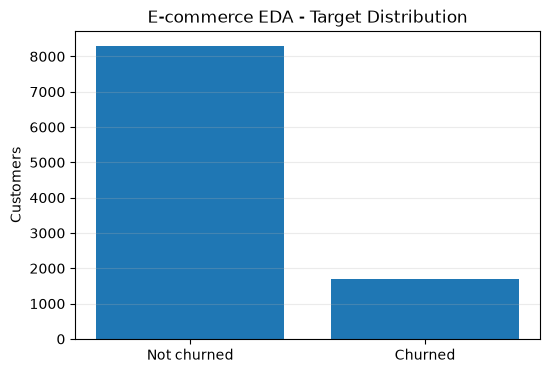

,class,count,ratio
0,not_churned,8306,0.8306
1,churned,1694,0.1694


In [223]:
target_counts = y_customer.value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(["Not churned", "Churned"], target_counts.values)
plt.title("E-commerce EDA - Target Distribution")
plt.ylabel("Customers")
plt.grid(axis="y", alpha=0.25)
plt.show()

target_summary = pd.DataFrame(
    {
        "class": ["not_churned", "churned"],
        "count": [target_counts.get(0, 0), target_counts.get(1, 0)],
        "ratio": [
            target_counts.get(0, 0) / len(y_customer),
            target_counts.get(1, 0) / len(y_customer),
        ],
    }
)
display(target_summary)

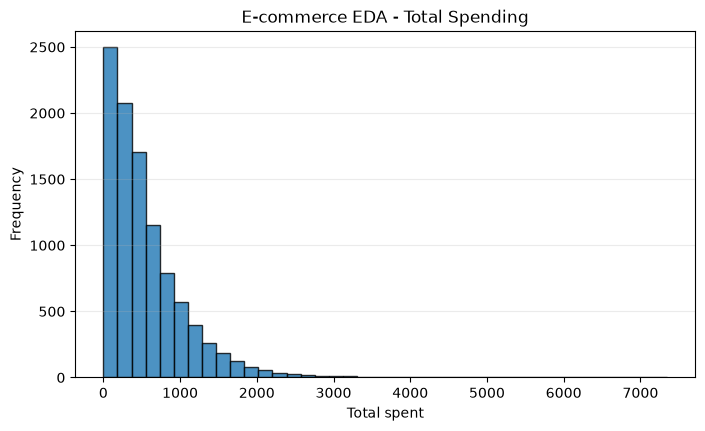

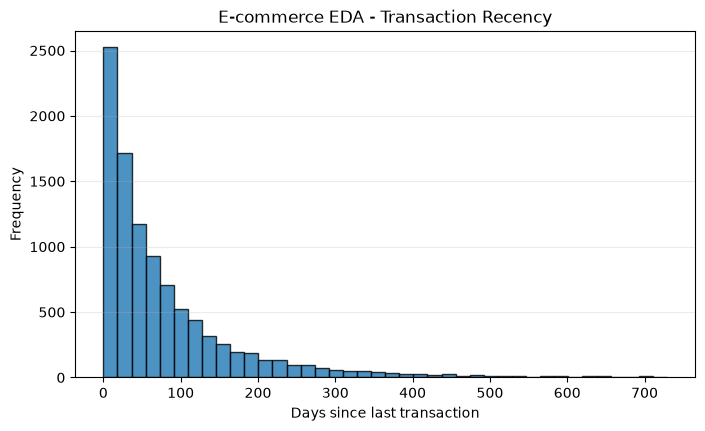

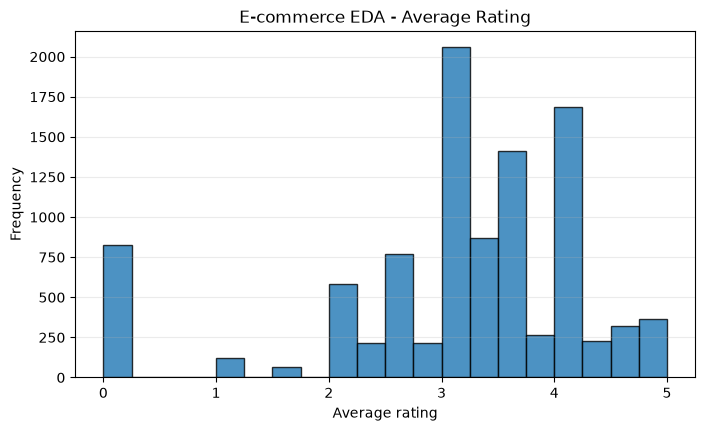

,count,mean,std,min,25%,50%,75%,90%,95%,max
total_spent,"10,000.0000",544.3248,512.5374,0.0000,184.0950,408.4100,746.5100,"1,197.4450","1,518.9240","7,346.4600"
transaction_recency_days,"10,000.0000",83.0250,102.9364,0.0000,18.0000,48.0000,106.0000,204.0000,289.0500,729.0000
avg_rating,"10,000.0000",3.0589,1.1772,0.0000,2.6667,3.2500,4.0000,4.0000,4.5000,5.0000
transaction_count,"10,000.0000",12.0000,7.8060,0.0000,6.0000,11.0000,16.0000,23.0000,28.0500,48.0000
session_count,"10,000.0000",8.0000,5.4491,0.0000,4.0000,7.0000,11.0000,16.0000,19.0000,33.0000


total_spent          transaction_recency_days         avg_rating  \
                  mean   median                     mean  median       mean   
is_churned                                                                    
0             579.4289 440.7200                  76.6409 44.0000     3.0536   
1             372.2028 277.6850                 114.3276 66.0000     3.0851   

                  transaction_count         session_count         
           median              mean  median          mean median  
is_churned                                                        
0          3.2500           12.7501 11.0000        8.4882 7.0000  
1          3.2500            8.3223  7.0000        5.6063 5.0000

In [224]:
plot_single_distribution(
    customer_model_df["total_spent"],
    "E-commerce EDA - Total Spending",
    "Total spent",
    bins=40,
)
plot_single_distribution(
    customer_model_df["transaction_recency_days"],
    "E-commerce EDA - Transaction Recency",
    "Days since last transaction",
    bins=40,
)
plot_single_distribution(
    customer_model_df["avg_rating"],
    "E-commerce EDA - Average Rating",
    "Average rating",
    bins=20,
)

eda_numeric_summary = (
    customer_model_df[
        [
            "total_spent",
            "transaction_recency_days",
            "avg_rating",
            "transaction_count",
            "session_count",
        ]
    ]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
    .T
)
display(eda_numeric_summary)

display(
    customer_model_df.groupby(CUSTOMER_TARGET)[
        [
            "total_spent",
            "transaction_recency_days",
            "avg_rating",
            "transaction_count",
            "session_count",
        ]
    ].agg(["mean", "median"])
)

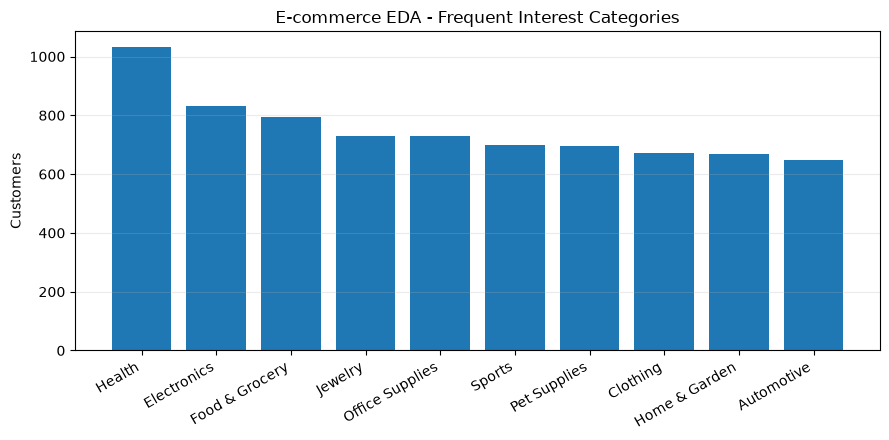

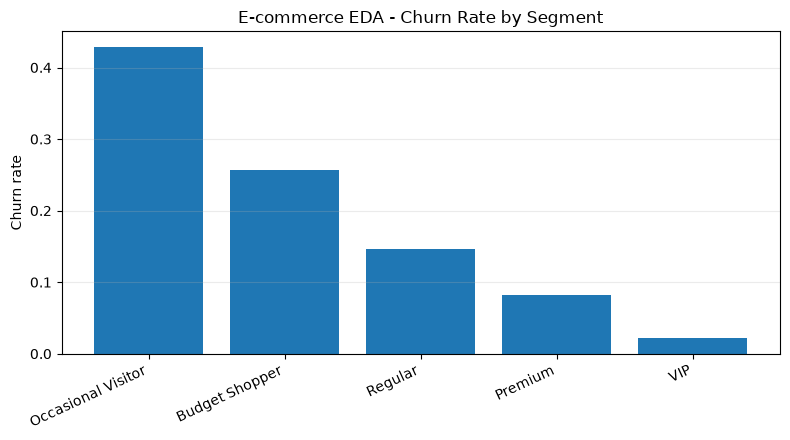

,customer_count
top_category,
Health,1034
Electronics,830
Food & Grocery,795
Jewelry,730
Office Supplies,728
Sports,700
Pet Supplies,696
Clothing,672
Home & Garden,667


,count,mean
segment,,
Occasional Visitor,501,0.4291
Budget Shopper,3043,0.2573
Regular,3500,0.1466
Premium,1982,0.0817
VIP,974,0.0216


In [225]:
category_counts = customer_model_df["top_category"].value_counts().head(10)
plt.figure(figsize=(9, 4.5))
plt.bar(category_counts.index, category_counts.values)
plt.title("E-commerce EDA - Frequent Interest Categories")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

segment_churn = (
    customer_model_df.groupby("segment")[CUSTOMER_TARGET]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)
plt.figure(figsize=(8, 4.5))
plt.bar(segment_churn.index, segment_churn["mean"])
plt.title("E-commerce EDA - Churn Rate by Segment")
plt.ylabel("Churn rate")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

display(category_counts.rename("customer_count").to_frame())
display(segment_churn)

,term,count
0,for,5449
1,not,5401
2,it,5130
3,quality,5093
4,the,4993
5,product,3865
6,great,3843
7,price,3833
8,recommend,3373
9,value,3341


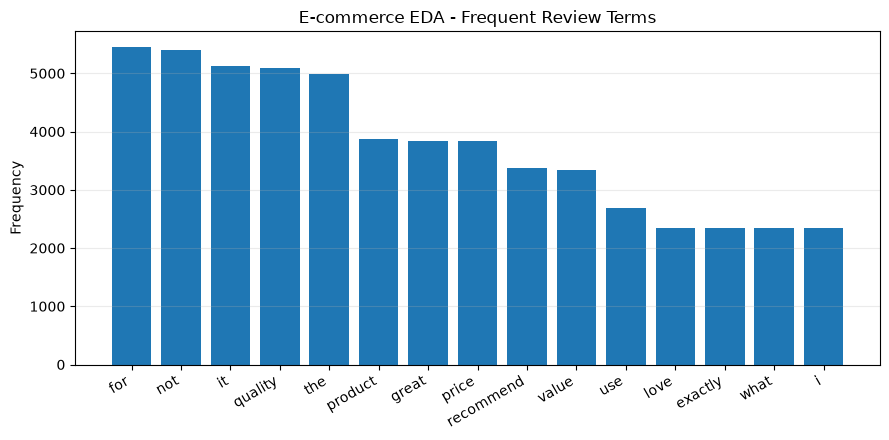

In [226]:
top_terms = Counter()
for text in reviews["review_text_clean"].dropna().astype(str):
    top_terms.update(simple_tokenize(text))

term_df = pd.DataFrame(top_terms.most_common(15), columns=["term", "count"])
display(term_df)

plt.figure(figsize=(9, 4.5))
plt.bar(term_df["term"], term_df["count"])
plt.title("E-commerce EDA - Frequent Review Terms")
plt.ylabel("Frequency")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

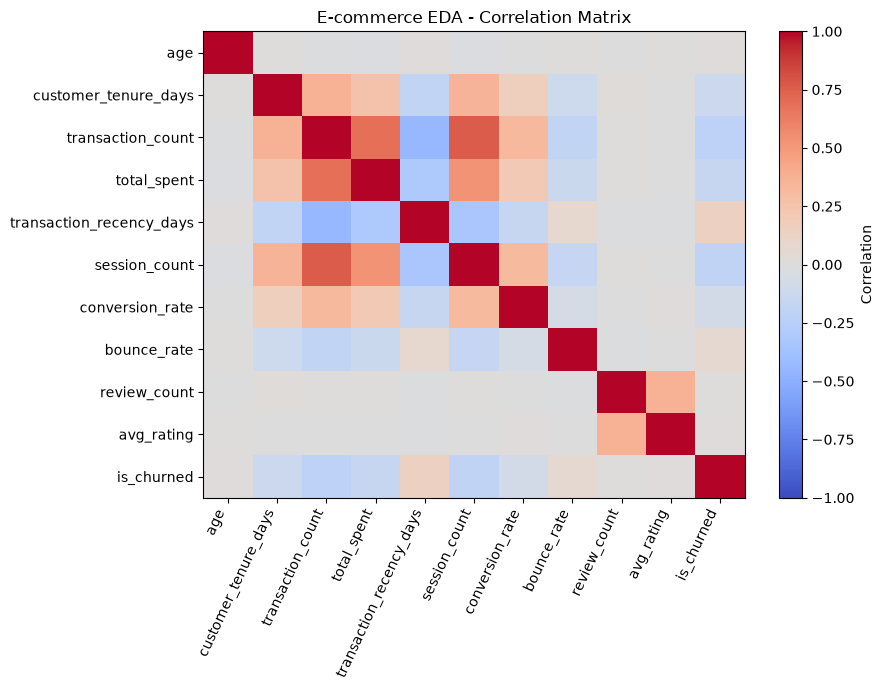

,is_churned
is_churned,1.0000
transaction_recency_days,0.1373
bounce_rate,0.0560
age,0.0123
avg_rating,0.0101
review_count,0.0077
conversion_rate,-0.0756
customer_tenure_days,-0.1227
total_spent,-0.1517
session_count,-0.1984


In [227]:
corr_cols = [
    "age",
    "customer_tenure_days",
    "transaction_count",
    "total_spent",
    "transaction_recency_days",
    "session_count",
    "conversion_rate",
    "bounce_rate",
    "review_count",
    "avg_rating",
    CUSTOMER_TARGET,
]

corr_customer = customer_model_df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
plt.imshow(corr_customer, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Correlation")
plt.xticks(
    range(len(corr_customer.columns)), corr_customer.columns, rotation=65, ha="right"
)
plt.yticks(range(len(corr_customer.index)), corr_customer.index)
plt.title("E-commerce EDA - Correlation Matrix")
plt.tight_layout()
plt.show()
display(corr_customer[[CUSTOMER_TARGET]].sort_values(CUSTOMER_TARGET, ascending=False))

### Diễn giải chi tiết EDA - E-commerce

**Biểu đồ phân bố target.**  
Biểu đồ target cho thấy dữ liệu có **10.000 khách hàng**, trong đó **8.306 khách hàng không churn** và **1.694 khách hàng churn**. Tỷ lệ churn là **16,94%**, tức lớp positive nhỏ hơn lớp negative khoảng gần **5 lần**. Đây không phải imbalance cực đoan, nhưng đủ để accuracy trở thành metric dễ gây hiểu nhầm: một mô hình dự đoán toàn bộ là non-churn vẫn có accuracy khoảng **83,06%** nhưng recall cho churn bằng 0. Vì vậy phần model selection cần ưu tiên **F1-score** và **recall** hơn accuracy đơn thuần.

**Biểu đồ `total_spent`.**  
Phân bố `total_spent` lệch phải rõ rệt: median chỉ khoảng **408,41**, trong khi mean là **544,32** và max lên tới **7.346,46**. Điều này cho thấy có một nhóm nhỏ khách hàng chi tiêu rất cao kéo mean lên. Khi tách theo target, nhóm không churn có mean spending **579,43** và median **440,72**, cao hơn đáng kể nhóm churn với mean **372,20** và median **277,69**. Như vậy spending là tín hiệu hành vi có ý nghĩa: khách hàng chi tiêu ít hơn có xu hướng churn cao hơn. Về ML, feature này nên được scaling cho linear/SVM/KNN models vì range rất rộng.

**Biểu đồ `transaction_recency_days`.**  
Recency cũng lệch phải: median toàn bộ là **48 ngày**, nhưng percentile 90 đã lên **204 ngày** và max là **729 ngày**. Nhóm churn có mean recency **114,33 ngày** và median **66 ngày**, cao hơn nhóm không churn với mean **76,64 ngày** và median **44 ngày**. Điều này phù hợp với trực giác nghiệp vụ: khách hàng càng lâu không giao dịch thì rủi ro rời bỏ càng tăng. Đây là một trong những feature quan trọng nhất để giữ lại trong representation.

**Biểu đồ `avg_rating`.**  
Rating trung bình tập trung quanh **3,25** ở median, với mean khoảng **3,06**. Tuy nhiên khác biệt giữa hai lớp gần như không đáng kể: nhóm không churn có mean **3,0536**, nhóm churn có mean **3,0851**. Vì vậy biểu đồ rating cho thấy review score đơn lẻ không phải tín hiệu churn mạnh trong dataset này. Nó vẫn được giữ lại vì có thể bổ sung thông tin khi kết hợp với review count và low-rating share, nhưng không nên kỳ vọng rating một mình quyết định prediction.

**Biểu đồ top category.**  
`Health` là top interest category phổ biến nhất với **1.034 khách hàng**, tiếp theo là `Electronics` (**830**) và `Food & Grocery` (**795**). Tuy nhiên category phổ biến không đồng nghĩa với churn cao. Ví dụ `Health` có churn rate **13,93%**, thấp hơn mức trung bình toàn dataset **16,94%**; trong khi `Home & Garden` trong nhóm top 10 có churn rate **18,44%**. Hàm ý là `top_category` hữu ích cho interest discovery và personalization, nhưng để dự đoán churn cần kết hợp với frequency, recency, spending và segment.

**Biểu đồ churn rate theo segment.**  
Đây là biểu đồ phân tách target rõ nhất. `Occasional Visitor` có churn rate **42,91%**, `Budget Shopper` là **25,73%**, `Regular` là **14,66%**, `Premium` là **8,17%**, và `VIP` chỉ **2,16%**. Pattern này cho thấy segment phản ánh mức độ gắn bó của khách hàng: nhóm càng có giá trị/gắn bó cao thì churn càng thấp. Vì `segment` là categorical feature, dùng one-hot encoding là phù hợp; nếu encode bằng số 1,2,3,... sẽ tạo thứ tự giả không chắc đúng về mặt ngữ nghĩa.

**Biểu đồ frequent review terms.**  
Các term xuất hiện nhiều nhất gồm `for` (**5.449**), `not` (**5.401**), `quality` (**5.093**), `product` (**3.865**), `great` (**3.843**), `price` (**3.833**), `recommend` (**3.373**) và `value` (**3.341**). Nhóm từ này cho thấy review text xoay quanh chất lượng, giá trị, giá bán và khuyến nghị sản phẩm. Tuy nhiên nhiều từ có tính rất chung hoặc stopword-like như `for`, `not`, `it`, `the`, nên TF-IDF cần lọc theo tần suất/importance thay vì dùng raw counts trực tiếp.

**Correlation matrix.**  
Các correlation với `is_churned` đều không quá lớn, nghĩa là không có một feature đơn lẻ giải thích toàn bộ churn. Tín hiệu âm mạnh nhất là `transaction_count` (**-0,2128**), `session_count` (**-0,1984**) và `total_spent` (**-0,1517**): khách hàng tương tác/mua nhiều hơn có xu hướng ít churn hơn. Tín hiệu dương nổi bật nhất là `transaction_recency_days` (**0,1373**) và `bounce_rate` (**0,0560**): lâu không mua và bounce nhiều hơn đi cùng rủi ro churn cao hơn. Kết quả này ủng hộ việc dùng mô hình học máy kết hợp nhiều feature thay vì rule đơn giản theo một biến.


## 8. Chia tập huấn luyện và kiểm thử

Bộ dữ liệu được chia thành 80% tập huấn luyện và 20% tập kiểm thử độc lập. Stratification giúp giữ tỷ lệ churn/non-churn giữa các tập. Preprocessing được đặt bên trong sklearn pipelines, do đó imputer, scaler, encoder và TF-IDF vocabulary chỉ được fit trên training folds trong cross-validation.


In [228]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_customer,
    y_customer,
    test_size=0.20,
    random_state=SEED,
    stratify=y_customer,
)

print("Shape của training set:", X_train_c.shape)
print("Shape của test set:", X_test_c.shape)
display(
    y_train_c.value_counts(normalize=True).sort_index().rename("train_ratio").to_frame()
)
display(
    y_test_c.value_counts(normalize=True).sort_index().rename("test_ratio").to_frame()
)

Shape của training set: (8000, 38)
Shape của test set: (2000, 38)


,train_ratio
is_churned,
0,0.8306
1,0.1694


,test_ratio
is_churned,
0,0.8305
1,0.1695


## 9. Mô hình baseline

`DummyClassifier(strategy="most_frequent")` được dùng làm baseline. Model này không học quan hệ giữa features và target, mà luôn dự đoán lớp phổ biến nhất. Vì vậy nó là mốc so sánh tối thiểu cho bài toán churn.


In [229]:
customer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

customer_baseline = DummyClassifier(strategy="most_frequent")
baseline_scores_c = cross_validate(
    customer_baseline,
    X_train_c[CUSTOMER_NUMERIC_FEATURES],
    y_train_c,
    cv=customer_cv,
    scoring=classification_scoring,
    n_jobs=1,
)

display(
    pd.DataFrame(
        [
            {
                "Model": "DummyClassifier",
                "Accuracy": baseline_scores_c["test_accuracy"].mean(),
                "Precision": baseline_scores_c["test_precision"].mean(),
                "Recall": baseline_scores_c["test_recall"].mean(),
                "F1": baseline_scores_c["test_f1"].mean(),
            }
        ]
    )
)

,Model,Accuracy,Precision,Recall,F1
0,DummyClassifier,0.8306,0.0000,0.0000,0.0000


## 10-15. Các mô hình phân loại

Sáu mô hình được so sánh. Năm mô hình đầu sử dụng customer-level tabular features. Mô hình thứ sáu bổ sung review text bằng TF-IDF, đáp ứng yêu cầu của assignment về việc so sánh tabular-only representation với text-enhanced representation.


In [230]:
customer_numeric_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

customer_categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

customer_tabular_preprocessor = ColumnTransformer(
    [
        ("num", customer_numeric_pipeline, CUSTOMER_NUMERIC_FEATURES),
        ("cat", customer_categorical_pipeline, CUSTOMER_CATEGORICAL_FEATURES),
    ]
)

customer_text_preprocessor = ColumnTransformer(
    [
        ("num", customer_numeric_pipeline, CUSTOMER_NUMERIC_FEATURES),
        ("cat", customer_categorical_pipeline, CUSTOMER_CATEGORICAL_FEATURES),
        (
            "text",
            TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=2),
            CUSTOMER_TEXT_FEATURE,
        ),
    ]
)

customer_models = {
    "Logistic Regression (tabular)": Pipeline(
        [
            ("preprocess", customer_tabular_preprocessor),
            (
                "model",
                LogisticRegression(
                    max_iter=1000, class_weight="balanced", random_state=SEED
                ),
            ),
        ]
    ),
    "Decision Tree (tabular)": Pipeline(
        [
            ("preprocess", customer_tabular_preprocessor),
            (
                "model",
                DecisionTreeClassifier(
                    max_depth=8, class_weight="balanced", random_state=SEED
                ),
            ),
        ]
    ),
    "Random Forest (tabular)": Pipeline(
        [
            ("preprocess", customer_tabular_preprocessor),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=80,
                    max_depth=10,
                    class_weight="balanced",
                    random_state=SEED,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "Linear SVM (tabular)": Pipeline(
        [
            ("preprocess", customer_tabular_preprocessor),
            (
                "model",
                LinearSVC(class_weight="balanced", random_state=SEED, max_iter=5000),
            ),
        ]
    ),
    "Gradient Boosting (tabular)": Pipeline(
        [
            ("preprocess", customer_tabular_preprocessor),
            (
                "model",
                GradientBoostingClassifier(
                    n_estimators=80, learning_rate=0.05, max_depth=3, random_state=SEED
                ),
            ),
        ]
    ),
    "Text + Tabular Logistic Regression": Pipeline(
        [
            ("preprocess", customer_text_preprocessor),
            (
                "model",
                LogisticRegression(
                    max_iter=1000, class_weight="balanced", random_state=SEED
                ),
            ),
        ]
    ),
}

for name in customer_models:
    print("-", name)

- Logistic Regression (tabular)
- Decision Tree (tabular)
- Random Forest (tabular)
- Linear SVM (tabular)
- Gradient Boosting (tabular)
- Text + Tabular Logistic Regression


## 16. Đánh giá mô hình

Với churn classification, F1-score được dùng làm selection metric chính vì lớp churn xuất hiện ít hơn lớp non-churn. Accuracy, precision và recall vẫn được báo cáo để đánh giá đầy đủ hơn.


In [231]:
customer_rows = []
for name, model in customer_models.items():
    scores = cross_validate(
        model,
        X_train_c,
        y_train_c,
        cv=customer_cv,
        scoring=classification_scoring,
        n_jobs=1,
    )
    customer_rows.append(
        {
            "Model": name,
            "Accuracy": scores["test_accuracy"].mean(),
            "Precision": scores["test_precision"].mean(),
            "Recall": scores["test_recall"].mean(),
            "F1": scores["test_f1"].mean(),
        }
    )

customer_cv_results = pd.DataFrame(customer_rows).sort_values("F1", ascending=False)
display(customer_cv_results)

,Model,Accuracy,Precision,Recall,F1
3,Linear SVM (tabular),0.6288,0.2567,0.6288,0.3646
0,Logistic Regression (tabular),0.6260,0.2555,0.6310,0.3636
2,Random Forest (tabular),0.6953,0.2811,0.5129,0.3631
5,Text + Tabular Logistic Regression,0.6251,0.2465,0.5904,0.3478
1,Decision Tree (tabular),0.5905,0.2349,0.6000,0.3332
4,Gradient Boosting (tabular),0.8296,0.3949,0.0111,0.0215


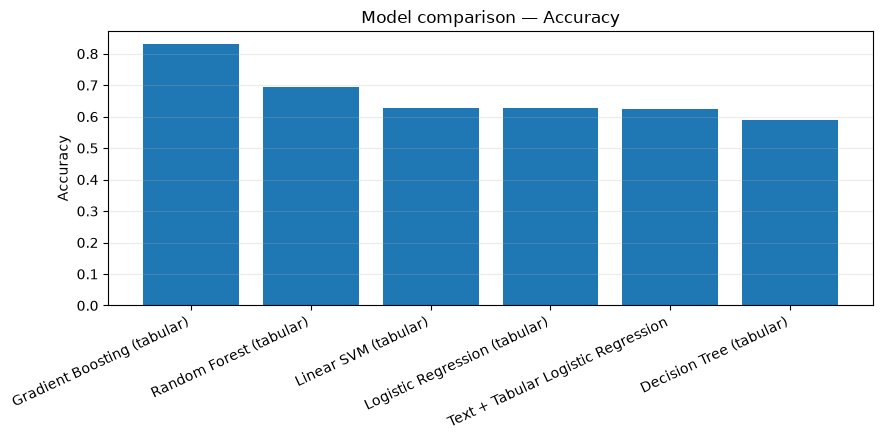

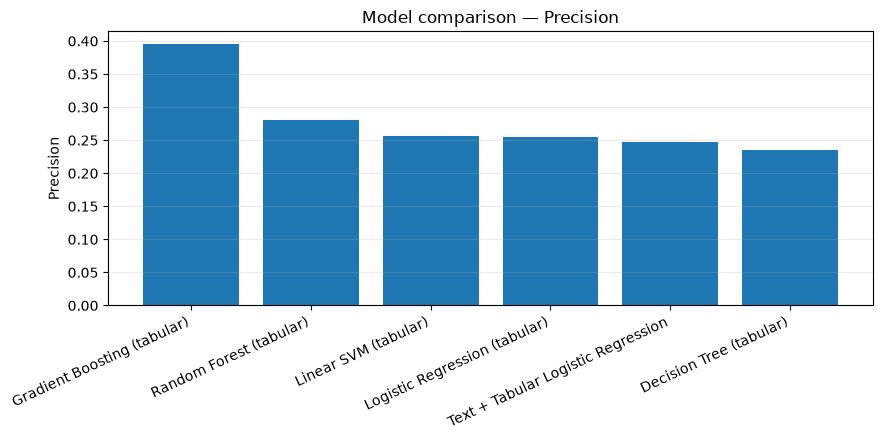

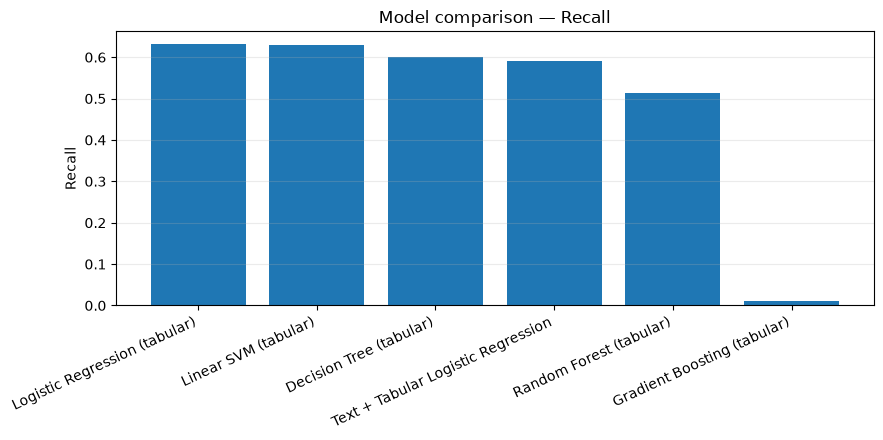

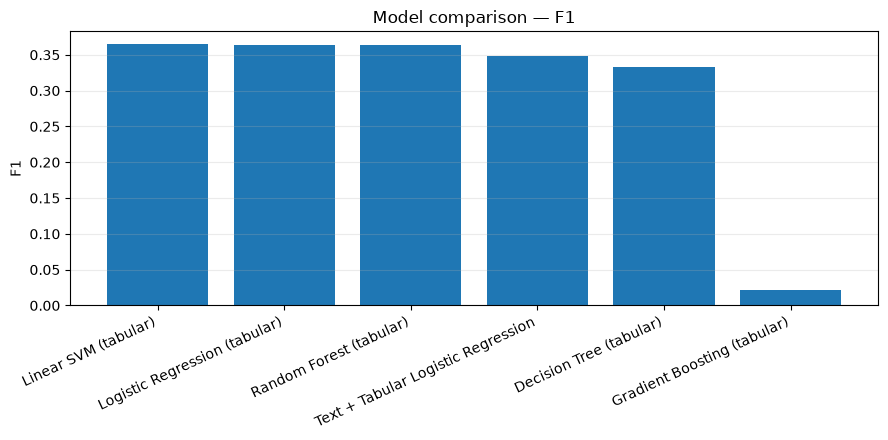

In [232]:
for metric in ["Accuracy", "Precision", "Recall", "F1"]:
    plot_metric_bar(customer_cv_results, metric, higher_is_better=True)

### Diễn giải so sánh mô hình E-commerce

Các biểu đồ metric cho thấy không có mô hình nào vừa đạt accuracy cao vừa bắt được churn tốt. **Linear SVM (tabular)** có F1-score cao nhất, khoảng **0,3646**, rất sát với **Logistic Regression (tabular)** ở **0,3636**. Hai mô hình này có accuracy chỉ khoảng **0,63**, thấp hơn Random Forest và Gradient Boosting, nhưng lại có recall khoảng **0,63**, tức phát hiện được nhiều khách hàng churn hơn.

**Gradient Boosting (tabular)** đạt accuracy cao nhất khoảng **0,8296**, gần bằng baseline đa số lớp, nhưng recall chỉ khoảng **0,0111** và F1 chỉ **0,0215**. Điều này cho thấy mô hình gần như dự đoán hầu hết khách hàng là non-churn, nên accuracy cao không phản ánh năng lực phát hiện churn. **Random Forest** có accuracy khá cao (**0,7399**) nhưng recall chỉ **0,3749**, F1 **0,3278**, thấp hơn hai mô hình tuyến tính.

Model **Text + Tabular Logistic Regression** đạt F1 khoảng **0,3478**, thấp hơn bản tabular-only. Điều này không có nghĩa text luôn vô dụng, mà phản ánh dataset này có review comments ngắn, lặp lại và mang nhiều term chung; trong khi các behavioral aggregates như transaction count, session count, spending và recency đã chứa tín hiệu churn rõ hơn. Vì tiêu chí chọn trước là mean CV F1, **Linear SVM (tabular)** là lựa chọn hợp lý nhất cho final model.


## 17. Thí nghiệm 1 - So sánh mô hình

Thí nghiệm này trả lời câu hỏi: trong sáu mô hình ứng viên, mô hình nào đạt churn F1-score tốt nhất khi dùng cùng representation và cùng validation protocol?


In [233]:
best_customer_model_name = customer_cv_results.iloc[0]["Model"]
best_customer_cv_f1 = float(customer_cv_results.iloc[0]["F1"])
print("Customer model tốt nhất theo mean CV F1:", best_customer_model_name)
print("Mean CV F1:", round(best_customer_cv_f1, 4))

Customer model tốt nhất theo mean CV F1: Linear SVM (tabular)
Mean CV F1: 0.3646


## 18. Thí nghiệm 2 - Khảo sát representation

Thí nghiệm này so sánh Logistic Regression dùng tabular-only representation với Text + Tabular Logistic Regression để kiểm tra review text có bổ sung tín hiệu hữu ích hay không.


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression (tabular),0.6260,0.2555,0.6310,0.3636
5,Text + Tabular Logistic Regression,0.6251,0.2465,0.5904,0.3478


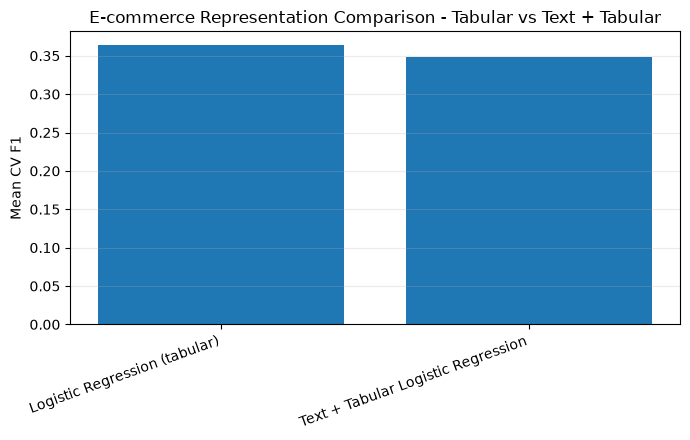

In [234]:
representation_comparison = customer_cv_results[
    customer_cv_results["Model"].isin(
        [
            "Logistic Regression (tabular)",
            "Text + Tabular Logistic Regression",
        ]
    )
].copy()

display(representation_comparison)

plt.figure(figsize=(7, 4.5))
plt.bar(representation_comparison["Model"], representation_comparison["F1"])
plt.title("E-commerce Representation Comparison - Tabular vs Text + Tabular")
plt.ylabel("Mean CV F1")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 19. Mô hình cuối cùng

Mô hình e-commerce cuối cùng được chọn theo mean CV F1, sau đó được huấn luyện lại trên toàn bộ tập huấn luyện và đánh giá một lần trên tập kiểm thử độc lập.


In [235]:
final_customer_model = clone(customer_models[best_customer_model_name])
final_customer_model.fit(X_train_c, y_train_c)
y_pred_c = final_customer_model.predict(X_test_c)

final_customer_metrics = classification_metrics(y_test_c, y_pred_c)
print("Final customer model:", best_customer_model_name)
for metric, value in final_customer_metrics.items():
    print(f"{metric}: {value:.4f}")

Final customer model: Linear SVM (tabular)
Accuracy: 0.6310
Precision: 0.2564
Recall: 0.6195
F1: 0.3627


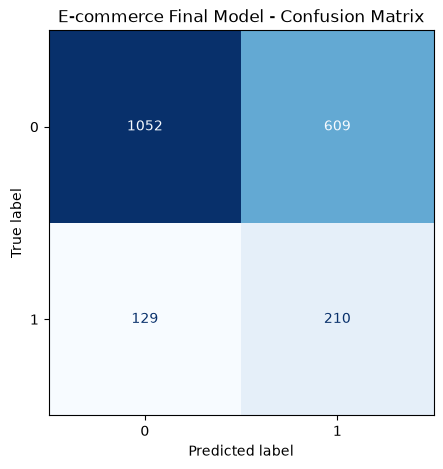

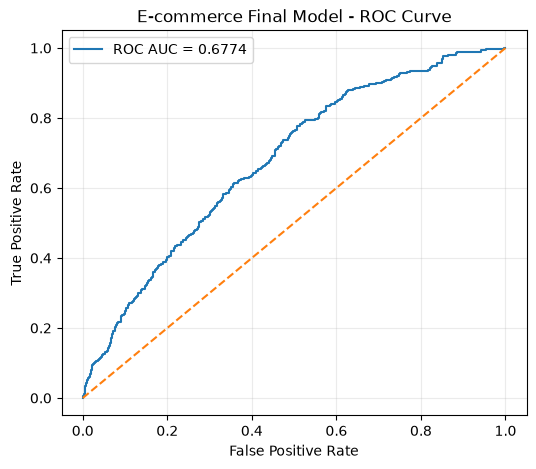

In [236]:
cm_c = confusion_matrix(y_test_c, y_pred_c)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm_c, display_labels=[0, 1]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("E-commerce Final Model - Confusion Matrix")
plt.show()

if hasattr(final_customer_model, "predict_proba"):
    y_score_c = final_customer_model.predict_proba(X_test_c)[:, 1]
elif hasattr(final_customer_model, "decision_function"):
    y_score_c = final_customer_model.decision_function(X_test_c)
else:
    y_score_c = None

if y_score_c is not None:
    auc_c = roc_auc_score(y_test_c, y_score_c)
    fpr_c, tpr_c, _ = roc_curve(y_test_c, y_score_c)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr_c, tpr_c, label=f"ROC AUC = {auc_c:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("E-commerce Final Model - ROC Curve")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()
else:
    auc_c = None
    print("Selected model không có probability hoặc decision scores để tính ROC AUC.")

### Diễn giải kết quả phân loại cuối cùng - E-commerce

Trên tập kiểm thử độc lập gồm **2.000 khách hàng**, final model **Linear SVM (tabular)** đạt accuracy khoảng **0,6310**, precision **0,2564**, recall **0,6195** và F1 **0,3627**. Confusion Matrix là:

```text
TN = 1052, FP = 609
FN = 129,  TP = 210
```

Model phát hiện đúng **210 / 339** khách hàng churn trong test set, tức recall khoảng **61,95%**. Đây là điểm mạnh nếu mục tiêu nghiệp vụ là không bỏ sót quá nhiều khách hàng có nguy cơ rời bỏ. Tuy nhiên model cũng tạo **609 false positives**, nghĩa là khá nhiều khách hàng không churn bị gắn nhãn rủi ro. Precision vì vậy chỉ **25,64%**: cứ bốn khách hàng bị cảnh báo churn thì chỉ khoảng một người thật sự churn.

ROC-AUC khoảng **0,6774**, cao hơn random ranking nhưng chưa phải mức mạnh. Kết quả này phù hợp với correlation matrix: các feature hành vi có tín hiệu thật nhưng không có feature đơn lẻ nào phân tách churn hoàn toàn. Nếu triển khai nghiệp vụ, mô hình nên được dùng như công cụ ưu tiên danh sách retention, không nên xem prediction như quyết định tuyệt đối. Có thể điều chỉnh threshold sau này để cân bằng giữa chi phí khuyến mãi và rủi ro bỏ sót khách hàng churn.


## 20. Lưu mô hình - E-commerce

Mô hình cuối cùng được lưu dưới dạng sklearn pipeline hoàn chỉnh, bao gồm preprocessing, feature transformations và tham số mô hình đã học.


In [237]:
CUSTOMER_MODEL_PATH = ARTIFACT_DIR / "customer_churn_pipeline.joblib"
CUSTOMER_MODELS_DIR = ARTIFACT_DIR / "customer_behavior_models"
CUSTOMER_MODELS_DIR.mkdir(exist_ok=True)

CUSTOMER_MODEL_SLUGS = {
    "Logistic Regression (tabular)": "logistic_regression_tabular",
    "Decision Tree (tabular)": "decision_tree_tabular",
    "Random Forest (tabular)": "random_forest_tabular",
    "Linear SVM (tabular)": "linear_svm_tabular",
    "Gradient Boosting (tabular)": "gradient_boosting_tabular",
    "Text + Tabular Logistic Regression": "text_tabular_logistic_regression",
}

joblib.dump(final_customer_model, CUSTOMER_MODEL_PATH)

customer_deployment_models = {}
for model_name, model_template in customer_models.items():
    if model_name == best_customer_model_name:
        fitted_model = final_customer_model
    else:
        fitted_model = clone(model_template)
        fitted_model.fit(X_train_c, y_train_c)

    model_id = CUSTOMER_MODEL_SLUGS[model_name]
    model_path = CUSTOMER_MODELS_DIR / f"{model_id}.joblib"
    joblib.dump(fitted_model, model_path)
    customer_deployment_models[model_id] = {
        "name": model_name,
        "artifact": str(Path("customer_behavior_models") / f"{model_id}.joblib"),
        "recommended": model_name == best_customer_model_name,
    }

customer_meta = {
    "task": "binary_classification",
    "features": CUSTOMER_FEATURES,
    "numeric_features": CUSTOMER_NUMERIC_FEATURES,
    "categorical_features": CUSTOMER_CATEGORICAL_FEATURES,
    "text_feature": CUSTOMER_TEXT_FEATURE,
    "target": CUSTOMER_TARGET,
    "selected_model": best_customer_model_name,
    "recommended_model_id": CUSTOMER_MODEL_SLUGS[best_customer_model_name],
    "selection_metric": "mean_cv_f1",
    "available_models": customer_deployment_models,
    "test_metrics": {k: float(v) for k, v in final_customer_metrics.items()},
    "roc_auc": None if auc_c is None else float(auc_c),
}

(ARTIFACT_DIR / "customer_behavior_metadata.json").write_text(
    json.dumps(customer_meta, ensure_ascii=False, indent=2), encoding="utf-8"
)

print("Đã lưu recommended customer model:", CUSTOMER_MODEL_PATH)

Đã lưu recommended customer model: artifacts\customer_churn_pipeline.joblib


## 21. Diễn giải nghiệp vụ và Interest Discovery

Kết quả EDA cho thấy churn gắn mạnh với mức độ tương tác và giá trị khách hàng. Nhóm churn có `total_spent` thấp hơn rõ rệt, `transaction_count` thấp hơn, `session_count` thấp hơn và `transaction_recency_days` cao hơn. Điều này cho thấy một e-commerce company có thể dùng mô hình để ưu tiên các khách hàng đã lâu không mua, ít phiên truy cập hoặc có mức chi tiêu giảm.

Interest discovery được thể hiện qua `top_category` và `top_brand`. Ví dụ `Health` là category phổ biến nhất với **1.034 khách hàng**, nhưng churn rate của nhóm này chỉ **13,93%**, thấp hơn trung bình. Ngược lại `Home & Garden` trong nhóm category phổ biến có churn rate **18,44%**. Vì vậy category nên được dùng cho personalization và campaign targeting, còn quyết định churn cần kết hợp thêm recency/frequency/monetary features.

Theo segment, churn rate giảm rất mạnh từ `Occasional Visitor` (**42,91%**) xuống `VIP` (**2,16%**). Đây là insight nghiệp vụ rõ nhất: nhóm khách ghé thăm không thường xuyên và nhóm budget shopper nên được ưu tiên retention campaign, trong khi VIP/Premium cần chiến lược chăm sóc khác để duy trì loyalty.


In [238]:
interest_examples = customer_features[
    [
        "customer_id",
        "top_category",
        "top_brand",
        "transaction_count",
        "total_spent",
        "conversion_rate",
        "avg_rating",
        "review_text_clean",
        CUSTOMER_TARGET,
    ]
].head(10)

display(interest_examples)

,customer_id,top_category,top_brand,transaction_count,total_spent,conversion_rate,avg_rating,review_text_clean,is_churned
0,C00000,Music,NovaTech,25.0000,706.6500,0.1250,0.0000,no review,0
1,C00001,Books,EcoLiving,12.0000,244.6400,0.0000,2.0000,would not recommend. poor value.,0
2,C00002,Sports,NovaTech,29.0000,"1,104.6600",0.1034,2.5000,decent product for the price. would not recomm...,0
3,C00003,Pet Supplies,WorkSmart,26.0000,695.0600,0.1176,4.0000,love it! exactly what i needed.,1
4,C00004,Food & Grocery,EcoLiving,4.0000,148.3200,0.0000,2.0000,broke after a week of use.,0
5,C00005,Unknown,Unknown,0.0000,0.0000,0.0000,3.3333,not as described. returning it. great product!...,1
6,C00006,Music,ReadMore,12.0000,355.7400,0.0000,3.0000,decent product for the price.,0
7,C00007,Automotive,FitGear,6.0000,630.3500,0.0000,3.2500,"love it! exactly what i needed. it is okay, no...",0
8,C00008,Clothing,ReadMore,9.0000,625.7200,0.0000,0.0000,no review,0
9,C00009,Food & Grocery,WellBeing,15.0000,402.0200,0.0000,3.3333,"great product! highly recommend. not bad, not ...",0


## 22. Minh họa hệ thống - E-commerce

Demo đưa các dòng customer qua toàn bộ pipeline:

`Customer input -> Feature representation -> Preprocessing -> Churn model -> Prediction`


In [239]:
customer_demo_cases = X_test_c.head(5).copy()
customer_demo_predictions = final_customer_model.predict(customer_demo_cases)

demo_result_c = customer_demo_cases[
    [
        "age",
        "segment",
        "top_category",
        "transaction_count",
        "total_spent",
        "conversion_rate",
        "review_count",
    ]
].copy()
demo_result_c["predicted_is_churned"] = customer_demo_predictions

if hasattr(final_customer_model, "predict_proba"):
    demo_result_c["churn_probability"] = final_customer_model.predict_proba(
        customer_demo_cases
    )[:, 1]
elif hasattr(final_customer_model, "decision_function"):
    demo_result_c["decision_score"] = final_customer_model.decision_function(
        customer_demo_cases
    )

display(demo_result_c)

,age,segment,top_category,transaction_count,total_spent,conversion_rate,review_count,predicted_is_churned,decision_score
8861,37,Regular,Office Supplies,13.0000,"1,519.7600",0.1000,0.0000,0,-0.1275
7267,58,Regular,Food & Grocery,10.0000,489.3400,0.0000,3.0000,0,-0.2533
4884,22,VIP,Beauty,30.0000,"1,540.9600",0.4667,2.0000,0,-0.8127
7552,38,Budget Shopper,Software,5.0000,119.7000,0.0000,1.0000,1,0.2705
6438,41,VIP,Jewelry,32.0000,"1,060.8100",0.3750,4.0000,0,-0.5804


## 23. Nhận xét - E-commerce

Case này khác diabetes và house price vì dữ liệu thô có dạng relational và một phần là text. Bước aggregation bảo toàn nhiều tín hiệu hành vi ở cấp customer, nhưng làm mất thứ tự đầy đủ của các event nếu chưa dùng sequence models. TF-IDF bảo toàn mức độ quan trọng của term, nhưng không hiểu sâu ngữ nghĩa như sarcasm, intent hoặc context.


## 24. Kết luận - E-commerce

Nghiên cứu tình huống C hoàn thiện một quy trình phân loại hành vi khách hàng từ các file relational CSV đến persisted ML pipeline. Notebook minh họa tabular, categorical và text representation, so sánh sáu mô hình, đánh giá mô hình cuối cùng và giải thích ý nghĩa nghiệp vụ của churn/interest signals.

Phân tích dữ liệu thực tế cho thấy churn không được quyết định bởi một feature đơn lẻ, mà hình thành từ nhiều tín hiệu: khách hàng churn có spending thấp hơn, ít giao dịch hơn, ít session hơn và lâu quay lại mua hàng hơn. Segment là biến categorical có sức phân tách rất rõ, đặc biệt `Occasional Visitor` có churn rate cao hơn nhiều so với `VIP`. Review text hữu ích cho diễn giải interest, nhưng trong dataset synthetic này chưa cải thiện F1 so với tabular-only representation.


# Bảng tổng kết Data Representation bắt buộc

| Ứng dụng                      | Dạng dữ liệu thô                        | Biểu diễn số                                                                                         | Input đưa vào mô hình                               |
| ----------------------------- | --------------------------------------- | ---------------------------------------------------------------------------------------------------- | --------------------------------------------------- |
| Dự đoán tiểu đường            | CSV / bảng hồ sơ bệnh nhân              | Ma trận sáu numeric features sau imputation và scaling                                               | `B x d`, trong đó `d = 6` selected patient features |
| Dự đoán giá nhà               | CSV / bảng tin đăng bất động sản        | Ma trận sáu numeric features sau imputation                                                          | `B x d`, trong đó `d = 6` selected house attributes |
| Hành vi khách hàng e-commerce | Relational CSV tables + review comments | Customer-level behavioral matrix, one-hot categorical vectors, TF-IDF text vectors và embedding demo | Tabular/text `B x d`; text tensor demo `B x T x d`  |


# PART D — INTELLIGENT SYSTEM APPLICATION

Các mô hình học máy được xây dựng trong Part A, Part B và Part C tạo thành ba lõi dự đoán của một intelligent system thống nhất. Ở mức notebook, mỗi hệ thống đều đã có cùng chuỗi xử lý:

`User Input -> Feature Representation -> Preprocessing -> Trained ML Model -> Prediction -> Result`

Hệ thống mục tiêu của Assignment 02 gồm ba chức năng:

- **Diabetes Prediction:** nhận sáu chỉ số sức khỏe đầu vào và trả về predicted class cùng probability.
- **Vietnam House Price Prediction:** nhận sáu thuộc tính bất động sản và trả về predicted price theo đơn vị tỷ VND.
- **E-commerce Customer Behavior / Interest Discovery:** nhận customer-level features đã được tổng hợp từ profile, transactions, sessions, reviews và trả về churn prediction; đồng thời dùng `top_category`, `top_brand` và review terms để hỗ trợ interest interpretation.

Ba chức năng này dùng cùng nguyên tắc triển khai: backend/API không tự viết lại preprocessing thủ công, mà phải load đúng persisted sklearn pipeline được tạo từ notebook. Nhờ vậy logic inference nhất quán với logic training:

`Raw Input -> Schema Validation -> DataFrame đúng thứ tự cột -> Persisted Pipeline -> Output JSON`

## Live Demo

- **Web Application:** https://isd-assignment01-web.onrender.com/
- **Android APK:** https://expo.dev/accounts/tuananh1305/projects/assignment01-intelligent-systems/builds/c8f59daa-9a8e-4ab1-94b9-b75f2564f378


# NHẬN XÉT CUỐI

Ba case study cho thấy một trained model chỉ là một thành phần của intelligent system. Hệ thống hoàn chỉnh cần giữ nhất quán toàn bộ chuỗi:

`Environment/User -> Input -> Representation -> Preprocessing -> Learning Model -> Prediction -> Application`

Part A và Part B: mỗi bài toán được đưa về một feature vector sáu chiều, train nhiều mô hình truyền thống, so sánh bằng cross-validation, chọn final model và lưu pipeline để phục vụ inference. Diabetes là bài toán classification trên dữ liệu sức khỏe dạng tabular; House Price là bài toán regression trên dữ liệu bất động sản dạng tabular. Hai case này cho thấy khi representation đã rõ ràng, mô hình học máy truyền thống có thể được đóng gói thành pipeline tương đối gọn và dễ triển khai.

Part C mở rộng mức độ phức tạp của representation. Dữ liệu e-commerce không bắt đầu bằng một bảng phẳng duy nhất, mà gồm nhiều bảng quan hệ và review text. Vì vậy bước quan trọng nhất không chỉ là chọn model, mà là chuyển dữ liệu giao dịch, session, sản phẩm và review thành một customer-level representation có ý nghĩa. Kết quả EDA cho thấy churn liên quan đến nhiều tín hiệu cùng lúc: spending thấp hơn, ít giao dịch hơn, ít session hơn, recency cao hơn và segment kém gắn bó hơn. Review text hỗ trợ interest interpretation, nhưng trong dataset synthetic này chưa cải thiện F1 so với tabular-only representation.


# KẾT LUẬN CUỐI

Bài thực hành đã hoàn thiện một notebook Assignment 02 gồm ba intelligent systems theo cùng một framework phát triển: `Data -> Understand -> Clean -> Represent -> Train -> Evaluate -> Persist`. Case Study A sử dụng sáu đặc trưng sức khỏe để dự đoán `Outcome`; Case Study B sử dụng sáu thuộc tính bất động sản để dự đoán `Price`; Case Study C tổng hợp customer profile, transactions, sessions, products và reviews để dự đoán `is_churned` và phân tích customer interest.

Mỗi hệ thống đều có phần mô tả bài toán, inspection dữ liệu, cleaning, representation, EDA, baseline, nhiều mô hình so sánh, evaluation metrics và final model. Với Diabetes và E-commerce, metric trọng tâm là F1-score vì đây là bài toán classification; với House Price, metric trọng tâm là RMSE vì đây là bài toán regression. Phần E-commerce cũng minh họa thêm representation cho categorical features và review text thông qua tokenization, token IDs, TF-IDF và embedding tensor dạng `B x T x d`.
